In [146]:
import jax
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro import plate
from numpyro.distributions import constraints

In [147]:
import numpy as np
from itertools import product, accumulate
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange
from typing import List, Dict, Any, Tuple
import copy
import time

In [148]:
def select_most_diverse(samples: jnp.ndarray, num_select: int = 3):
    """
    samples: (N, D)
    returns: python list of selected indices
    """
    N = samples.shape[0]
    selected = [0]

    # pairwise Euclidean distances
    diff = samples[:, None, :] - samples[None, :, :]   # (N, N, D)
    dist_matrix = jnp.linalg.norm(diff, axis=-1)      # (N, N)

    for _ in range(num_select - 1):
        dist_to_selected = dist_matrix[jnp.array(selected), :]  # (len(selected), N)
        min_dist = dist_to_selected.min(axis=0)                # (N,)

        # Set already selected indices to -1 so they won't be picked
        min_dist = min_dist.at[jnp.array(selected)].set(-1.0)
        next_idx = int(jnp.argmax(min_dist))
        selected.append(next_idx)

    return selected

def generate_distinct_distributions(key, N, V, concent=0.8):
    """
    Draw N samples from Dirichlet(alpha).
    - If concent is scalar → alpha = concent * ones(V)
    - If concent is vector of shape (V,) → use directly
    Returns: (N, V)
    """
    if jnp.ndim(concent) == 0:  # scalar
        alpha = jnp.ones((V,), dtype=jnp.float32) * float(concent)
    else:  # vector
        alpha = jnp.array(concent, dtype=jnp.float32)
        assert alpha.shape[0] == V, f"alpha length {alpha.shape[0]} != V={V}"

    alpha = jnp.clip(alpha, a_min=1e-6)
    keys = random.split(key, N)
    samples = jnp.stack([random.dirichlet(k, alpha) for k in keys], axis=0)
    return samples

def generate_distinct_components(key, K, V, peak_strength=5.0, base_concent=0.1):
    """
    Create K component-word distributions (K, V) with a 'peak' at index k * V // K
    """
    comps = []
    keys = random.split(key, K)
    for k in range(K):
        alpha = jnp.ones((V,), dtype=jnp.float32) * base_concent
        alpha = alpha.at[(k * V) // K].set(peak_strength)
        comps.append(random.dirichlet(keys[k], alpha))
    return jnp.stack(comps, axis=0)  # (K, V)

def generate_hierarchical_mixture_data_jax(
    struct_upbd,
    N_per_base: int = 20,
    M: int = 200,
    V: int = 100,
    seed: int = 42,
):
    """
    Returns a dict similar to your PyTorch version, using JAX arrays.
    """
    key = random.PRNGKey(seed)
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base

    # y means and stds
    y_means = jnp.linspace(-num_features / 4, num_features / 4, num=num_features)
    key, sub = random.split(key)
    y_stds = 0.1 + 0.1 * random.uniform(sub, shape=(num_features,))

    alpha_1 = 0.8
    assert num_features >= num_base_per_super * num_super
    super_window = int(num_features / num_super)

    # generate super_core: shape (num_super, super_window)
    key, sub = random.split(key)
    super_core = generate_distinct_distributions(sub, num_super, super_window, concent=alpha_1)

    # build super_prototypes (num_super, num_features)
    blocks = int(num_features / super_window)
    super_prototypes = jnp.zeros((num_super, num_features))
    for i in range(blocks):
        mask = (jnp.arange(num_super) % blocks) == i  # (num_super,)
        mask = mask.astype(jnp.float32)[:, None]      # (num_super, 1)
        block_vals = super_core * mask
        super_prototypes = super_prototypes.at[:, i * super_window:(i + 1) * super_window].set(block_vals)

    # normalize
    super_prototypes = super_prototypes / super_prototypes.sum(axis=-1, keepdims=True)

    # alpha_2 cycling
    alpha_2 = [6, 8] * ((num_super + 1) // 2)
    alpha_2 = alpha_2[:num_super]

    # base prototypes
    base_prototypes_list = []
    for super_id in range(num_super):
        key, sub = random.split(key)
        candids = generate_distinct_distributions(
            sub, num_base_per_super * 5, num_features,
            concent=alpha_2[super_id] * super_prototypes[super_id]
        )
        sel = select_most_diverse(candids, num_select=num_base_per_super)
        chosen = candids[jnp.array(sel), :]
        base_prototypes_list.append(chosen)

    base_prototypes = jnp.stack(base_prototypes_list, axis=0)  # (num_super, num_base_per_super, num_features)

    # word components
    key, sub = random.split(key)
    word_dists = generate_distinct_components(sub, num_features, V, peak_strength=1.0, base_concent=0.1)

    # apply overlapping mask scheme
    word_block = int(V / (num_super * num_base_per_super))
    overlap = int(word_block / 2) if word_block >= 2 else 0
    masks = jnp.zeros_like(word_dists)
    for i in range(num_features):
        if i < int(num_features / 2):
            idxs = jnp.arange(i * overlap, i * overlap + word_block)
        else:
            idxs = jnp.arange(-(i * overlap + word_block) - 1, -i * overlap - 1)
        idxs = (idxs % V).astype(int)
        mask = jnp.zeros((V,), dtype=jnp.bool_)
        mask = mask.at[idxs].set(True)
        masks = masks.at[i].set(mask.astype(jnp.float32))

    word_dists = word_dists * masks
    row_sums = word_dists.sum(axis=-1, keepdims=True)
    word_dists = word_dists / (row_sums + 1e-12)

    # generate documents
    X_list, y_list, labels_base, labels_super, labels_x, labels_y = [], [], [], [], [], []

    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            base_proto = base_prototypes[super_id, base_offset]

            for _ in range(samples_per_base):
                doc_words = []
                docs_labels = []
                for _w in range(M):
                    key, sub = random.split(key)
                    comp_logits = jnp.log(base_proto + 1e-12)
                    comp_id = int(random.categorical(sub, comp_logits))
                    docs_labels.append(comp_id)
                    key, sub = random.split(key)
                    word_logits = jnp.log(word_dists[comp_id] + 1e-12)
                    word_idx = int(random.categorical(sub, word_logits))
                    doc_words.append(jax.nn.one_hot(word_idx, V))
                doc = jnp.stack(doc_words, axis=0)
                doc_z = jnp.array(docs_labels)
                X_list.append(doc)
                labels_x.append(doc_z)

                key, sub = random.split(key)
                comp_for_y = int(random.categorical(sub, jnp.log(base_proto + 1e-12)))
                labels_y.append(comp_for_y)
                key, sub = random.split(key)
                y_val = y_means[comp_for_y] + y_stds[comp_for_y] * random.normal(sub, shape=())
                y_list.append(y_val)
                labels_base.append(base_id)
                labels_super.append(super_id)

    X_data = jnp.stack(X_list, axis=0)
    y_data = jnp.stack(y_list, axis=0)
    labels_base = jnp.array(labels_base)
    labels_super = jnp.array(labels_super)
    labels_x = jnp.array(labels_x)
    labels_y = jnp.array(labels_y)

    return {
        "x": X_data,
        "y": y_data,
        "super_labels": labels_super,
        "base_labels": labels_base,
        "x_labels": labels_x,
        "y_labels": labels_y,
        "word_dists": word_dists,
        "reg_means": y_means,
        "reg_std": y_stds,
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes,
    }

# Example usage
if __name__ == "__main__":
    struct_upbd = {"G0": 36, "G1": 3, "G2": 4}   # example
    data = generate_hierarchical_mixture_data_jax(struct_upbd, N_per_base=3, M=10, V=50, seed=0)
    print("x shape:", data["x"].shape)
    print("y shape:", data["y"].shape)
    print("word_dists shape:", data["word_dists"].shape)
    print("super mix shape:", data["super_mix_weights"].shape)
    print("child mix shape:", data["child_mix_weights"].shape)


x shape: (36, 10, 50)
y shape: (36,)
word_dists shape: (36, 50)
super mix shape: (3, 36)
child mix shape: (3, 4, 36)


In [149]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data_jax(struct_upbd)

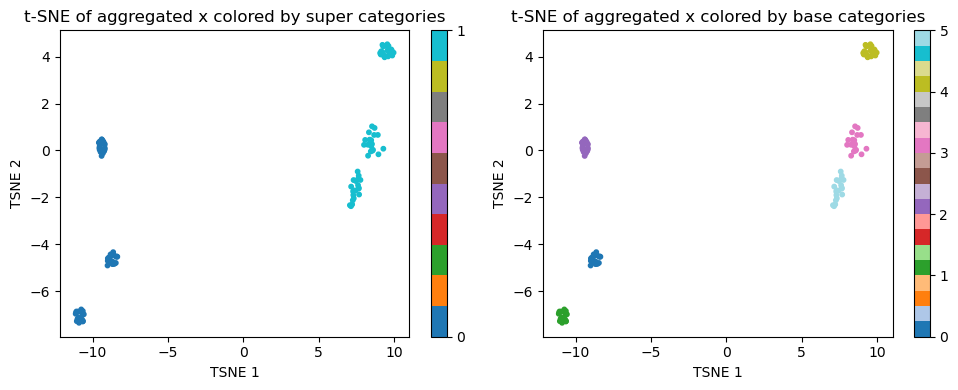

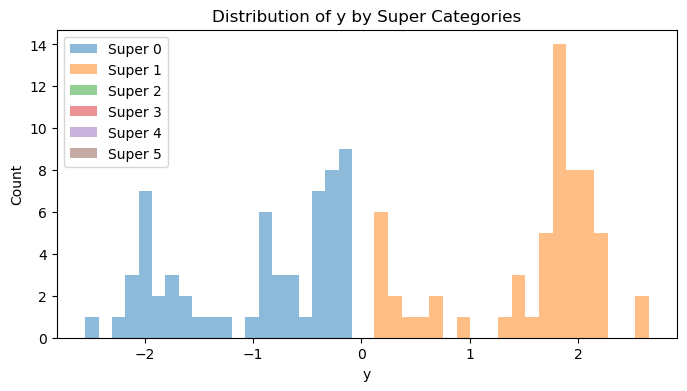

In [ ]:
def tsne_visualization(data, struct_upbd):
    x_agg = data["x"].sum(axis=1)
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    x_embedded = tsne.fit_transform(x_agg)

    # Plot t-SNE colored by super categories
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
    plt.colorbar(scatter, ticks=range(6))
    plt.title("t-SNE of aggregated x colored by super categories")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")

    # Plot t-SNE colored by base categories
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
    plt.colorbar(scatter, ticks=range(18))
    plt.title("t-SNE of aggregated x colored by base categories")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")

    plt.tight_layout()
    plt.show()

    # Plot distribution of y by super categories
    plt.figure(figsize=(8, 4))
    for super_id in range(struct_upbd["G1"]*struct_upbd["G2"]):
        y_vals = data["y"][data["super_labels"] == super_id]
        plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

    plt.title("Distribution of y by Super Categories")
    plt.xlabel("y")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

tsne_visualization(data)

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


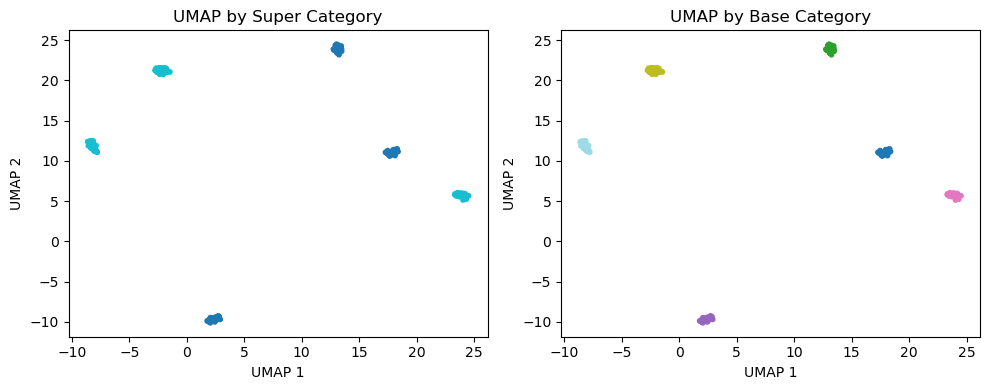

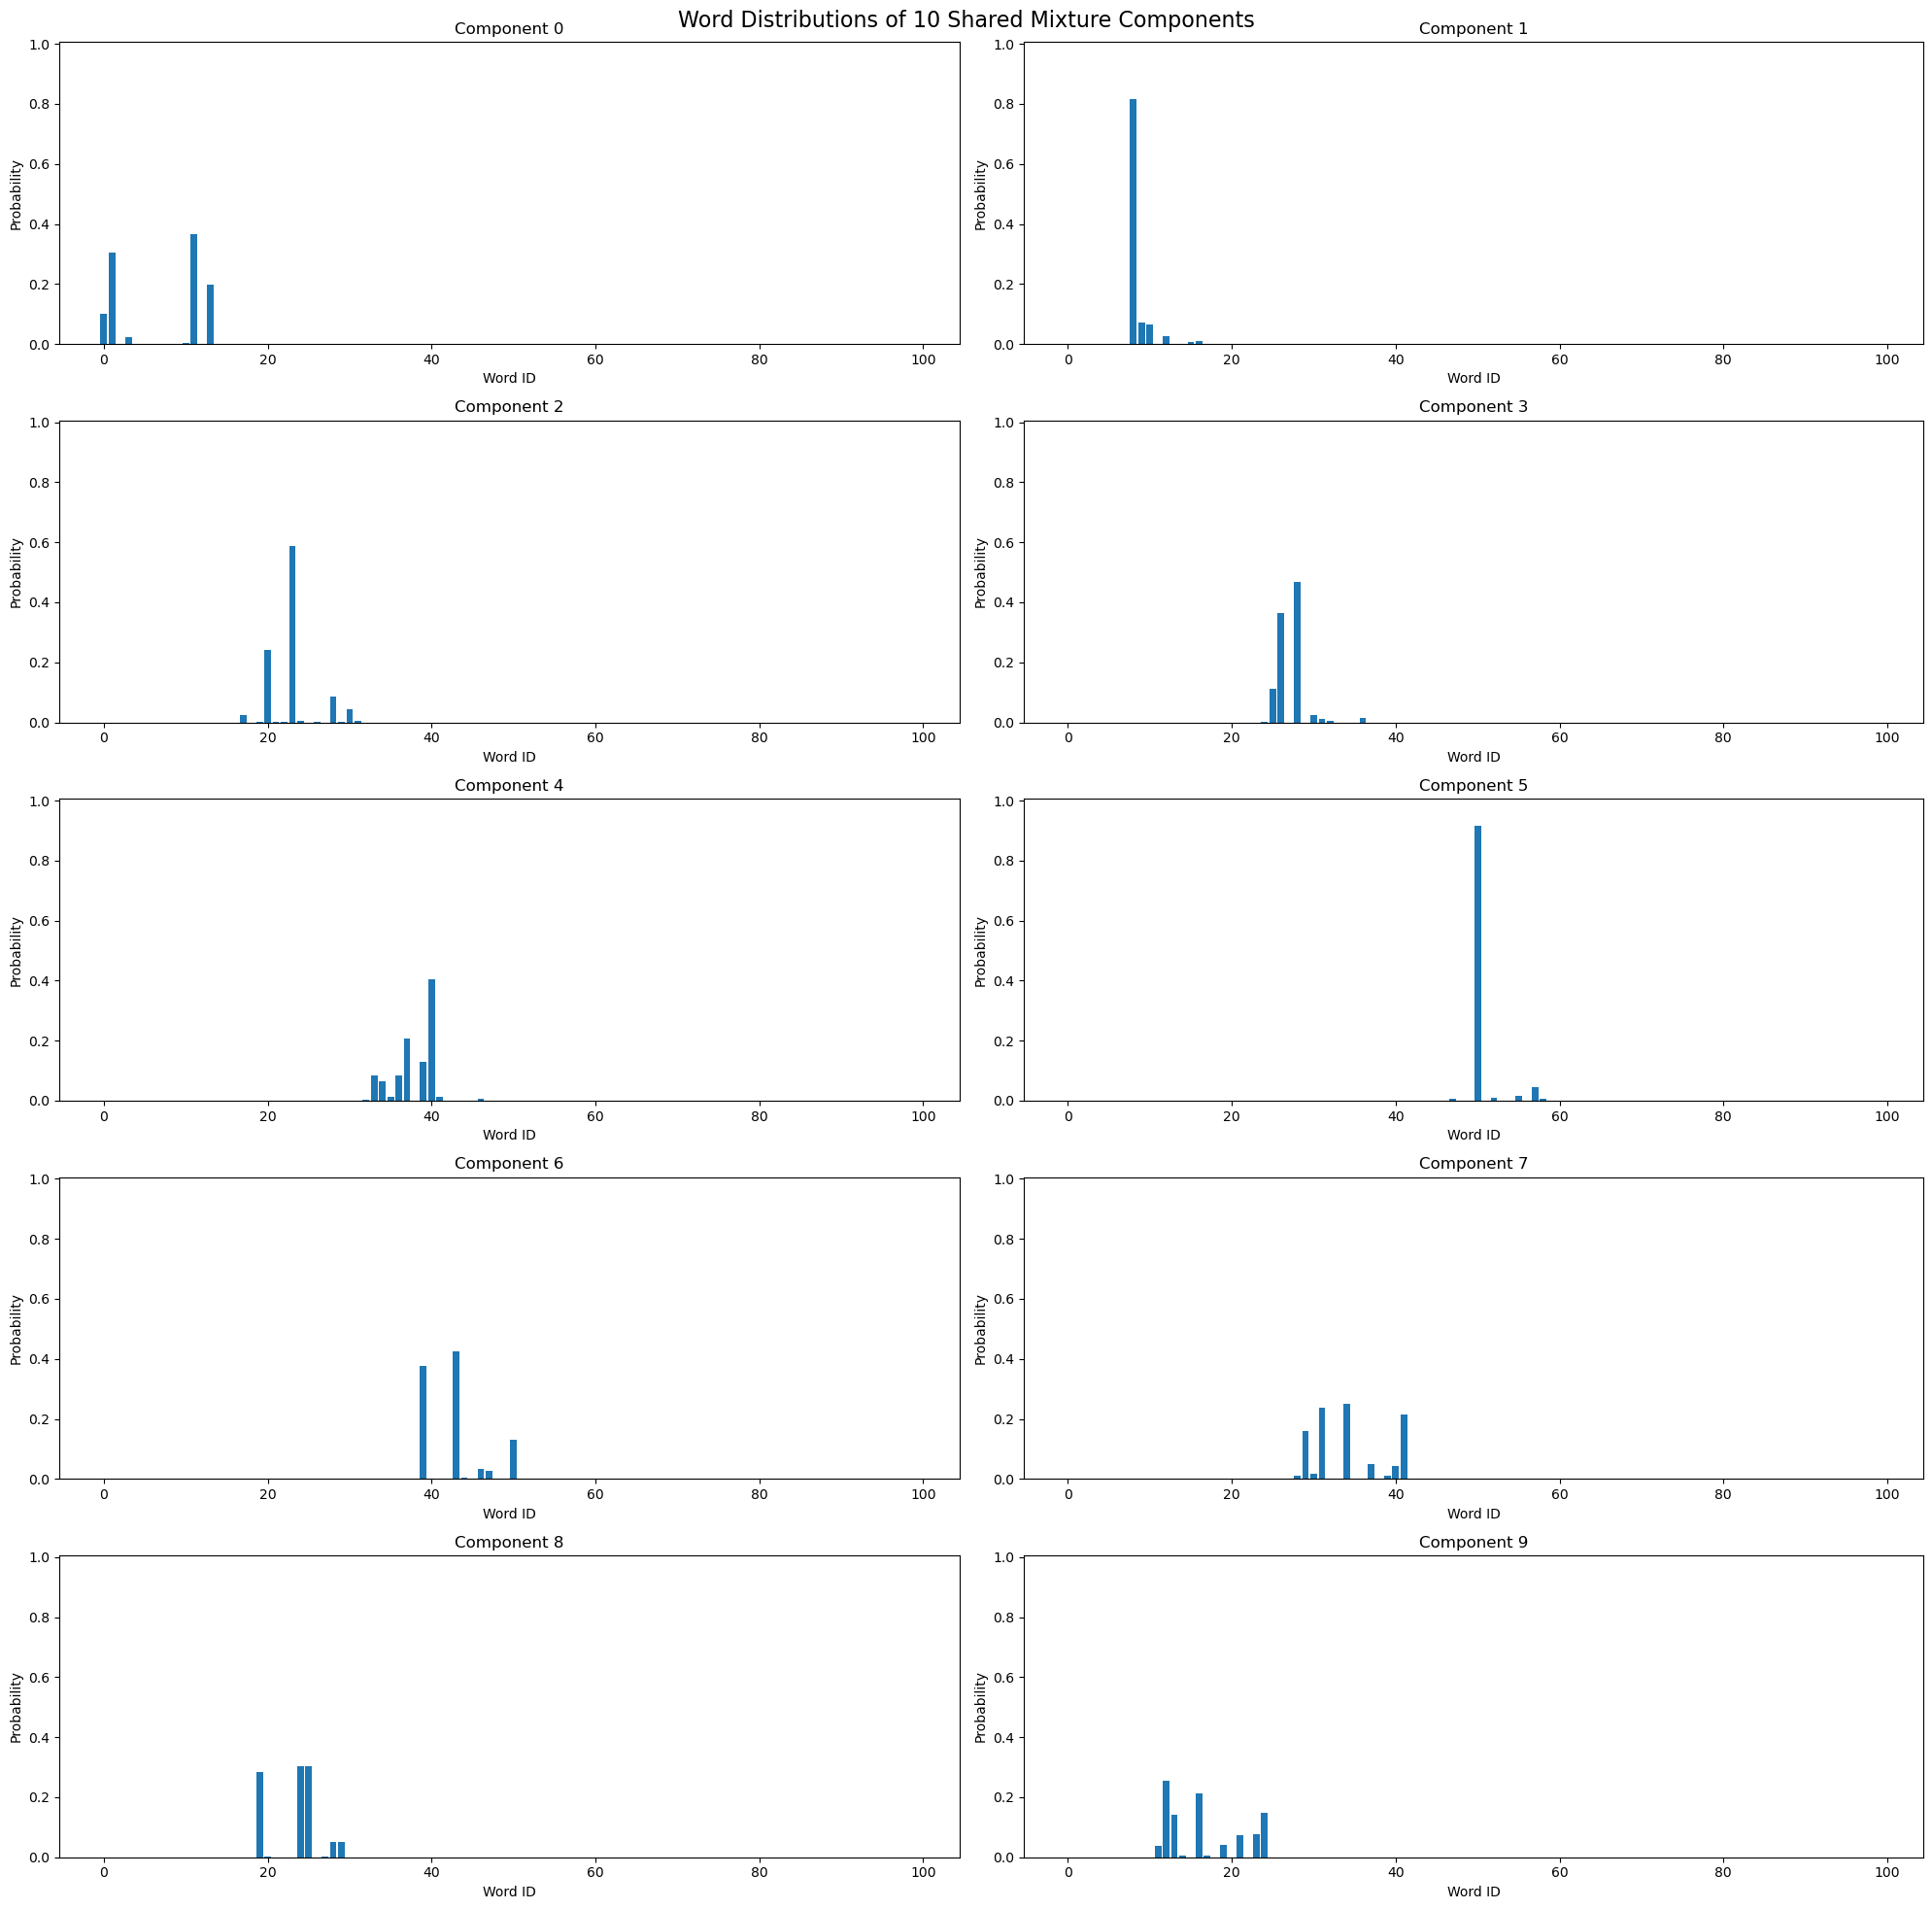

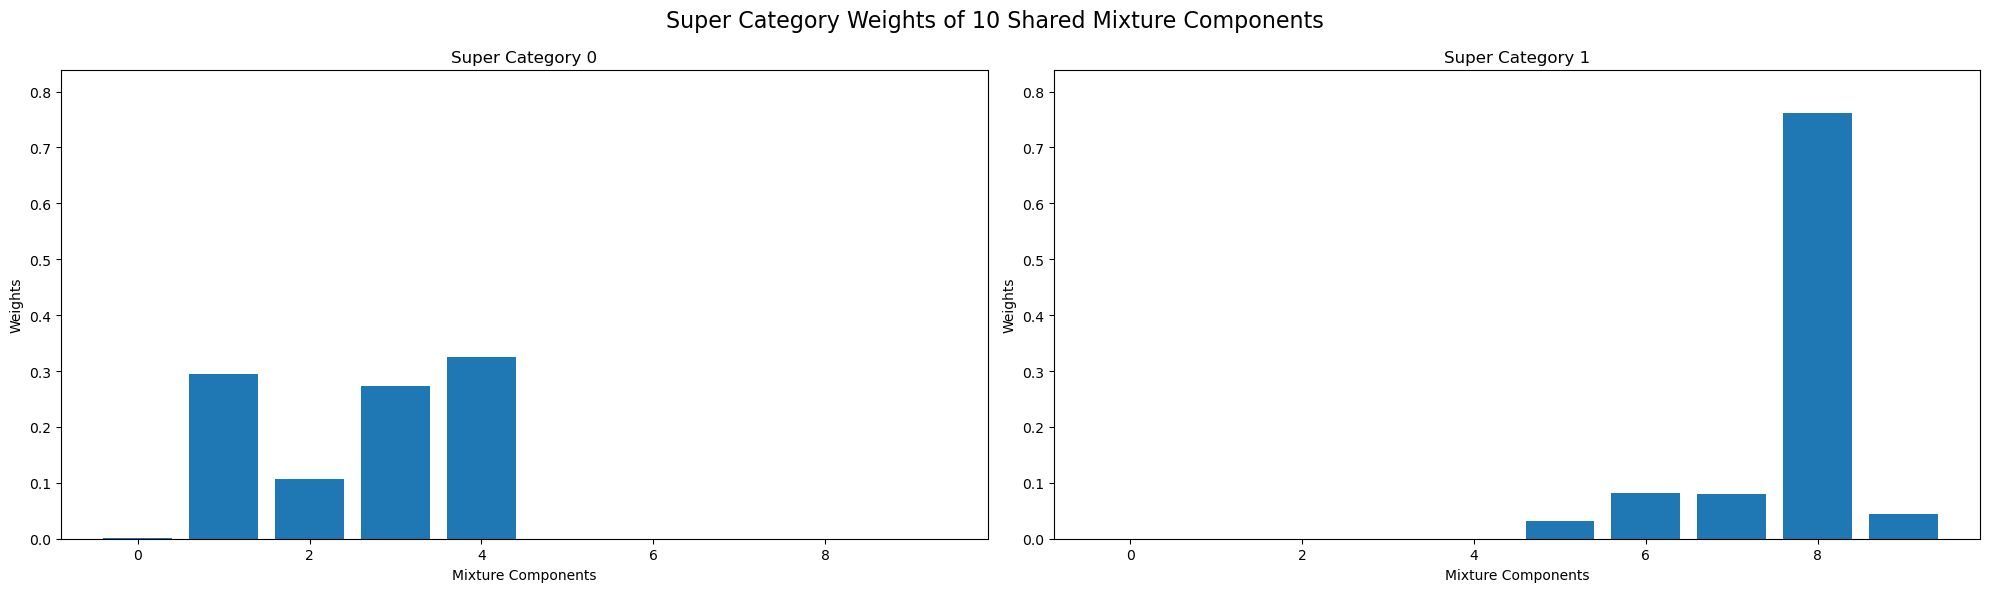

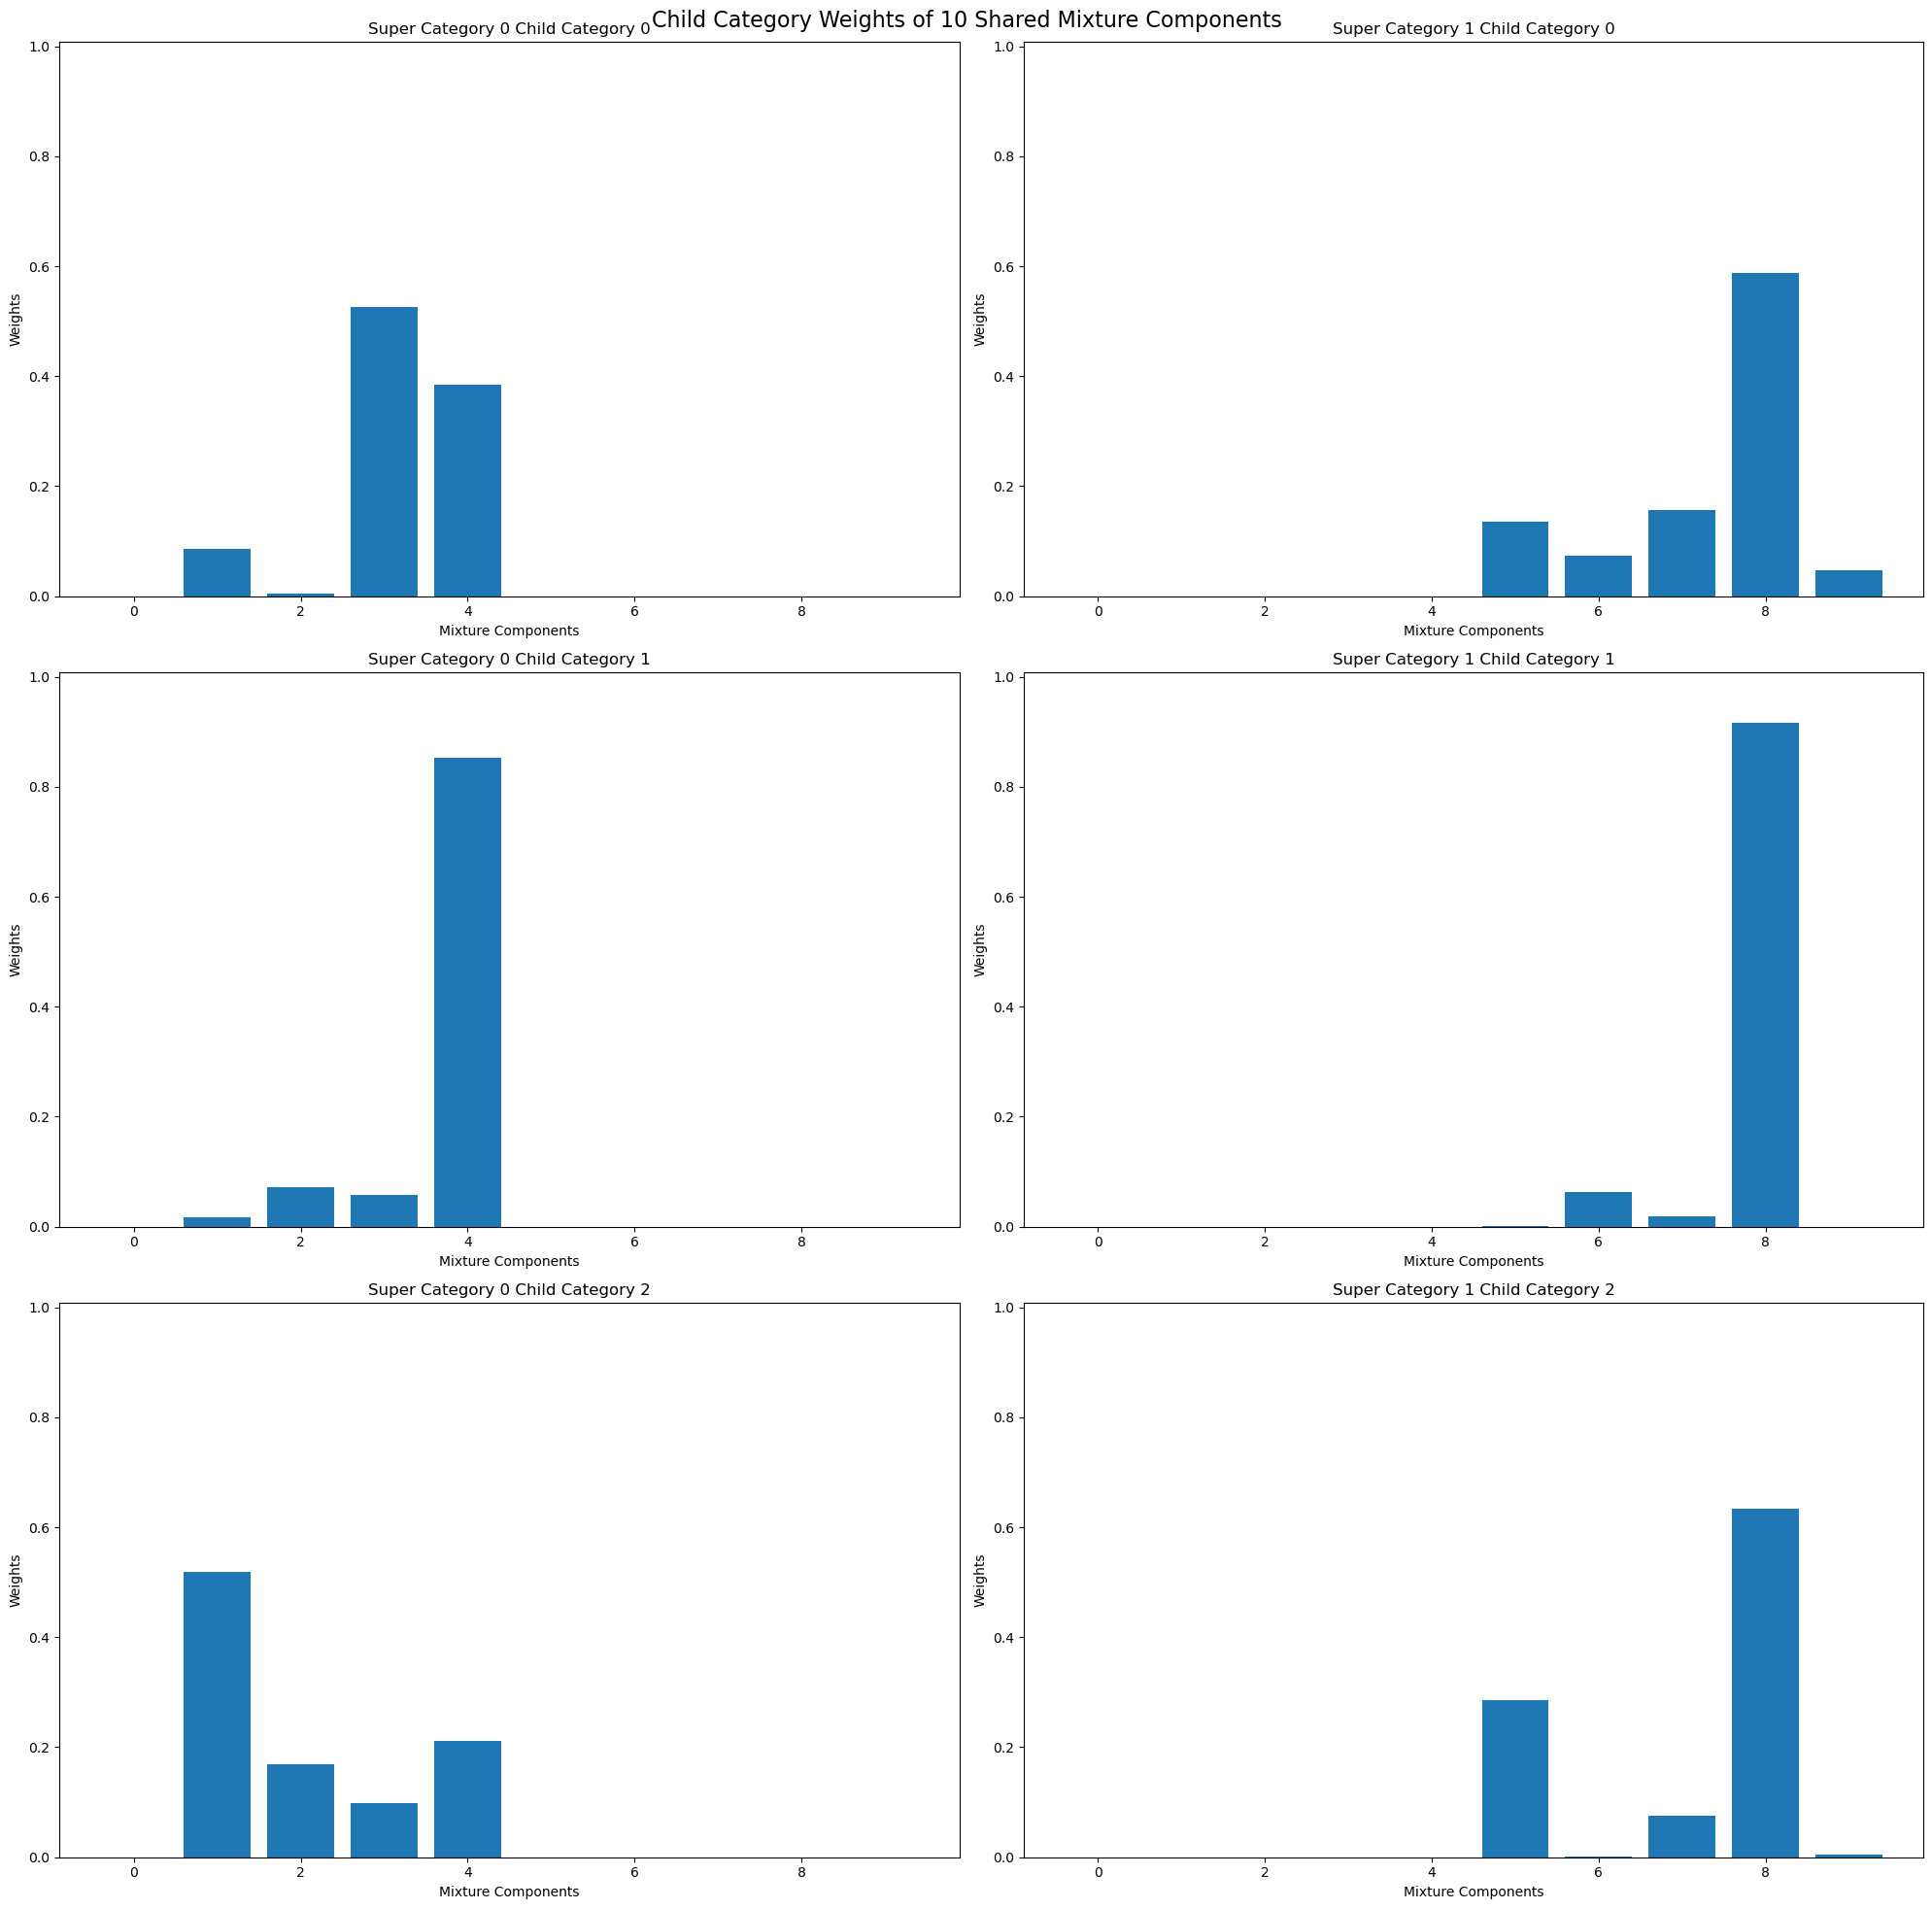

In [ ]:
def umap_visualization(data, struct_upbd):
    x_agg = data["x"].sum(axis=1)
    # === UMAP projection ===
    reducer = umap.UMAP(random_state=0)
    x_umap = reducer.fit_transform(x_agg)


    # === UMAP Plots ===
    plt.figure(figsize=(10, 4))

    # Super category coloring
    plt.subplot(1, 2, 1)
    plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
    plt.title("UMAP by Super Category")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    # Base category coloring
    plt.subplot(1, 2, 2)
    plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
    plt.title("UMAP by Base Category")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.tight_layout()
    plt.show()

    # === Mixture Component Word Distributions ===
    num_components = struct_upbd["G0"]
    V = data["x"].shape[-1]
    word_dists = data["word_dists"]
    super_mix_weights = data["super_mix_weights"]
    child_mix_weights = data["child_mix_weights"]

    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G0"], 1, figsize=(20, 20))
    for i in range(num_components):
        ax = axs[i, 1]
        ax.bar(range(V), word_dists[i])
        ax.set_title(f"Component {i}")
        ax.set_xlabel("Word ID")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, word_dists.max().item() * 1.1)

    fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G1"], 1, figsize=(20, 6))
    for i in range(struct_upbd["G1"]):
        ax = axs[i]
        ax.bar(range(10), super_mix_weights[i])
        ax.set_title(f"Super Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

    fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G1"]*struct_upbd["G2"], 1, figsize=(20, 20))
    for i in range(struct_upbd["G1"]):
        for j in range(struct_upbd["G2"]):
            ax = axs[i * struct_upbd["G2"] + j]
            ax.bar(range(10), child_mix_weights[j][i])
            ax.set_title(f"Super Category {j} Child Category {i}")
            ax.set_xlabel("Mixture Components")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

    fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
    plt.tight_layout()
    plt.show()

umap_visualization(data)

In [152]:
# @jax.jit
# def mix_weights(beta):
#     # Compute cumulative product of (1 - beta) along the last dimension
#     beta1m_cumprod = jnp.cumprod(1.0 - beta, axis=-1)

#     # Pad beta with a 1 at the end of the last dimension
#     beta_padded = jnp.pad(beta, ((0, 0),) * (beta.ndim - 1) + ((0, 1),), constant_values=1.0)

#     # Pad beta1m_cumprod with a 1 at the start of the last dimension
#     beta1m_cumprod_padded = jnp.pad(beta1m_cumprod, ((0, 0),) * (beta.ndim - 1) + ((1, 0),), constant_values=1.0)

#     # Element-wise multiplication
#     weight = beta_padded * beta1m_cumprod_padded

#     # Numerical stability (avoid zero weights)
#     weight = jnp.maximum(weight, 1e-6)

#     # Normalize across last dimension
#     rlt = weight / jnp.sum(weight, axis=-1, keepdims=True)

#     return rlt
@jax.jit
def mix_weights(beta, axis=-1):
    """
    Compute mixture weights from stick-breaking proportions beta.
    beta: (..., K) where K is the number of sticks/components
    axis: axis along which to perform stick-breaking
    Returns: weights of same shape as beta
    """
    # Compute cumulative product of (1-v)
    remaining = jnp.cumprod(1 - beta + 1e-10, axis=axis)

    # Shift along axis: prepend ones, drop last element
    ones_shape = list(remaining.shape)
    ones_shape[axis] = 1
    ones = jnp.ones(ones_shape, dtype=remaining.dtype)
    remaining = jnp.concatenate([ones, remaining[..., :-1]], axis=axis)

    # Stick weights
    weights = beta * remaining
    return weights

In [153]:
def assign_groups_evenly_vectorized(key, a, m):
    # unique values
    unique_vals = jnp.unique(a)
    k = unique_vals.shape[0]

    # shuffle unique values
    key, subkey = jax.random.split(key)
    shuffled = jax.random.permutation(subkey, unique_vals)

    # assign groups evenly
    group_labels = jnp.repeat(jnp.arange(m), repeats=(k + m - 1)//m)[:k]

    # build a mapping from unique_vals → group_labels
    # we use jnp.searchsorted to vectorize the lookup
    # sorted shuffled values for searchsorted
    sorted_shuffled = jnp.sort(shuffled)
    # indices of a in shuffled
    idx_in_shuffled = jnp.searchsorted(sorted_shuffled, a)
    # sort shuffled -> group_labels must be sorted the same way
    sorted_group_labels = group_labels[jnp.argsort(shuffled)]
    # vectorized mapping
    g = sorted_group_labels[idx_in_shuffled]

    return g, (sorted_shuffled, sorted_group_labels)

In [154]:
def transfer_data_labels_to_hierarchy(super_labels, base_labels, level_dims):
    N = super_labels.shape[0]
    L = len(level_dims)
    local_cats = jnp.zeros((N, L), dtype=jnp.int32)
    data_labels = jnp.stack([super_labels, base_labels], axis=1)

    for level in range(L):
        if level == 0:
            uniq_s = jnp.unique(data_labels[:, level])
            if uniq_s.shape[0] > level_dims[level]:
                raise ValueError(f"Exceed category upperbound in level {level}")
            # direct assignment
            local_cats = local_cats.at[:, level].set(data_labels[:, level])
        else:
            parents = jnp.unique(data_labels[:, level-1])
            for p in parents:
                mask = data_labels[:, level-1] == p
                children = jnp.unique(data_labels[mask, level])
                if children.shape[0] > level_dims[level]:
                    raise ValueError(f"Exceed category upperbound in level {level}")
                # build child index mapping (vectorized, no dict)
                children_sorted = jnp.sort(children)
                # broadcast compare to assign local indices
                child_ids = data_labels[mask, level]
                mapped = jnp.searchsorted(children_sorted, child_ids)
                local_cats = local_cats.at[mask, level].set(mapped)

    return local_cats


In [155]:
def transfer_hierarchy_to_data_labels(local_cats: jnp.ndarray, level_dims: list[int]) -> jnp.ndarray:
    """
    Reverse of transfer_data_labels_to_hierarchy.
    Given local_cats and cluster sizes per level, reconstruct absolute labels.

    Args:
        local_cats: (N, L) array of local indices
        level_dims: list of ints, max cluster size per level

    Returns:
        data_labels: (N, L) array of absolute indices per level
    """
    N, L = local_cats.shape
    data_labels = jnp.zeros((N, L), dtype=jnp.int32)

    # level 0: absolute = local (super labels)
    data_labels = data_labels.at[:, 0].set(local_cats[:, 0])

    # deeper levels: absolute id = parent_abs * K[level] + local_id
    for level in range(1, L):
        parent_abs = data_labels[:, level - 1]
        data_labels = data_labels.at[:, level].set(parent_abs * level_dims[level] + local_cats[:, level])
    
    labels_per_level = [data_labels[:, i] for i in range(L)]

    return labels_per_level


In [156]:
@jax.jit
def suffix_sum(x: jnp.ndarray) -> jnp.ndarray:
    """
    Compute suffix sums along the last dimension of a tensor.
    Each entry is the sum of all elements to its right.
    The last element along that dimension is always 0.
    
    Example:
        x = jnp.array([1,2,3])
        suffix_sum(x) -> [5,3,0]
        
        x = jnp.array([[1,2,3],[4,5,6]])
        suffix_sum(x) -> [[5,3,0],
                           [11,6,0]]
    """
    # Flip along the last dimension
    rev = jnp.flip(x, axis=-1)
    # Cumulative sum on the flipped tensor
    rev_cumsum = jnp.cumsum(rev, axis=-1)
    # Flip back
    suffix = jnp.flip(rev_cumsum, axis=-1)
    # Subtract original to exclude current element
    suffix = suffix - x
    return jnp.clip(suffix, a_min=1e-10)

In [157]:
def gen_next_level_prior(G_parent, alpha_param):
    param_alpha = alpha_param * G_parent
    param_beta = suffix_sum(param_alpha)

    return [param_alpha, param_beta]
    

In [ ]:
def hdp_model(data, struct_upbd, vocab_size, seed, gen_mixture=None, device=None):
    """
    Args:
      data: (feature, label), where
            feature: (N, M, vocab_size) one-hot words per position (or None for prior)
            label:   (N,) regression targets (or None for prior)
      struct_upbd: dict like {"G0": K0, "G1": K1, ...} (top level is G0)
      vocab_size: int
      device: unused (kept for API parity)
    """
    key = random.PRNGKey(seed)
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    cluster_dims = param_dims[:-1]  # no G0
    cluster_dims.reverse()

    # -----------------------
    # Data handling
    # -----------------------
    feature = data[0]          # expected shape (N, M, vocab_size)
    N = feature.shape[0]
    M = feature.shape[1]
    label = data[1] 
    # base_category = data[2]
    # super_category = data[3]

    # ------------------------
    # Global/structural params
    # ------------------------
    struct_params = {}
    struct_params["gamma"]      = numpyro.param("model_gamma",      jnp.asarray([N/10.]), constraint=constraints.positive)
    struct_params["dir_alpha"]  = numpyro.param("model_dir_alpha",  jnp.asarray([1./vocab_size]), constraint=constraints.positive)
    struct_params["nig_mu"]     = numpyro.param("model_nig_mu",     jnp.asarray([0.0]))
    struct_params["nig_kappa"]  = numpyro.param("model_nig_kappa",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_alpha"]  = numpyro.param("model_nig_alpha",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_beta"]   = numpyro.param("model_nig_beta",   jnp.asarray([1.0]), constraint=constraints.positive)

    # alpha/eta tensors across hierarchy
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  

        base = numpyro.param(
            f"model_alpha{parent_level}",
            jnp.ones(tuple(param_dims[-child_level:-1])),
            constraint=constraints.positive,
        )
        struct_params[f"alpha{parent_level}"] = jnp.expand_dims(base, -1) * jnp.ones(tuple(param_dims[-child_level:]))
        assert struct_params[f"alpha{parent_level}"].shape == tuple(param_dims[-child_level:])

        struct_params[f"eta{parent_level}"] = numpyro.param(
            f"model_eta{parent_level}",
            jnp.ones(tuple(cluster_dims[:child_level])),
            constraint=constraints.positive,
        )

    # Last level alpha (no eta)
    last_idx = len(struct_upbd) - 1
    base_last = numpyro.param(
        f"model_alpha{last_idx}",
        jnp.ones(tuple(param_dims[:-1])),
        constraint=constraints.positive,
    )
    struct_params[f"alpha{last_idx}"] = jnp.expand_dims(base_last, -1) * jnp.ones(tuple(param_dims))
    assert struct_params[f"alpha{last_idx}"].shape == tuple(param_dims)

    # ---------------
    # Stick-breaking
    # ---------------
    struct_values = {}

    # Top-level Beta sticks B0 -> G0 weights
    K0 = param_dims[-1]
    B0_a = jnp.ones((K0,))  # shape (K0,)
    B0_b = jnp.broadcast_to(struct_params["gamma"], (K0,))
    key, sub = random.split(key)
    beta_0 = dist.Beta(B0_a, B0_b).sample(sub)
    beta_0 = beta_0.at[-1].set(1.0)  # last stick is always 1
    struct_values["P0"] = [B0_a, B0_b]
    struct_values["Prior0"] = copy.deepcopy(struct_values["P0"])
    struct_values["B0"] = beta_0
    struct_values["G0"] = mix_weights(beta_0)  # (K0,)
    struct_values["S0"] = (K0,)
    assert struct_values["G0"].shape == (K0,)
    

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  # number of dims for this plate

        # shapes like in your code:
        # alpha * G_parent and alpha * (1 - cumsum(G_parent))
        G_parent = struct_values[f"G{parent_level}"]  # shape param_dims[-(parent_level+1):]
        alpha_param = struct_params[f"alpha{parent_level}"]  # shape param_dims[-child_level:]
        shape_needed = tuple(param_dims[-full_dim:])

        param_alpha = alpha_param * G_parent
        param_beta = suffix_sum(param_alpha)

        a = jnp.broadcast_to(jnp.expand_dims(param_alpha, 0), shape_needed)
        b = jnp.broadcast_to(jnp.expand_dims(param_beta, 0), shape_needed)

        key, sub = random.split(key)
        beta = dist.Beta(a, b).sample(sub)
        beta = beta.at[..., -1].set(1.0)  # last stick is always 1
        struct_values[f"P{child_level}"] = [a, b]
        struct_values[f"Prior{child_level}"] = copy.deepcopy(struct_values[f"P{child_level}"])
        struct_values[f"S{child_level}"] = shape_needed
        struct_values[f"B{child_level}"] = beta
        struct_values[f"G{child_level}"] = mix_weights(beta)
        assert struct_values[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][0].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][1].shape == tuple(param_dims[-full_dim:])

    # ---------------
    # Cluster weights
    # ---------------
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1
        eta = struct_params[f"eta{parent_level}"]  # shape param_dims[-full_dim:-1]

        key, sub = random.split(key)
        a = jnp.ones_like(eta)
        b = eta
        beta = dist.Beta(a, b).sample(sub)
        beta = beta.at[-1].set(1.0)  # last stick is always 1
        assert beta.shape == tuple(cluster_dims[:child_level])
        struct_values[f"LP{parent_level}"] = [a, b]
        struct_values[f"LPrior{parent_level}"] = copy.deepcopy(struct_values[f"LP{parent_level}"])
        struct_values[f"LS{parent_level}"] = tuple(cluster_dims[:child_level])
        struct_values[f"LB{parent_level}"] = beta
        struct_values[f"LG{parent_level}"] = mix_weights(beta)  # categorical probs over next level
        assert struct_values[f"LG{parent_level}"].shape == tuple(cluster_dims[:child_level])

    # -----------------------
    # Mixture components
    # -----------------------
    # Topics over vocab
    G0_size = struct_upbd["G0"]
    mixture_components = {}
    if gen_mixture is not None:
        assert gen_mixture.shape == (G0_size, vocab_size)
        mixture_components["generation"] = gen_mixture
    else:
        key, sub = random.split(key)
        mixture_components["generation"] = dist.Dirichlet(
                struct_params["dir_alpha"]
                * jnp.ones((vocab_size))
            ).sample(sub, sample_shape=(G0_size,))
        assert mixture_components["generation"].shape == (G0_size, vocab_size)
    # Regression components via NIG prior
    key, sub = random.split(key)
    sigma = dist.InverseGamma(
            jnp.broadcast_to(struct_params["nig_alpha"], (G0_size,)),
            jnp.broadcast_to(struct_params["nig_beta"],  (G0_size,))
        ).sample(sub)
    assert sigma.shape == (G0_size,)
    key, sub = random.split(key)
    mu = dist.Normal(
            jnp.broadcast_to(struct_params["nig_mu"], (G0_size,)),
            jnp.sqrt(sigma / jnp.broadcast_to(struct_params["nig_kappa"], (G0_size,)))
        ).sample(sub)
    assert mu.shape == (G0_size,)
    mixture_components["regression_sigma"] = sigma
    mixture_components["regression_mu"] = mu

    # # ---------------------------------
    # # Per-document hierarchical routing
    # # ---------------------------------
    # doc_values = {}
    
    # # nodes_per_level: number of nodes at each *tree* level
    # # level 0 = root (1 node), level 1 = K[0], level 2 = K[0]*K[1], ...
    # nodes_per_level = [1]
    # for k in cluster_dims:
    #     nodes_per_level.append(nodes_per_level[-1] * k)

    # # --- sampling walk (per-batch) ---
    # key, subkey = jax.random.split(key)
    # super_cat, _ = assign_groups_evenly_vectorized(subkey, base_category, struct_upbd["G1"])
    # # super_cat = super_category
    # local_category_assignments = transfer_data_labels_to_hierarchy(super_cat, base_category, cluster_dims)

    # assigned_local = [local_category_assignments[:, i] for i in range(local_category_assignments.shape[1])]
    # # reverse to align with your later indexing usage
    # assigned_local = assigned_local[::-1]

    # ---------------------------------
    # Per-document hierarchical routing
    # ---------------------------------
    doc_values = {}
    # --- prepare sizes / offsets ---
    L = len(struct_upbd) - 1  # number of LG levels you iterate over (same as your code)
    
    # nodes_per_level: number of nodes at each *tree* level
    # level 0 = root (1 node), level 1 = K[0], level 2 = K[0]*K[1], ...
    nodes_per_level = [1]
    for k in cluster_dims:
        nodes_per_level.append(nodes_per_level[-1] * k)

    # --- sampling walk (per-batch) ---
    assigned_local = [jnp.zeros((N,), dtype=jnp.int32)]  # local indices used to index the structured params (for advanced indexing)

    for level in range(L):
        # W shape: (... parent dims ..., K[level])
        W = struct_values[f"LG{level}"][None, ...]    # keep your original broadcasting if needed

        # build index tuple out of local indices (same as your original approach)
        index_tuple = tuple(assigned_local[:])       # these are local indices of parents
        param = W[index_tuple]                       # -> (N, K[level])
        assert param.shape == (N, cluster_dims[level])

        key, sub = random.split(key)
        z_local = dist.Categorical(probs=param).sample(sub)  # local index under its parent (0..K[level]-1)
        assert jnp.unique(z_local).size <= cluster_dims[level]

        # append for next iterations / for output
        assigned_local.append(z_local)   # keep local indices for advanced indexing of next level's W

    cat_zs = assigned_local[1:]  # skip the root level
    local_category_assignments = jnp.stack(cat_zs, axis=1) if len(cat_zs) > 0 else jnp.zeros((N, 0), dtype=jnp.int32)
    # reverse to align with your later indexing usage
    assigned_local = cat_zs[::-1]

    # Document-level stick-breaking at bottom: construct Beta params using G_{L} and alpha_{L}
    bottom_G = struct_values[f"G{len(struct_upbd)-1}"][None, ...]  # shape (K0,) broadcastable with per-doc gather
    bottom_alpha = struct_params[f"alpha{len(struct_upbd)-1}"][None, ...]

    # Gather per-doc parent path for alpha and weights_prior
    # For G_{L} (topic base weights), use parent indices in assigned_zs[:-1]
    idx_tuple_weights = tuple(assigned_local)
    batch_idx = jnp.arange(N)
    indices = (batch_idx, *idx_tuple_weights)  

    weights_prior = bottom_G[indices + (slice(None),)]  # (N, G0)
    assert weights_prior.shape == (N, G0_size)
    concentrate = bottom_alpha[indices + (slice(None),)]  # (N, G0)
    assert concentrate.shape == (N, G0_size)

    param_alpha = concentrate * weights_prior
    param_beta = suffix_sum(param_alpha)

    key, sub = random.split(key)
    beta_doc = dist.Beta(param_alpha, param_beta).sample(sub)  # (N, G0)
    beta_doc = beta_doc.at[:, -1].set(1.0)  # last stick is always 1
    doc_values["P"] = [param_alpha, param_beta]
    doc_values["Prior"] = copy.deepcopy(doc_values["P"])
    doc_values["B"] = beta_doc

    topic_dist = mix_weights(beta_doc)  # (N, G0)
    doc_values["G"] = topic_dist
    assert topic_dist.shape == (N, G0_size)

    # ----- Words -----
    # Per-token topic → per-token word dist, then one-hot word obs via Multinomial(1, .)
    topic_over_docs = jnp.broadcast_to(jnp.expand_dims(topic_dist, axis=1), (N, M, G0_size))
    key, sub = random.split(key)
    z_gen = dist.Categorical(probs=topic_over_docs).sample(sub)  # (N, M)
    obs = feature

    # ----- Regression -----
    key, sub = random.split(key)
    z_reg = dist.Categorical(probs=topic_dist).sample(sub)  
    reg = label

    return {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": mixture_components,
        "local_category_assignments": local_category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }


In [119]:
# def model_known(data, struct_upbd, vocab_size, seed, gen_mixture=None, device=None):
#     """
#     Args:
#       data: (feature, label), where
#             feature: (N, M, vocab_size) one-hot words per position (or None for prior)
#             label:   (N,) regression targets (or None for prior)
#       struct_upbd: dict like {"G0": K0, "G1": K1, ...} (top level is G0)
#       vocab_size: int
#       device: unused (kept for API parity)
#     """
#     key = random.PRNGKey(seed)
#     param_dims = list(struct_upbd.values())
#     param_dims.reverse()
#     cluster_dims = param_dims[:-1]  # no G0
#     cluster_dims.reverse()

#     # -----------------------
#     # Data handling
#     # -----------------------
#     feature = data[0]          # expected shape (N, M, vocab_size)
#     N = feature.shape[0]
#     M = feature.shape[1]
#     label = data[1] 
#     base_category = data[2]
#     super_category = data[3]

#     # ------------------------
#     # Global/structural params
#     # ------------------------
#     struct_params = {}
#     struct_params["gamma"]      = numpyro.param("model_gamma",      jnp.asarray([N/10.]), constraint=constraints.positive)
#     struct_params["dir_alpha"]  = numpyro.param("model_dir_alpha",  jnp.asarray([1./vocab_size]), constraint=constraints.positive)
#     struct_params["nig_mu"]     = numpyro.param("model_nig_mu",     jnp.asarray([0.0]))
#     struct_params["nig_kappa"]  = numpyro.param("model_nig_kappa",  jnp.asarray([1.0]), constraint=constraints.positive)
#     struct_params["nig_alpha"]  = numpyro.param("model_nig_alpha",  jnp.asarray([1.0]), constraint=constraints.positive)
#     struct_params["nig_beta"]   = numpyro.param("model_nig_beta",   jnp.asarray([1.0]), constraint=constraints.positive)

#     # alpha/eta tensors across hierarchy
#     for parent_level in range(len(struct_upbd) - 1):
#         child_level = parent_level + 1
#         full_dim = child_level + 1  

#         base = numpyro.param(
#             f"model_alpha{parent_level}",
#             jnp.ones(tuple(param_dims[-child_level:-1])),
#             constraint=constraints.positive,
#         )
#         struct_params[f"alpha{parent_level}"] = jnp.expand_dims(base, -1) * jnp.ones(tuple(param_dims[-child_level:]))
#         assert struct_params[f"alpha{parent_level}"].shape == tuple(param_dims[-child_level:])

#         struct_params[f"eta{parent_level}"] = numpyro.param(
#             f"model_eta{parent_level}",
#             jnp.ones(tuple(cluster_dims[:child_level])),
#             constraint=constraints.positive,
#         )

#     # Last level alpha (no eta)
#     last_idx = len(struct_upbd) - 1
#     base_last = numpyro.param(
#         f"model_alpha{last_idx}",
#         jnp.ones(tuple(param_dims[:-1])),
#         constraint=constraints.positive,
#     )
#     struct_params[f"alpha{last_idx}"] = jnp.expand_dims(base_last, -1) * jnp.ones(tuple(param_dims))
#     assert struct_params[f"alpha{last_idx}"].shape == tuple(param_dims)

#     # ---------------
#     # Stick-breaking
#     # ---------------
#     struct_values = {}

#     # Top-level Beta sticks B0 -> G0 weights
#     K0 = param_dims[-1]
#     B0_a = jnp.ones((K0,))  # shape (K0,)
#     B0_b = jnp.broadcast_to(struct_params["gamma"], (K0,))
#     key, sub = random.split(key)
#     beta_0 = dist.Beta(B0_a, B0_b).sample(sub)
#     beta_0 = beta_0.at[-1].set(1.0)  # last stick is always 1
#     struct_values["P0"] = [B0_a, B0_b]
#     struct_values["Prior0"] = copy.deepcopy(struct_values["P0"])
#     struct_values["B0"] = beta_0
#     struct_values["G0"] = mix_weights(beta_0)  # (K0,)
#     struct_values["S0"] = (K0,)
#     assert struct_values["G0"].shape == (K0,)
    

#     # Lower levels
#     for parent_level in range(len(struct_upbd) - 1):
#         child_level = parent_level + 1
#         full_dim = child_level + 1  # number of dims for this plate

#         # shapes like in your code:
#         # alpha * G_parent and alpha * (1 - cumsum(G_parent))
#         G_parent = struct_values[f"G{parent_level}"]  # shape param_dims[-(parent_level+1):]
#         alpha_param = struct_params[f"alpha{parent_level}"]  # shape param_dims[-child_level:]
#         shape_needed = tuple(param_dims[-full_dim:])

#         param_alpha = alpha_param * G_parent
#         param_beta = suffix_sum(param_alpha)

#         a = jnp.broadcast_to(jnp.expand_dims(param_alpha, 0), shape_needed)
#         b = jnp.broadcast_to(jnp.expand_dims(param_beta, 0), shape_needed)

#         key, sub = random.split(key)
#         beta = dist.Beta(a, b).sample(sub)
#         beta = beta.at[..., -1].set(1.0)  # last stick is always 1
#         struct_values[f"P{child_level}"] = [a, b]
#         struct_values[f"Prior{child_level}"] = copy.deepcopy(struct_values[f"P{child_level}"])
#         struct_values[f"S{child_level}"] = shape_needed
#         struct_values[f"B{child_level}"] = beta
#         struct_values[f"G{child_level}"] = mix_weights(beta)
#         assert struct_values[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])
#         assert struct_values[f"P{child_level}"][0].shape == tuple(param_dims[-full_dim:])
#         assert struct_values[f"P{child_level}"][1].shape == tuple(param_dims[-full_dim:])

#     # ---------------
#     # Cluster weights
#     # ---------------
#     for parent_level in range(len(struct_upbd) - 1):
#         child_level = parent_level + 1
#         full_dim = child_level + 1
#         eta = struct_params[f"eta{parent_level}"]  # shape param_dims[-full_dim:-1]

#         key, sub = random.split(key)
#         a = jnp.ones_like(eta)
#         b = eta
#         beta = dist.Beta(a, b).sample(sub)
#         beta = beta.at[-1].set(1.0)  # last stick is always 1
#         assert beta.shape == tuple(cluster_dims[:child_level])
#         struct_values[f"LP{parent_level}"] = [a, b]
#         struct_values[f"LPrior{parent_level}"] = copy.deepcopy(struct_values[f"LP{parent_level}"])
#         struct_values[f"LS{parent_level}"] = tuple(cluster_dims[:child_level])
#         struct_values[f"LB{parent_level}"] = beta
#         struct_values[f"LG{parent_level}"] = mix_weights(beta)  # categorical probs over next level
#         assert struct_values[f"LG{parent_level}"].shape == tuple(cluster_dims[:child_level])

#     # -----------------------
#     # Mixture components
#     # -----------------------
#     # Topics over vocab
#     G0_size = struct_upbd["G0"]
#     mixture_components = {}
#     if gen_mixture is not None:
#         assert gen_mixture.shape == (G0_size, vocab_size)
#         mixture_components["generation"] = gen_mixture
#     else:
#         key, sub = random.split(key)
#         mixture_components["generation"] = dist.Dirichlet(
#                 struct_params["dir_alpha"]
#                 * jnp.ones((vocab_size))
#             ).sample(sub, sample_shape=(G0_size,))
#         assert mixture_components["generation"].shape == (G0_size, vocab_size)
#     # Regression components via NIG prior
#     key, sub = random.split(key)
#     sigma = dist.InverseGamma(
#             jnp.broadcast_to(struct_params["nig_alpha"], (G0_size,)),
#             jnp.broadcast_to(struct_params["nig_beta"],  (G0_size,))
#         ).sample(sub)
#     assert sigma.shape == (G0_size,)
#     key, sub = random.split(key)
#     mu = dist.Normal(
#             jnp.broadcast_to(struct_params["nig_mu"], (G0_size,)),
#             jnp.sqrt(sigma / jnp.broadcast_to(struct_params["nig_kappa"], (G0_size,)))
#         ).sample(sub)
#     assert mu.shape == (G0_size,)
#     mixture_components["regression_sigma"] = sigma
#     mixture_components["regression_mu"] = mu

#     # ---------------------------------
#     # Per-document hierarchical routing
#     # ---------------------------------
#     doc_values = {}
    
#     # nodes_per_level: number of nodes at each *tree* level
#     # level 0 = root (1 node), level 1 = K[0], level 2 = K[0]*K[1], ...
#     nodes_per_level = [1]
#     for k in cluster_dims:
#         nodes_per_level.append(nodes_per_level[-1] * k)

#     # --- sampling walk (per-batch) ---
#     key, subkey = jax.random.split(key)
#     # super_cat, _ = assign_groups_evenly_vectorized(subkey, base_category, struct_upbd["G1"])
#     super_cat = super_category
#     local_category_assignments = transfer_data_labels_to_hierarchy(super_cat, base_category, cluster_dims)

#     assigned_local = [local_category_assignments[:, i] for i in range(local_category_assignments.shape[1])]
#     # reverse to align with your later indexing usage
#     assigned_local = assigned_local[::-1]

#     # Document-level stick-breaking at bottom: construct Beta params using G_{L} and alpha_{L}
#     bottom_G = struct_values[f"G{len(struct_upbd)-1}"][None, ...]  # shape (K0,) broadcastable with per-doc gather
#     bottom_alpha = struct_params[f"alpha{len(struct_upbd)-1}"][None, ...]

#     # Gather per-doc parent path for alpha and weights_prior
#     # For G_{L} (topic base weights), use parent indices in assigned_zs[:-1]
#     idx_tuple_weights = tuple(assigned_local)
#     batch_idx = jnp.arange(N)
#     indices = (batch_idx, *idx_tuple_weights)  

#     weights_prior = bottom_G[indices + (slice(None),)]  # (N, G0)
#     assert weights_prior.shape == (N, G0_size)
#     concentrate = bottom_alpha[indices + (slice(None),)]  # (N, G0)
#     assert concentrate.shape == (N, G0_size)

#     param_alpha = concentrate * weights_prior
#     param_beta = suffix_sum(param_alpha)

#     key, sub = random.split(key)
#     beta_doc = dist.Beta(param_alpha, param_beta).sample(sub)  # (N, G0)
#     beta_doc = beta_doc.at[:, -1].set(1.0)  # last stick is always 1
#     doc_values["P"] = [param_alpha, param_beta]
#     doc_values["Prior"] = copy.deepcopy(doc_values["P"])
#     doc_values["B"] = beta_doc

#     topic_dist = mix_weights(beta_doc)  # (N, G0)
#     doc_values["G"] = topic_dist
#     assert topic_dist.shape == (N, G0_size)

#     # ----- Words -----
#     # Per-token topic → per-token word dist, then one-hot word obs via Multinomial(1, .)
#     topic_over_docs = jnp.broadcast_to(jnp.expand_dims(topic_dist, axis=1), (N, M, G0_size))
#     key, sub = random.split(key)
#     z_gen = dist.Categorical(probs=topic_over_docs).sample(sub)  # (N, M)
#     obs = feature

#     # ----- Regression -----
#     key, sub = random.split(key)
#     z_reg = dist.Categorical(probs=topic_dist).sample(sub)  
#     reg = label

#     return {
#         "struct_params": struct_params,
#         "struct_values": struct_values,
#         "mixture_components": mixture_components,
#         "local_category_assignments": local_category_assignments,
#         "doc_values": doc_values,
#         "words": {
#             "z_gen": z_gen,
#             "z_reg": z_reg,
#             "obs": obs,
#             "reg": reg,
#         },
#     }


In [159]:
# @jax.jit
def compute_log_joint_prob(state, struct_upbd):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    eps = 1e-8
    # Unpack state
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    local_category_assignments = state["local_category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    doc_values = state["doc_values"]

    # ---------------
    # Joint log-probability
    # ---------------
    log_prob = 0.0

    # Top-level Beta sticks B0 -> G0 weights
    B0_a, B0_b  = struct_values["P0"]
    B0_a = jnp.clip(B0_a, a_min=eps)
    B0_b = jnp.clip(B0_b, a_min=eps)
    rv = jnp.clip(struct_values["B0"], a_min=eps, a_max=1-eps)
    beta_logp = jnp.sum(dist.Beta(B0_a[..., :-1], B0_b[..., :-1]).log_prob(rv[..., :-1]))
    if (jnp.any(jnp.isinf(beta_logp)) or jnp.any(jnp.isnan(beta_logp))):
        print("B0_a:", B0_a)
        print("B0_b:", B0_b)
        print("struct_values[B0]:", struct_values["B0"])
        raise ValueError("Numerical issue in top-level Beta log-prob computation.")
    log_prob += beta_logp

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        a, b = struct_values[f"P{child_level}"]
        a = jnp.clip(a, a_min=eps)  
        b = jnp.clip(b, a_min=eps)
        rv = jnp.clip(struct_values[f"B{child_level}"], a_min=eps, a_max=1-eps)
        beta_logp = jnp.sum(dist.Beta(a[..., :-1], b[..., :-1]).log_prob(rv[..., :-1]))
        if (jnp.any(jnp.isinf(beta_logp)) or jnp.any(jnp.isnan(beta_logp))):
            print(f"P{child_level} a:", a)
            print(f"P{child_level} b:", b)
            print(f"struct_values[B{child_level}]:", struct_values[f"B{child_level}"])
            raise ValueError(f"Numerical issue in level {child_level} Beta log-prob computation.")
        log_prob += beta_logp

    # Cluster weights
    for parent_level in range(len(struct_upbd) - 1):
        a, b = struct_values[f"LP{parent_level}"]
        a = jnp.clip(a, a_min=eps)
        b = jnp.clip(b, a_min=eps)
        rv = jnp.clip(struct_values[f"LB{parent_level}"], a_min=eps, a_max=1-eps)
        cluster_logp = jnp.sum(dist.Beta(a[..., :-1], b[..., :-1]).log_prob(rv[..., :-1]))
        if (jnp.any(jnp.isinf(cluster_logp)) or jnp.any(jnp.isnan(cluster_logp))):
            print(f"LP{parent_level} a:", a)
            print(f"LP{parent_level} b:", b)
            print(f"struct_values[LB{parent_level}]:", struct_values[f"LB{parent_level}"])
            raise ValueError(f"Numerical issue in level {parent_level} cluster Beta log-prob computation.")
        log_prob += cluster_logp

    # Document-level
    param_alpha, param_beta = doc_values["P"]
    param_alpha = jnp.clip(param_alpha, a_min=eps)
    param_beta = jnp.clip(param_beta, a_min=eps)
    rv = jnp.clip(doc_values["B"], a_min=eps, a_max=1-eps)
    doc_cat_logp = jnp.sum(dist.Beta(param_alpha[..., :-1], param_beta[..., :-1]).log_prob(rv[..., :-1]))
    if (jnp.any(jnp.isinf(doc_cat_logp)) or jnp.any(jnp.isnan(doc_cat_logp))):
        print("param_alpha:", param_alpha)
        print("param_beta:", param_beta)
        print("doc_values[B]:", doc_values["B"])
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    log_prob += doc_cat_logp

    topic_prob = jnp.take_along_axis(doc_values["G"], z_gen, axis=1)
    if (jnp.any(jnp.isinf(topic_prob)) or jnp.any(jnp.isnan(topic_prob))):
        print("doc_values[G]:", doc_values["G"])
        print("z_gen:", z_gen)
        raise ValueError("Numerical issue in topic probability computation.")
    log_prob += jnp.sum(jnp.log(topic_prob + 1e-12))

    for parent_level in range(len(struct_upbd) - 1):
        idx_split = local_category_assignments[:, :parent_level + 1] 
        cluster_prob = struct_values[f"LG{parent_level}"][tuple(idx_split.T)]
        if (jnp.any(jnp.isinf(cluster_prob)) or jnp.any(jnp.isnan(cluster_prob))):
            print(f"struct_values[LG{parent_level}]:", struct_values[f"LG{parent_level}"])
            print("idx_split:", idx_split)
            raise ValueError(f"Numerical issue in cluster probability computation at level {parent_level}.")
        log_prob += jnp.sum(jnp.log(cluster_prob + 1e-12))

    gen_param = generation_components[z_gen]  # (N, M, V)
    gen_param = jnp.clip(gen_param, 1e-12, 1.0)
    gen_param = gen_param / gen_param.sum(-1, keepdims=True)  #
    word_prob = dist.Multinomial(total_count=1, probs=gen_param).log_prob(obs)

    if (jnp.any(jnp.isnan(word_prob)) or jnp.any(jnp.isinf(word_prob))):
        print("gen_param:", gen_param)
        print("obs:", obs)
        raise ValueError("Numerical issue in word probability computation.")
    log_prob += jnp.sum(word_prob)
   

    reg_prob = dist.Normal(loc=regression_mu[z_reg], scale=regression_sigma[z_reg]).log_prob(reg)
    if (jnp.any(jnp.isnan(reg_prob)) or jnp.any(jnp.isinf(reg_prob))):
        print("regression_mu:", regression_mu)
        print("regression_sigma:", regression_sigma)
        print("reg:", reg)
        raise ValueError("Numerical issue in regression probability computation.")
    log_prob += jnp.sum(reg_prob)

    return log_prob


In [ ]:
@jax.jit
def cat_weight_conditional(key, nu, params, word_cats, reg_cats):
    """
    Sample category-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu: (K,) current category-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """ 
    K = 20

    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]

    assert new_params[0].shape == (K,)
    assert new_params[1].shape == (K,)
    return new_params, key

In [161]:
@jax.jit
def reg_category_conditional(key, score, weight, components):
    """
    Sample category assignment for a single regression score given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        score: float, regression score
        weight: (K,) mixture weights for the document
        components: (K, 2) component regression parameters (mean, variance)
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """
    reg_dist = dist.Normal(loc=components[0], scale=jnp.sqrt(components[1]))
    log_probs = reg_dist.log_prob(score)
    un_normalized = log_probs + jnp.log(weight + 1e-12)

    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key

In [162]:
@jax.jit
def word_category_conditional(key, word, weight, components):
    """
    Sample category assignment for a single word given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        word: (V,) one-hot vector of the word
        weight: (K,) mixture weights for the document
        components: (K, V) component-word distributions 
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """

    gen_dist = dist.Multinomial(total_count=1, probs=components)
    log_probs = gen_dist.log_prob(word)
    un_normalized = log_probs + jnp.log(weight + 1e-12)
    cat_prob = jax.nn.softmax(un_normalized, axis=-1)

    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key


In [ ]:
@jax.jit
def doc_weight_conditional(key, nu_doc, params, word_cats, reg_cats):
    """
    Sample document-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_doc: (K,) current document-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    K = 20
    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu_doc, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key


In [164]:
# @jax.jit
def doc_cat_conditional_vec(key, nu_docs, nu_param, cluster_prob):
    '''
    Sample document category assignment given stick-breaking weights and cluster probabilities.
    Args:
        key: JAX PRNGKey
        nu_doc: (K,) document-level stick-breaking weights
        nu_param: list of two (K,) arrays, Beta parameters [alpha, beta]
        cluster_prob: (K,) cluster probabilities
    Returns:
        new_cat: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    '''
    nu_docs_vec = nu_docs[None, :, :]
    alpha = nu_param[0][:, None, :]
    beta = nu_param[1][:, None, :]
    alpha = jnp.clip(alpha, a_min=1e-8)
    beta = jnp.clip(beta, a_min=1e-8)
    nu_docs_vec = jnp.clip(nu_docs_vec, a_min=1e-8, a_max=1-1e-8)
    nu_log_prob = dist.Beta(alpha[..., :-1], beta[..., :-1]).log_prob(nu_docs_vec[..., :-1])
    if (jnp.any(jnp.isinf(nu_log_prob)) or jnp.any(jnp.isnan(nu_log_prob))):
        print("alpha:", alpha)
        print("beta:", beta)
        print("nu_docs_vec:", nu_docs_vec)
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    nu_log_prob = jnp.sum(nu_log_prob, axis=(-2, -1)) 
    cluster_log_prob = jnp.log(cluster_prob + 1e-12)*len(nu_docs)
    if (jnp.any(jnp.isinf(cluster_log_prob)) or jnp.any(jnp.isnan(cluster_log_prob))):
        print("cluster_prob:", cluster_prob)
        raise ValueError("Numerical issue in cluster probability computation.")
    cat_params = nu_log_prob + cluster_log_prob
    un_normalized = jnp.array(cat_params)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    key, sub = random.split(key)
    new_cat = dist.Categorical(probs=prob).sample(sub)
    print(f"raw value is {un_normalized}, super category prob is {prob}, choose {new_cat}")
    return new_cat, key

In [ ]:
@jax.jit
def super_cluster_weight_conditional(key, nu_cluster, params, local_cluster_cats):
    """
    Sample super-cluster-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_cluster: (S,) current super-cluster-level stick-breaking weights
        params: list of two (S,) arrays, Beta parameters [alpha, beta]
        cluster_cats: (N_cluster,) array of super-cluster category assignments
    Returns:
        new_params: list of two (S,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    S = 5
    cat_count = jnp.bincount(local_cluster_cats.ravel(), length=S)
    cat_idx = jnp.arange(S)

    alpha_bias = jnp.zeros_like(nu_cluster, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key

In [166]:
@jax.jit
def base_cluster_weight_conditional(key, nu_cluster, params, local_cluster_cats):
    """
    Sample base-cluster-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_cluster: (C,) current base-cluster-level stick-breaking weights
        params: list of two (C,) arrays, Beta parameters [alpha, beta]
        cluster_cats: (N_cluster,) array of base-cluster category assignments under one super-cluster
    Returns:
        new_params: list of two (C,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    C = 3
    cat_count = jnp.bincount(local_cluster_cats.ravel(), length=C)
    cat_idx = jnp.arange(C)

    alpha_bias = jnp.zeros_like(nu_cluster, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key

In [167]:
@jax.jit
def reg_component_conditional(key, obs, params):
    """
    Sample regression component parameters given assigned observations and Normal-Inverse-Gamma prior.
    Args:
        key: JAX PRNGKey
        obs: (N_obs,) array of assigned regression observations
        params: list of four scalars [mu, kappa, alpha, beta] for the NIG prior
    Returns:
        new_params: list of two scalars [new_mu, new_sigma] for the sampled regression component
        new_key: updated JAX PRNGKey
    """
    count = float(obs.size)
    mean = jnp.mean(obs)
    sum_var = jnp.sum((obs - mean) ** 2, keepdims=True)
    kappa = params[1] + count
    mu = (params[1] * params[0] + count * mean) / kappa
    alpha = params[2] + count / 2
    beta = params[3] + 0.5 * sum_var + (params[1] * count * (mean - params[0]) ** 2) / (2 * kappa)

    key, sub = random.split(key)
    new_sigma = dist.InverseGamma(alpha, beta).sample(sub)
    key, sub = random.split(key)
    new_mu = dist.Normal(mu, jnp.sqrt(new_sigma / kappa)).sample(sub)
    return [jnp.squeeze(new_mu), jnp.squeeze(new_sigma)], key

In [168]:
@jax.jit
def gen_component_conditional(key, obs, params):
    """
    Sample generation component parameters given assigned observations and Dirichlet prior.
    Args:
        key: JAX PRNGKey
        obs: (N_obs, V) array of assigned one-hot word observations
        params: (V,) array of Dirichlet prior parameters
    Returns:
        sample: (V,) array of sampled generation component parameters
        new_key: updated JAX PRNGKey
    """
    value = jnp.sum(obs, axis=0)

    new_params = params + value

    key, sub = random.split(key)
    sample = dist.Dirichlet(new_params).sample(sub)
    return sample, key

In [169]:
def reverse_stick_breaking(pi, eps=1e-12):
    """
    Batched reverse stick-breaking transform (numerically stable).
    
    Args:
        pi: jnp.ndarray with shape (..., K)
            Last dimension is categorical distribution weights, should sum to ~1.
    Returns:
        v: jnp.ndarray with shape (..., K), stick-breaking variables.
    """
    K = pi.shape[-1]

    # normalize to avoid drift
    pi = pi / (jnp.sum(pi, axis=-1, keepdims=True) + eps)

    def body_fun(carry, pi_k):
        remaining = jnp.clip(carry, a_min=eps)   # avoid 0 or negative
        v_k = pi_k / remaining
        remaining = remaining - pi_k
        return remaining, v_k

    remaining0 = jnp.ones(pi.shape[:-1])
    _, v_part = jax.lax.scan(body_fun, remaining0, jnp.moveaxis(pi[..., :-1], -1, 0))
    v_part = jnp.moveaxis(v_part, 0, -1)

    # last entry: set to 1.0 explicitly
    last = jnp.ones_like(v_part[..., :1])
    v = jnp.concatenate([v_part, last], axis=-1)
    return v


In [170]:
def beta_moments_estimate(x, var0=1e-2, eps=1e-6):
    """
    Method-of-moments estimate for Beta(alpha, beta) when each batch element has only 1 sample.
    Assumes a fixed small variance var0.

    Args:
        x: jnp.ndarray with shape (...,), samples in (0,1), each element is a separate distribution.
        var0: float, assumed variance for all distributions.
        eps: float, numerical stability.

    Returns:
        a, b: jnp.ndarray with shape (...,), estimated alpha and beta.
    """
    x = jnp.asarray(x)
    x = jnp.clip(x, eps, 1 - eps)

    # Compute pseudo-term using fixed variance
    term = (x * (1 - x) / var0) - 1.0
    term = jnp.maximum(term, 1e-6)

    a = jnp.maximum(x * term, 1e-8)
    b = jnp.maximum((1 - x) * term, 1e-8)

    return a, b


In [171]:
def row_counts(x, K):
    """
    Args:
        x: jnp.ndarray of shape (n, m), entries in 0..K-1
        K: number of categories

    Returns:
        counts: jnp.ndarray of shape (n, K), counts per row
    """
    return jax.vmap(lambda row: jnp.bincount(row, length=K))(x)

In [172]:
def transfer_ground_truth_to_state(post_state, struct_upbd, data):
    """
    Given the ground truth mixture components and category assignments,
    transfer them to the HDMM state format for initializing the Gibbs sampler.

    Args:
        post_state: dict, the HDMM state returned by the model function.
        struct_upbd: dict, structure upper bounds.
        data: dict, containing 'word_dists' and 'category_assignments'.
    Returns:
        new_state: dict, HDMM state with ground truth components and assignments.
    """
    eps = 1e-3
    N, M, V = data["x"].shape
    K = struct_upbd["G0"]
    S = struct_upbd["G1"]
    C = struct_upbd["G2"]
    ground_truth_state = {"struct_values": {}, "mixture_components": {}, "local_category_assignments": None, "doc_values": {}, "words": {}}

    # Transfer generation components
    ground_truth_state["mixture_components"]["generation"] = data["word_dists"]
    ground_truth_state["mixture_components"]["generation"] = jnp.clip(ground_truth_state["mixture_components"]["generation"], eps, 1.0-eps)
    assert ground_truth_state["mixture_components"]["generation"].shape == (K, V)

    ground_truth_state["mixture_components"]["regression_mu"] = data["reg_means"]
    ground_truth_state["mixture_components"]["regression_sigma"] = data["reg_std"]
    assert ground_truth_state["mixture_components"]["regression_mu"].shape == (K,)
    assert ground_truth_state["mixture_components"]["regression_sigma"].shape == (K,)
    assert ground_truth_state["mixture_components"]["generation"].shape == (K, V)

    # Transfer category assignments
    ground_truth_state["local_category_assignments"] = transfer_data_labels_to_hierarchy(data["super_labels"], data["base_labels"], [S, C])
    assert ground_truth_state["local_category_assignments"].shape == (N, 2)

    # Transfer document-level stick-breaking weights
    ground_truth_state["words"]["z_gen"] = data["x_labels"]  # (N, M)
    ground_truth_state["words"]["z_reg"] = data["y_labels"]  # (N,)
    ground_truth_state["words"]["obs"] = data["x"]  # (N, M, V)
    ground_truth_state["words"]["reg"] = data["y"]  # (N,)
    assert ground_truth_state["words"]["z_gen"].shape == (N, M)
    assert ground_truth_state["words"]["z_reg"].shape == (N,)
    assert ground_truth_state["words"]["obs"].shape == (N, M, V)
    assert ground_truth_state["words"]["reg"].shape == (N,)


    ground_truth_state["struct_values"]["G0"] = post_state["struct_values"]["G0"]
    # make sure values are safe
    ground_truth_state["struct_values"]["G0"] = jnp.clip(ground_truth_state["struct_values"]["G0"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["struct_values"]["G0"] = ground_truth_state["struct_values"]["G0"] / jnp.sum(ground_truth_state["struct_values"]["G0"], axis=-1, keepdims=True)
    ground_truth_state["struct_values"]["B0"] = post_state["struct_values"]["B0"]
    # make sure values are safe
    ground_truth_state["struct_values"]["B0"] = jnp.clip(ground_truth_state["struct_values"]["B0"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["P0"] = post_state["struct_values"]["P0"]
    assert jnp.all(ground_truth_state["struct_values"]["P0"][0] > 0)
    assert jnp.all(ground_truth_state["struct_values"]["P0"][1] > 0)
    assert ground_truth_state["struct_values"]["G0"].shape == (K,)
    assert ground_truth_state["struct_values"]["B0"].shape == (K,)
    assert ground_truth_state["struct_values"]["P0"][0].shape == (K,)
    assert ground_truth_state["struct_values"]["P0"][1].shape == (K,)

    sb_w = reverse_stick_breaking(data["super_mix_weights"])
    ground_truth_state["struct_values"]["B1"] = sb_w  # (S, K)
    ground_truth_state["struct_values"]["B1"] = jnp.clip(ground_truth_state["struct_values"]["B1"], eps, 1.0-eps)
    
    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["B1"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["P1"] = [a, b]  # (2, S)

    ground_truth_state["struct_values"]["G1"] = data["super_mix_weights"] # (S, K)
    ground_truth_state["struct_values"]["G1"] = jnp.clip(ground_truth_state["struct_values"]["G1"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["G1"] = ground_truth_state["struct_values"]["G1"] / jnp.sum(ground_truth_state["struct_values"]["G1"], axis=-1, keepdims=True)

    sb_w = reverse_stick_breaking(data["child_mix_weights"])
    ground_truth_state["struct_values"]["B2"] = jnp.transpose(sb_w, (1, 0, 2))  # (C, S, K)
    ground_truth_state["struct_values"]["B2"] = jnp.clip(ground_truth_state["struct_values"]["B2"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["B2"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["P2"] = [a, b]  # (2, C, S)

    ground_truth_state["struct_values"]["G2"] = jnp.transpose(data["child_mix_weights"], (1, 0, 2))  # (C, S, K)
    ground_truth_state["struct_values"]["G2"] = jnp.clip(ground_truth_state["struct_values"]["G2"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["G2"] = ground_truth_state["struct_values"]["G2"] / jnp.sum(ground_truth_state["struct_values"]["G2"], axis=-1, keepdims=True)

    doc_weight = row_counts(data["x_labels"], K)
    ground_truth_state["doc_values"]["G"] = doc_weight / jnp.sum(doc_weight, axis=-1, keepdims=True)
    # make sure values are safe
    ground_truth_state["doc_values"]["G"] = jnp.clip(ground_truth_state["doc_values"]["G"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["doc_values"]["G"] = ground_truth_state["doc_values"]["G"] / jnp.sum(ground_truth_state["doc_values"]["G"], axis=-1, keepdims=True)
    # assert no nans
    assert not jnp.any(jnp.isnan(ground_truth_state["doc_values"]["G"]))
    assert ground_truth_state["doc_values"]["G"].shape == (N, K)

    a, b = beta_moments_estimate(ground_truth_state["doc_values"]["G"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["doc_values"]["P"] = [a, b]
    assert ground_truth_state["doc_values"]["P"][0].shape == (N, K)
    assert ground_truth_state["doc_values"]["P"][1].shape == (N, K)

    ground_truth_state["doc_values"]["B"] = reverse_stick_breaking(ground_truth_state["doc_values"]["G"])
    ground_truth_state["doc_values"]["B"] = jnp.clip(ground_truth_state["doc_values"]["B"], eps, 1.0-eps)
    assert  ground_truth_state["doc_values"]["B"].shape == (N, K)

    lg_count= jnp.bincount(ground_truth_state["local_category_assignments"][:, 0].ravel(), length=struct_upbd["G1"])
    ground_truth_state["struct_values"]["LG0"] = lg_count / jnp.sum(lg_count)
    # make sure values are safe
    ground_truth_state["struct_values"]["LG0"] = jnp.clip(ground_truth_state["struct_values"]["LG0"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["struct_values"]["LG0"] = ground_truth_state["struct_values"]["LG0"] / jnp.sum(ground_truth_state["struct_values"]["LG0"], axis=-1, keepdims=True)
    # assert no nans
    assert not jnp.any(jnp.isnan(ground_truth_state["struct_values"]["LG0"]))

    ground_truth_state["struct_values"]["LB0"] = reverse_stick_breaking(ground_truth_state["struct_values"]["LG0"])
    ground_truth_state["struct_values"]["LB0"] = jnp.clip(ground_truth_state["struct_values"]["LB0"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["LB0"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["LP0"] = [a, b]
    assert ground_truth_state["struct_values"]["LP0"][0].shape == (struct_upbd["G1"],)
    assert ground_truth_state["struct_values"]["LP0"][1].shape == (struct_upbd["G1"],)

    per_base_counts = []
    for s in range(S):
        mask = (ground_truth_state["local_category_assignments"][:, 0] == s)
        counts = jnp.bincount(ground_truth_state["local_category_assignments"][:, 1][mask].ravel(), length=struct_upbd["G2"])
        counts = counts + eps  # avoid all-zero
        per_base_counts.append(counts)
    per_base_counts = jnp.stack(per_base_counts, axis=0)  # (S, C)
    ground_truth_state["struct_values"]["LG1"] = per_base_counts / jnp.sum(per_base_counts, axis=-1, keepdims=True)
    ground_truth_state["struct_values"]["LG1"] = jnp.clip(ground_truth_state["struct_values"]["LG1"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["LG1"] = ground_truth_state["struct_values"]["LG1"] / jnp.sum(ground_truth_state["struct_values"]["LG1"], axis=-1, keepdims=True)
    assert not jnp.any(jnp.isnan(ground_truth_state["struct_values"]["LG1"]))
    
    ground_truth_state["struct_values"]["LB1"] = reverse_stick_breaking(ground_truth_state["struct_values"]["LG1"])
    ground_truth_state["struct_values"]["LB1"] = jnp.clip(ground_truth_state["struct_values"]["LB1"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["LB1"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["LP1"] = [a, b]
    assert ground_truth_state["struct_values"]["LP1"][0].shape == (struct_upbd["G1"], struct_upbd["G2"])
    assert ground_truth_state["struct_values"]["LP1"][1].shape == (struct_upbd["G1"], struct_upbd["G2"])
    return ground_truth_state

In [173]:
def transfer_state_to_data(state, struct_upbd):
    """
    Given the HDMM state, extract the mixture components and category assignments
    in a format similar to the ground truth data for evaluation.

    Args:
        state: dict, the HDMM state returned by the model function or Gibbs sampler.
        struct_upbd: dict, structure upper bounds.
    Returns:
        data: dict, containing 'word_dists' and 'category_assignments'.
    """
    N = state["words"]["obs"].shape[0]
    data = {}
    data["word_dists"] = state["mixture_components"]["generation"]
    data["reg_means"] = state["mixture_components"]["regression_mu"]
    data["reg_std"] = state["mixture_components"]["regression_sigma"]
    data["super_labels"], data["base_labels"] = transfer_hierarchy_to_data_labels(state["local_category_assignments"], [struct_upbd["G1"], struct_upbd["G2"]])
    data["x_labels"] = state["words"]["z_gen"]
    data["y_labels"] = state["words"]["z_reg"]
    data["x"] = state["words"]["obs"]
    data["y"] = state["words"]["reg"]

    # Extract super-cluster mixture weights
    G1 = struct_upbd["G1"]
    G2 = struct_upbd["G2"]
    S = G1
    C = G2

    super_weights = state["struct_values"]["G1"]
    assert super_weights.shape == (S, state["struct_values"]["G0"].shape[0])
    data["super_mix_weights"] = super_weights

    base_weights = jnp.transpose(state["struct_values"]["G2"], (1, 0, 2))  # (S, C, K)
    assert base_weights.shape == (S, C, state["struct_values"]["G0"].shape[0])
    data["child_mix_weights"] = base_weights

    return data

In [174]:
def replace_duplicates(pair_ref, data_pairs, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    N = len(pair_ref)
    pair_ref_set = {tuple(p) for p in pair_ref}
    
    seen = set()
    unused = pair_ref_set.copy()
    
    result = []
    for row in data_pairs:
        tup = tuple(row)
        if tup not in seen:
            # keep it
            result.append(row)
            seen.add(tup)
            unused.discard(tup)
        else:
            # duplicate → replace with random unused pair
            new_tup = rng.choice(list(unused))
            new_tup = tuple(new_tup.tolist())
            result.append(new_tup)
            seen.add(new_tup)
            unused.remove(new_tup)
            # print(f"Replaced duplicate {tup} with {new_tup}")

    return result
# def replace_duplicates(data_pairs):
    
#     seen = set()
#     result = []
    
#     for row in data_pairs:
#         tup = tuple(row)
#         if tup not in seen:
#             # keep it
#             result.append(tup)
#             seen.add(tup)
#         else:
#             # duplicate → change second value until unique
#             new_tup = list(tup)
#             while tuple(new_tup) in seen:
#                 new_tup[1] += 1  # increment second value
#             new_tup = tuple(new_tup)
#             result.append(new_tup)
#             seen.add(new_tup)
#             # print(f"Replaced duplicate {tup} with {new_tup}")

#     return result


In [175]:
def doc_base_cat_conditional(key, doc_nu, super_cat_prior, base_cat_nu, base_cat_prior, cluster_prior):
    alpha = super_cat_prior[0]
    beta = super_cat_prior[1]
    alpha = jnp.clip(alpha, a_min=1e-8)
    beta = jnp.clip(beta, a_min=1e-8)
    base_cat_nu = jnp.clip(base_cat_nu, a_min=1e-8, a_max=1-1e-8)
    base_cat_nu_cat_log_prob = dist.Beta(alpha[..., :-1], beta[..., :-1]).log_prob(base_cat_nu[..., :-1])
    if (jnp.any(jnp.isinf(base_cat_nu_cat_log_prob)) or jnp.any(jnp.isnan(base_cat_nu_cat_log_prob))):
        print("alpha:", alpha)
        print("beta:", beta)
        print("base_cat_nu:", base_cat_nu)
        raise ValueError("Numerical issue in base category Beta log-prob computation.")
    base_cat_nu_cat_log_prob = jnp.sum(base_cat_nu_cat_log_prob, axis=-1)  # (C,)

    doc_alpha = base_cat_prior[0]
    doc_beta = base_cat_prior[1]
    doc_alpha = jnp.clip(doc_alpha, a_min=1e-8)
    doc_beta = jnp.clip(doc_beta, a_min=1e-8)
    doc_nu = jnp.clip(doc_nu, a_min=1e-8, a_max=1-1e-8)
    doc_nu_cat_log_prob = dist.Beta(doc_alpha[..., :-1], doc_beta[..., :-1]).log_prob(doc_nu[..., :-1])
    if (jnp.any(jnp.isinf(doc_nu_cat_log_prob)) or jnp.any(jnp.isnan(doc_nu_cat_log_prob))):
        print("doc_alpha:", doc_alpha)
        print("doc_beta:", doc_beta)
        print("doc_nu:", doc_nu)
        raise ValueError("Numerical issue in document-level Beta log-prob computation.")
    doc_nu_cat_log_prob = jnp.sum(doc_nu_cat_log_prob, axis=-1)  # (C,)
    un_normalized = base_cat_nu_cat_log_prob + doc_nu_cat_log_prob + jnp.log(cluster_prior + 1e-12)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    key, sub = random.split(key)
    new_cat = dist.Categorical(probs=prob).sample(sub)
    return new_cat, key

In [176]:
def super_cat_conditional(key, nu_base_cat, super_cat_param, cluster_prob):
    alpha = super_cat_param[0]
    beta = super_cat_param[1]
    alpha = jnp.clip(alpha, a_min=1e-8)
    beta = jnp.clip(beta, a_min=1e-8)
    nu_base_cat = jnp.clip(nu_base_cat, a_min=1e-8, a_max=1-1e-8)
    nu_log_prob = dist.Beta(alpha[..., :-1], beta[..., :-1]).log_prob(nu_base_cat[..., :-1])
    if (jnp.any(jnp.isinf(nu_log_prob)) or jnp.any(jnp.isnan(nu_log_prob))):
        print("alpha:", alpha)
        print("beta:", beta)
        print("nu_base_cat:", nu_base_cat)
        raise ValueError("Numerical issue in super-cluster-level Beta log-prob computation.")
    nu_log_prob = jnp.sum(nu_log_prob, axis=-1)
    cluster_log_prob = jnp.log(cluster_prob + 1e-12)
    if (jnp.any(jnp.isinf(cluster_log_prob)) or jnp.any(jnp.isnan(cluster_log_prob))):
        print("cluster_prob:", cluster_prob)
        raise ValueError("Numerical issue in cluster probability computation.")
    cat_params = nu_log_prob + cluster_log_prob
    un_normalized = jnp.array(cat_params)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    key, sub = random.split(key)
    new_cat = dist.Categorical(probs=prob).sample(sub)
    return new_cat, prob[new_cat]

In [ ]:
def doc_super_cat_conditional(key, doc_indices, nu_cluster, nu_param, cluster_prior, local_cat_assignments, word_cats, reg_cats):
    S = 5
    cat_params = []
    for s in range(S):
        mask = (local_cat_assignments[:, 0] == s)
        row_idx = jnp.where(mask)[0]
        row_idx_aug = jnp.concatenate([row_idx, doc_indices])
        key, sub = random.split(key)
        new_params, key = cat_weight_conditional(sub, nu_cluster[s], [nu_param[0][s], nu_param[1][s]], word_cats[row_idx_aug], reg_cats[row_idx_aug])
        nu_log_prob = dist.Beta(new_params[0][..., :-1], new_params[1][..., :-1]).log_prob(nu_cluster[s][..., :-1])
        cluster_log_prob = jnp.log(cluster_prior[s] + 1e-12) * len(doc_indices)
        cat_params.append(jnp.sum(nu_log_prob) + cluster_log_prob)
    if (jnp.any(jnp.isinf(jnp.array(cat_params))) or jnp.any(jnp.isnan(jnp.array(cat_params)))):
        print("nu_cluster:", nu_cluster)
        print("nu_param:", nu_param)
        print("cluster_prior:", cluster_prior)
        print("word_cats:", word_cats)
        print("reg_cats:", reg_cats)
        raise ValueError("Numerical issue in super category parameters computation.")
    un_normalized = jnp.array(cat_params)
    prob = jax.nn.softmax(un_normalized.reshape(-1))
    key, sub = random.split(key)
    new_cat = dist.Categorical(probs=prob).sample(sub)
    print(f"raw value is {un_normalized}, super category prob is {prob}, choose {new_cat}")
    return new_cat, key

In [180]:
def gibbs_sampler(key, state, struct_upbd, vocab_size, num_iters, gt, markov_chain=None, gen_ground_truth=False):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    cluster_dims = list(struct_upbd.values())[1:]
    K = int(struct_upbd["G0"])
    S = int(struct_upbd["G1"])
    C = int(struct_upbd["G2"])
    struct_params = state["struct_params"]
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    local_category_assignments = state["local_category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    if (markov_chain is None):
        markov_chain = {}
        markov_chain["generation_components"] = []
        markov_chain["regression_mu"] = []
        markov_chain["regression_sigma"] = []
        markov_chain["G1"] = []
        markov_chain["G2"] = []
        markov_chain["B1"] = []
        markov_chain["B2"] = []
    log_prob = []
    ground_truth = []

    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    N, M, _ = obs.shape
    key, sub = random.split(key)

    unique_pairs = []
    for s in range(S):
        for c in range(C):
            unique_pairs.append((s, c))
    
    super_mix_weights_mean = struct_values["G1"]
    # Bar plots for each component
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    for i in range(S):
        ax = axs[i]
        ax.bar(range(K), super_mix_weights_mean[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        ax.set_title(f"Super Category {i} with mean ± std")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

    fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
    plt.tight_layout()
    plt.show()

    child_mix_weights_mean = struct_values["G2"]
    # Bar plots for each component
    fig, axs = plt.subplots(3, 2, figsize=(20, 20))
    for i in range(struct_upbd["G2"]):
        for j in range(S):
            ax = axs[i, j]
            ax.bar(range(K), child_mix_weights_mean[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
            ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
            ax.set_xlabel("Mixture Components")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

    fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
    plt.tight_layout()
    plt.show()

    pbar = trange(num_iters + 1, desc="Gibbs Sampling")
    for it in pbar:
        # ------------------------
        # Sample generation components
        # ------------------------
        if (not gen_ground_truth):
            for k in range(K):
                word_idx = jnp.where(z_gen == k)
                if word_idx[0].size > 0:
                    key, sub = random.split(key)
                    obs_k = obs[word_idx]
                    generation_components_k, key = gen_component_conditional(sub, obs_k, struct_params["dir_alpha"] * jnp.ones((vocab_size,)))
                    # update gibbs state
                    generation_components = generation_components.at[k].set(generation_components_k)

        # ------------------------
        # Sample regression components
        # ------------------------
        for k in range(K):
            reg_idx = jnp.where(z_reg == k)
            if reg_idx[0].size > 0:
                key, sub = random.split(key)
                reg_k = reg[reg_idx]
                (new_mu, new_sigma), key = reg_component_conditional(
                    sub, reg_k, (
                        struct_params["nig_mu"],
                        struct_params["nig_kappa"],
                        struct_params["nig_alpha"],
                        struct_params["nig_beta"]
                    )
                )
                # update gibbs state
                regression_mu = regression_mu.at[k].set(new_mu)
                regression_sigma = regression_sigma.at[k].set(new_sigma)
        
        # ------------------------
        # Sample document-level weights and word/regression categories
        # ------------------------
        for n in range(N):

            # Sample word-level categories
            for m in range(M):
                key, sub = random.split(key)
                sample, key = word_category_conditional(sub, obs[n, m], doc_values["G"][n], generation_components)
                # update gibbs state
                z_gen = z_gen.at[n, m].set(sample)

            # Sample regression category
            key, sub = random.split(key)
            sample, key = reg_category_conditional(sub, reg[n], doc_values["G"][n], (regression_mu, regression_sigma))
            # update gibbs state
            z_reg = z_reg.at[n].set(sample)

            # Sample doc-level weights
            key, sub = random.split(key)
            new_params, key = doc_weight_conditional(
                sub,
                doc_values["B"][n],
                [doc_values["Prior"][0][n], doc_values["Prior"][1][n]],
                z_gen[n], 
                z_reg[n]
            )
            # original_params, key = doc_weight_conditional(
            #     sub,
            #     doc_values["B"][n],
            #     [doc_values["P"][0][n], doc_values["P"][1][n]],
            #     z_gen[n], 
            #     z_reg[n]
            # )
            # print(f"Doc {n} original params: alpha {original_params[0]}, beta {original_params[1]}")
            # print(f"Doc {n} new params: alpha {new_params[0]}, beta {new_params[1]}")

            # update gibbs state
            doc_values["P"][0] = doc_values["P"][0].at[n].set(new_params[0])
            doc_values["P"][1] = doc_values["P"][1].at[n].set(new_params[1])

            key, sub = random.split(key)
            beta = dist.Beta(doc_values["P"][0][n], doc_values["P"][1][n]).sample(sub)
            beta = beta.at[..., -1].set(1.0)  # last entry is always 1

            doc_values["B"] = doc_values["B"].at[n].set(beta)
            assert doc_values["B"].shape == (N, K)
            doc_values["G"] = doc_values["G"].at[n].set(mix_weights(doc_values["B"][n]))      
            
            key, sub = random.split(key)
            s_idx = int(local_category_assignments[n, 0])
            super_cat_alpha = struct_values["Prior2"][0][:, s_idx]
            super_cat_beta = struct_values["Prior2"][1][:, s_idx]
            
            doc_alpha, doc_beta = gen_next_level_prior(struct_values["G2"][:, s_idx], struct_params["alpha2"][:, s_idx])
            new_cat, key = doc_base_cat_conditional(sub, doc_values["B"][n], [super_cat_alpha, super_cat_beta], struct_values["B2"][:, s_idx], [doc_alpha, doc_beta], struct_values["LG1"][s_idx])
            local_category_assignments = local_category_assignments.at[n, 1].set(new_cat)

        # ------------------------
        # Sample document category assignments
        # ------------------------
        cats = []
        rows = []
        for s in range(S):
            for c in range(C):
                # print(f"Sampling category for super {s} base {c}")
                base_cat_nu = struct_values["B2"][c, s]
                key, sub = random.split(key)
                parent_cat_alpha = jnp.mean(struct_values["Prior2"][0], axis=0)
                parent_cat_beta = jnp.mean(struct_values["Prior2"][1], axis=0)
                assert base_cat_nu.shape == (K,)
                assert parent_cat_alpha.shape == (S, K)
                assert parent_cat_beta.shape == (S, K)
                new_cat, _ = super_cat_conditional(sub, base_cat_nu, [parent_cat_alpha, parent_cat_beta], struct_values["LG0"])
                cats.append([int(new_cat), int(c)])

                row_idx = jnp.where((local_category_assignments[:, 0] == s) & (local_category_assignments[:, 1] == c))[0]
                rows.append(row_idx)

        balanced_cats = replace_duplicates(unique_pairs, cats, rng=np.random.default_rng(it*13))
        for row, new_indices in zip(rows, balanced_cats):
            local_category_assignments = local_category_assignments.at[row].set(jnp.array(new_indices))
        
        # ------------------------
        # Sample structural weights
        # ------------------------
        for s in range(S):
            # Second-level
            for c in range(C):
                mask = (local_category_assignments[:, 1] == c) & (local_category_assignments[:, 0] == s)
                row_idx = jnp.where(mask)[0]
                if (row_idx.size == 0):
                    continue
                else:
                    key, sub = random.split(key)
                    new_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["Prior2"][0][c, s], struct_values["Prior2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
                    # original_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
                    # print(f"Super {s} Base {c} original params: alpha {original_params[0]}, beta {original_params[1]}")
                    # print(f"Super {s} Base {c} new params: alpha {new_params[0]}, beta {new_params[1]}")
                    # update gibbs state
                    struct_values["P2"][0] = struct_values["P2"][0].at[(c, s)].set(new_params[0])
                    struct_values["P2"][1] = struct_values["P2"][1].at[(c, s)].set(new_params[1])
                    key, sub = random.split(key)
                    beta = dist.Beta(struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]).sample(sub)
                    beta = beta.at[..., -1].set(1.0)  # last entry is always 1
                    struct_values["B2"] = struct_values["B2"].at[(c, s)].set(beta)
                    struct_values["G2"] = struct_values["G2"].at[(c, s)].set(mix_weights(struct_values["B2"][c, s]))
                    # update next level (doc level) weights
                    a, b = gen_next_level_prior(struct_values["G2"][c, s], struct_params["alpha2"][c, s])
                    doc_values["Prior"][0] = doc_values["Prior"][0].at[row_idx].set(a)
                    doc_values["Prior"][1] = doc_values["Prior"][1].at[row_idx].set(b)

            # First-level
            row_idx = jnp.where(local_category_assignments[:, 0] == s)[0]
            if (row_idx.size == 0):
                continue
            else:
                key, sub = random.split(key)
                new_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["Prior1"][0][s], struct_values["Prior1"][1][s]], z_gen[row_idx], z_reg[row_idx])
                # update gibbs state
                # original_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["P1"][0][s], struct_values["P1"][1][s]], z_gen[row_idx], z_reg[row_idx])
                # print(f"Super {s} original params: alpha {original_params[0]}, beta {original_params[1]}")
                # print(f"Super {s} new params: alpha {new_params[0]}, beta {new_params[1]}")
                 # update gibbs state
                struct_values["P1"][0] = struct_values["P1"][0].at[s].set(new_params[0])
                struct_values["P1"][1] = struct_values["P1"][1].at[s].set(new_params[1])
                key, sub = random.split(key)
                beta = dist.Beta(struct_values["P1"][0][s], struct_values["P1"][1][s]).sample(sub)
                beta = beta.at[..., -1].set(1.0)  # last entry is always 1

                struct_values["B1"] = struct_values["B1"].at[s].set(beta)
                struct_values["G1"] = struct_values["G1"].at[s].set(mix_weights(struct_values["B1"][s]))

                key, sub = random.split(key)
                new_params, key = base_cluster_weight_conditional(sub, struct_values["LB1"][s], [struct_values["LPrior1"][0][s], struct_values["LPrior1"][1][s]], local_category_assignments[:, 1][row_idx])
                # original_params, key = base_cluster_weight_conditional(sub, struct_values["LB1"][s], [struct_values["LP1"][0][s], struct_values["LP1"][1][s]], local_category_assignments[:, 1][row_idx])
                # print(f"Super {s} base original params: alpha {original_params[0]}, beta {original_params[1]}")
                # print(f"Super {s} base new params: alpha {new_params[0]}, beta {new_params[1]}")
                 # update gibbs state
                key, sub = random.split(key)
                # update gibbs state
                beta = dist.Beta(new_params[0], new_params[1]).sample(sub)
                beta = beta.at[..., -1].set(1.0)  # last entry is always 1
                struct_values["LB1"] = struct_values["LB1"].at[s].set(beta)
                struct_values["LP1"][0] = struct_values["LP1"][0].at[s].set(new_params[0])
                struct_values["LP1"][1] = struct_values["LP1"][1].at[s].set(new_params[1])
                struct_values["LG1"] = struct_values["LG1"].at[s].set(mix_weights(struct_values["LB1"][s]))
            # update next level (base level) weights
            prior_alpha, prior_beta = gen_next_level_prior(struct_values["G1"][s], struct_params["alpha1"][s])
            struct_values["Prior2"][0] = struct_values["Prior2"][0].at[:, s].set(prior_alpha)
            struct_values["Prior2"][1] = struct_values["Prior2"][1].at[:, s].set(prior_beta)
        # super_mix_weights_mean = struct_values["G1"]
        # # Bar plots for each component
        # fig, axs = plt.subplots(1, 2, figsize=(20, 6))
        # for i in range(S):
        #     ax = axs[i]
        #     ax.bar(range(K), super_mix_weights_mean[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        #     ax.set_title(f"Super Category {i} with mean ± std")
        #     ax.set_xlabel("Mixture Components")
        #     ax.set_ylabel("Weights")
        #     ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

        # fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
        # plt.tight_layout()
        # plt.show()

        # child_mix_weights_mean = struct_values["G2"]
        # # Bar plots for each component
        # fig, axs = plt.subplots(3, 2, figsize=(20, 20))
        # for i in range(struct_upbd["G2"]):
        #     for j in range(S):
        #         ax = axs[i, j]
        #         ax.bar(range(K), child_mix_weights_mean[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        #         ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
        #         ax.set_xlabel("Mixture Components")
        #         ax.set_ylabel("Weights")
        #         ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

        # fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
        # plt.tight_layout()
        # plt.show()

        # Top-level
        key, sub = random.split(key)
        new_params, key = cat_weight_conditional(sub, struct_values["B0"], struct_values["Prior0"], z_gen, z_reg)
        # original_params, key = cat_weight_conditional(sub, struct_values["B0"], [struct_values["P0"][0], struct_values["P0"][1]], z_gen, z_reg)
        # print(f"Top level original params: alpha {original_params[0]}, beta {original_params[1]}")
        # print(f"Top level new params: alpha {new_params[0]}, beta {new_params[1]}")
        # update gibbs state
        struct_values["P0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        beta = dist.Beta(struct_values["P0"][0], struct_values["P0"][1]).sample(sub)
        beta = beta.at[..., -1].set(1.0)  # last entry is always 1
        struct_values["B0"] = beta
        struct_values["G0"] = mix_weights(struct_values["B0"])
        # update next level (super level) weights
        prior_alpha, prior_beta = gen_next_level_prior(struct_values["G0"], struct_params["alpha0"])
        struct_values["Prior1"][0] = struct_values["Prior1"][0].at[:].set(prior_alpha)
        struct_values["Prior1"][1] = struct_values["Prior1"][1].at[:].set(prior_beta)

        key, sub = random.split(key)
        new_params, key = super_cluster_weight_conditional(sub, struct_values["LB0"], struct_values["LPrior0"], local_category_assignments[:, 0])
        # original_params, key = super_cluster_weight_conditional(sub, struct_values["LB0"], [struct_values["LP0"][0], struct_values["LP0"][1]], local_category_assignments[:, 0])
        # print(f"Top level base original params: alpha {original_params[0]}, beta {original_params[1]}")
        # print(f"Top level base new params: alpha {new_params[0]}, beta {new_params[1]}")
        # update gibbs state
        struct_values["LP0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        beta = dist.Beta(struct_values["LP0"][0], struct_values["LP0"][1]).sample(sub)
        beta = beta.at[..., -1].set(1.0)  # last entry
        struct_values["LB0"] = beta
        struct_values["LG0"] = mix_weights(struct_values["LB0"]) 

        post_state = {
            "struct_params": struct_params,
            "struct_values": struct_values,
            "mixture_components": {
                "generation": generation_components,
                "regression_mu": regression_mu,
                "regression_sigma": regression_sigma,
            },
            "local_category_assignments": local_category_assignments,
            "doc_values": doc_values,
            "words": {
                "z_gen": z_gen,
                "z_reg": z_reg,
                "obs": obs,
                "reg": reg,
            },
        }

        log_prob.append(compute_log_joint_prob(post_state, struct_upbd))
        gt_state = transfer_ground_truth_to_state(post_state, struct_upbd, gt) 
        ground_truth.append(compute_log_joint_prob(gt_state, struct_upbd))

        # if (it % 3 == 2):
        markov_chain["generation_components"].append(generation_components)
        markov_chain["regression_mu"].append(regression_mu)
        markov_chain["regression_sigma"].append(regression_sigma)
        markov_chain["G1"].append(struct_values["G1"])
        markov_chain["G2"].append(struct_values["G2"])
        markov_chain["B1"].append(struct_values["B1"])
        markov_chain["B2"].append(struct_values["B2"])

        if (len(markov_chain["generation_components"]) > 20):
            markov_chain["generation_components"].pop(0)
            markov_chain["regression_mu"].pop(0)
            markov_chain["regression_sigma"].pop(0)
            markov_chain["G1"].pop(0)
            markov_chain["G2"].pop(0)
            markov_chain["B1"].pop(0)
            markov_chain["B2"].pop(0)
        
        pbar.set_description(f"Gibbs Sampling (Iter {it}) LogProb {log_prob[-1]:.2f}")


    plt.plot(log_prob, marker='o', label='Model Log Prob')
    plt.plot(ground_truth, marker='x', color ='red', linestyle='--', label='Ground Truth Log Prob')
    plt.title("Log Probabilities")
    plt.xlabel("Index")
    plt.ylabel("Log Probability")
    plt.legend()
    plt.show()

    word_dists_mean = jnp.mean(jnp.stack(markov_chain["generation_components"]), axis=0)
    word_dists_var = jnp.var(jnp.stack(markov_chain["generation_components"]), axis=0)
    word_dists_std = jnp.sqrt(word_dists_var)
    # Bar plots for each component
    fig, axs = plt.subplots(5, 2, figsize=(20, 20))
    for i in range(struct_upbd["G0"]):
        ax = axs[i // 2, i % 2]
        ax.bar(range(vocab_size), word_dists_mean[i], yerr=word_dists_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        ax.set_title(f"Component {i} with mean ± std")
        ax.set_xlabel("Word ID")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, word_dists_mean.max().item() * 1.1)

    fig.suptitle(f"Word Distributions of 10 Shared Mixture Components of iteration {it}", fontsize=16)
    plt.tight_layout()
    plt.show()

    super_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G1"]), axis=0)
    super_mix_weights_var = jnp.var(jnp.stack(markov_chain["G1"]), axis=0)
    super_mix_weights_std = jnp.sqrt(super_mix_weights_var)
    # Bar plots for each component
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    for i in range(S):
        ax = axs[i]
        ax.bar(range(K), super_mix_weights_mean[i], yerr=super_mix_weights_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
        ax.set_title(f"Super Category {i} with mean ± std")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

    fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
    plt.tight_layout()
    plt.show()

    child_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G2"]), axis=0)
    child_mix_weights_var = jnp.var(jnp.stack(markov_chain["G2"]), axis=0)
    child_mix_weights_std = jnp.sqrt(child_mix_weights_var)
    # Bar plots for each component
    fig, axs = plt.subplots(3, 2, figsize=(20, 20))
    for i in range(C):
        for j in range(S):
            ax = axs[i, j]
            ax.bar(range(K), child_mix_weights_mean[i][j], yerr=child_mix_weights_std[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
            ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
            ax.set_xlabel("Mixture Components")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

    fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
    plt.tight_layout()
    plt.show()
            
    return post_state, markov_chain

In [140]:
# def gibbs_sampler_known(key, state, struct_upbd, vocab_size, num_iters, gt, markov_chain=None, gen_ground_truth=False):
#     """
#     Gibbs sampler for HDMM with proper JAX key handling.
#     """
#     # Unpack state
#     cluster_dims = list(struct_upbd.values())[1:]
#     K = int(struct_upbd["G0"])
#     S = int(struct_upbd["G1"])
#     C = int(struct_upbd["G2"])
#     struct_params = state["struct_params"]
#     struct_values = state["struct_values"]
#     generation_components = state["mixture_components"]["generation"]
#     regression_mu = state["mixture_components"]["regression_mu"]
#     regression_sigma = state["mixture_components"]["regression_sigma"]
#     local_category_assignments = state["local_category_assignments"]
#     doc_values = state["doc_values"]
#     words = state["words"]
#     z_gen = words["z_gen"]
#     z_reg = words["z_reg"]
#     obs = words["obs"]
#     reg = words["reg"]
#     if (markov_chain is None):
#         markov_chain = {}
#         markov_chain["generation_components"] = []
#         markov_chain["regression_mu"] = []
#         markov_chain["regression_sigma"] = []
#         markov_chain["G1"] = []
#         markov_chain["G2"] = []
#         markov_chain["B1"] = []
#         markov_chain["B2"] = []
#     log_prob = []
#     ground_truth = []

#     param_dims = list(struct_upbd.values())
#     param_dims.reverse()

#     N, M, _ = obs.shape
#     key, sub = random.split(key)

#     unique_pairs = []
#     for s in range(S):
#         for c in range(C):
#             unique_pairs.append((s, c))
    
#     super_mix_weights_mean = struct_values["G1"]
#     # Bar plots for each component
#     fig, axs = plt.subplots(1, 2, figsize=(20, 6))
#     for i in range(S):
#         ax = axs[i]
#         ax.bar(range(K), super_mix_weights_mean[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#         ax.set_title(f"Super Category {i} with mean ± std")
#         ax.set_xlabel("Mixture Components")
#         ax.set_ylabel("Weights")
#         ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

#     fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
#     plt.tight_layout()
#     plt.show()

#     child_mix_weights_mean = struct_values["G2"]
#     # Bar plots for each component
#     fig, axs = plt.subplots(3, 2, figsize=(20, 20))
#     for i in range(struct_upbd["G2"]):
#         for j in range(S):
#             ax = axs[i, j]
#             ax.bar(range(K), child_mix_weights_mean[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#             ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
#             ax.set_xlabel("Mixture Components")
#             ax.set_ylabel("Weights")
#             ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

#     fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
#     plt.tight_layout()
#     plt.show()

#     pbar = trange(num_iters + 1, desc="Gibbs Sampling")
#     for it in pbar:
#         # ------------------------
#         # Sample generation components
#         # ------------------------
#         if (not gen_ground_truth):
#             for k in range(K):
#                 word_idx = jnp.where(z_gen == k)
#                 if word_idx[0].size > 0:
#                     key, sub = random.split(key)
#                     obs_k = obs[word_idx]
#                     generation_components_k, key = gen_component_conditional(sub, obs_k, struct_params["dir_alpha"] * jnp.ones((vocab_size,)))
#                     # update gibbs state
#                     generation_components = generation_components.at[k].set(generation_components_k)

#         # ------------------------
#         # Sample regression components
#         # ------------------------
#         for k in range(K):
#             reg_idx = jnp.where(z_reg == k)
#             if reg_idx[0].size > 0:
#                 key, sub = random.split(key)
#                 reg_k = reg[reg_idx]
#                 (new_mu, new_sigma), key = reg_component_conditional(
#                     sub, reg_k, (
#                         struct_params["nig_mu"],
#                         struct_params["nig_kappa"],
#                         struct_params["nig_alpha"],
#                         struct_params["nig_beta"]
#                     )
#                 )
#                 # update gibbs state
#                 regression_mu = regression_mu.at[k].set(new_mu)
#                 regression_sigma = regression_sigma.at[k].set(new_sigma)
        
#         # ------------------------
#         # Sample document-level weights and word/regression categories
#         # ------------------------
#         for n in range(N):

#             # Sample doc-level weights
#             key, sub = random.split(key)
#             new_params, key = doc_weight_conditional(
#                 sub,
#                 doc_values["B"][n],
#                 [doc_values["Prior"][0][n], doc_values["Prior"][1][n]],
#                 z_gen[n], 
#                 z_reg[n]
#             )
#             # original_params, key = doc_weight_conditional(
#             #     sub,
#             #     doc_values["B"][n],
#             #     [doc_values["P"][0][n], doc_values["P"][1][n]],
#             #     z_gen[n], 
#             #     z_reg[n]
#             # )
#             # print(f"Doc {n} original params: alpha {original_params[0]}, beta {original_params[1]}")
#             # print(f"Doc {n} new params: alpha {new_params[0]}, beta {new_params[1]}")

#             # update gibbs state
#             doc_values["P"][0] = doc_values["P"][0].at[n].set(new_params[0])
#             doc_values["P"][1] = doc_values["P"][1].at[n].set(new_params[1])

#             key, sub = random.split(key)
#             beta = dist.Beta(doc_values["P"][0][n], doc_values["P"][1][n]).sample(sub)
#             beta = beta.at[..., -1].set(1.0)  # last entry is always 1

#             doc_values["B"] = doc_values["B"].at[n].set(beta)
#             assert doc_values["B"].shape == (N, K)
#             doc_values["G"] = doc_values["G"].at[n].set(mix_weights(doc_values["B"][n]))      


#             # Sample word-level categories
#             for m in range(M):
#                 key, sub = random.split(key)
#                 sample, key = word_category_conditional(sub, obs[n, m], doc_values["G"][n], generation_components)
#                 # update gibbs state
#                 z_gen = z_gen.at[n, m].set(sample)

#             # Sample regression category
#             key, sub = random.split(key)
#             sample, key = reg_category_conditional(sub, reg[n], doc_values["G"][n], (regression_mu, regression_sigma))
#             # update gibbs state
#             z_reg = z_reg.at[n].set(sample)
            
#         # ------------------------
#         # Sample document category assignments
#         # ------------------------
#         # rows = []
#         # cats = []
        
#         # for s in range(S):
#         #     for c in range(C):
#         #         # print(f"Sampling category for super {s} base {c}")
#         #         key, sub = random.split(key)
#         #         row_indices = jnp.where((local_category_assignments[:, 1] == c) & (local_category_assignments[:, 0] == s))[0]
#         #         if row_indices.size == 0:
#         #             # print(f"No documents with super {s} base {c}, skipping category sampling")
#         #             continue
#         #         else:
#         #             rows.append(row_indices)
#         #             pseudo_alpha = jnp.mean(struct_values["Prior2"][0], axis=0)
#         #             pseudo_beta = jnp.mean(struct_values["Prior2"][1], axis=0)
#         #             new_cat, key = doc_cat_conditional_vec(key, doc_values["B"][row_indices, :], [pseudo_alpha, pseudo_beta], struct_values["LG0"])
#         #             cats.append([int(new_cat), int(c)])

#         # # Balance super-cluster assignments
#         # balanced_cats = replace_duplicates(unique_pairs, cats, rng=np.random.default_rng(it*13))
#         # for row_indices, balanced_cat in zip(rows, balanced_cats):
#         #     local_category_assignments = local_category_assignments.at[row_indices, 0].set(balanced_cat[0])
#         #     local_category_assignments = local_category_assignments.at[row_indices, 1].set(balanced_cat[1])
        
#         # ------------------------
#         # Sample structural weights
#         # ------------------------
#         for s in range(S):
#             # Second-level
#             for c in range(C):
#                 mask = (local_category_assignments[:, 1] == c) & (local_category_assignments[:, 0] == s)
#                 row_idx = jnp.where(mask)[0]
#                 if (row_idx.size == 0):
#                     continue
#                 else:
#                     key, sub = random.split(key)
#                     new_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["Prior2"][0][c, s], struct_values["Prior2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
#                     # original_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
#                     # print(f"Super {s} Base {c} original params: alpha {original_params[0]}, beta {original_params[1]}")
#                     # print(f"Super {s} Base {c} new params: alpha {new_params[0]}, beta {new_params[1]}")
#                     # update gibbs state
#                     struct_values["P2"][0] = struct_values["P2"][0].at[(c, s)].set(new_params[0])
#                     struct_values["P2"][1] = struct_values["P2"][1].at[(c, s)].set(new_params[1])
#                     key, sub = random.split(key)
#                     beta = dist.Beta(struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]).sample(sub)
#                     beta = beta.at[..., -1].set(1.0)  # last entry is
#                     struct_values["B2"] = struct_values["B2"].at[(c, s)].set(beta)
#                     struct_values["G2"] = struct_values["G2"].at[(c, s)].set(mix_weights(struct_values["B2"][c, s]))
#                     # update next level (doc level) weights
#                     a, b = gen_next_level_prior(struct_values["G2"][c, s], struct_params["alpha2"][c, s])
#                     doc_values["Prior"][0] = doc_values["Prior"][0].at[row_idx].set(a)
#                     doc_values["Prior"][1] = doc_values["Prior"][1].at[row_idx].set(b)

#             # First-level
#             row_idx = jnp.where(local_category_assignments[:, 0] == s)[0]
#             if (row_idx.size == 0):
#                 continue
#             else:
#                 key, sub = random.split(key)
#                 new_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["Prior1"][0][s], struct_values["Prior1"][1][s]], z_gen[row_idx], z_reg[row_idx])
#                 # update gibbs state
#                 # original_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["P1"][0][s], struct_values["P1"][1][s]], z_gen[row_idx], z_reg[row_idx])
#                 # print(f"Super {s} original params: alpha {original_params[0]}, beta {original_params[1]}")
#                 # print(f"Super {s} new params: alpha {new_params[0]}, beta {new_params[1]}")
#                  # update gibbs state
#                 struct_values["P1"][0] = struct_values["P1"][0].at[s].set(new_params[0])
#                 struct_values["P1"][1] = struct_values["P1"][1].at[s].set(new_params[1])
#                 key, sub = random.split(key)
#                 beta = dist.Beta(struct_values["P1"][0][s], struct_values["P1"][1][s]).sample(sub)
#                 beta = beta.at[..., -1].set(1.0)  # last entry is always 1

#                 struct_values["B1"] = struct_values["B1"].at[s].set(beta)
#                 struct_values["G1"] = struct_values["G1"].at[s].set(mix_weights(struct_values["B1"][s]))

#                 key, sub = random.split(key)
#                 new_params, key = base_cluster_weight_conditional(sub, struct_values["LB1"][s], [struct_values["LPrior1"][0][s], struct_values["LPrior1"][1][s]], local_category_assignments[:, 1][row_idx])
#                 # original_params, key = base_cluster_weight_conditional(sub, struct_values["LB1"][s], [struct_values["LP1"][0][s], struct_values["LP1"][1][s]], local_category_assignments[:, 1][row_idx])
#                 # print(f"Super {s} base original params: alpha {original_params[0]}, beta {original_params[1]}")
#                 # print(f"Super {s} base new params: alpha {new_params[0]}, beta {new_params[1]}")
#                  # update gibbs state
#                 key, sub = random.split(key)
#                 # update gibbs state
#                 beta = dist.Beta(new_params[0], new_params[1]).sample(sub)
#                 beta = beta.at[..., -1].set(1.0)  # last entry is always 1
#                 struct_values["LB1"] = struct_values["LB1"].at[s].set(beta)
#                 struct_values["LP1"][0] = struct_values["LP1"][0].at[s].set(new_params[0])
#                 struct_values["LP1"][1] = struct_values["LP1"][1].at[s].set(new_params[1])
#                 struct_values["LG1"] = struct_values["LG1"].at[s].set(mix_weights(struct_values["LB1"][s]))
#             # update next level (base level) weights
#             prior_alpha, prior_beta = gen_next_level_prior(struct_values["G1"][s], struct_params["alpha1"][s])
#             struct_values["Prior2"][0] = struct_values["Prior2"][0].at[:, s].set(prior_alpha)
#             struct_values["Prior2"][1] = struct_values["Prior2"][1].at[:, s].set(prior_beta)
#         super_mix_weights_mean = struct_values["G1"]
#         # Bar plots for each component
#         fig, axs = plt.subplots(1, 2, figsize=(20, 6))
#         for i in range(S):
#             ax = axs[i]
#             ax.bar(range(K), super_mix_weights_mean[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#             ax.set_title(f"Super Category {i} with mean ± std")
#             ax.set_xlabel("Mixture Components")
#             ax.set_ylabel("Weights")
#             ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

#         fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
#         plt.tight_layout()
#         plt.show()

#         child_mix_weights_mean = struct_values["G2"]
#         # Bar plots for each component
#         fig, axs = plt.subplots(3, 2, figsize=(20, 20))
#         for i in range(struct_upbd["G2"]):
#             for j in range(S):
#                 ax = axs[i, j]
#                 ax.bar(range(K), child_mix_weights_mean[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#                 ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
#                 ax.set_xlabel("Mixture Components")
#                 ax.set_ylabel("Weights")
#                 ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

#         fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {-1}", fontsize=16)
#         plt.tight_layout()
#         plt.show()

#         # Top-level
#         key, sub = random.split(key)
#         new_params, key = cat_weight_conditional(sub, struct_values["B0"], struct_values["Prior0"], z_gen, z_reg)
#         # original_params, key = cat_weight_conditional(sub, struct_values["B0"], [struct_values["P0"][0], struct_values["P0"][1]], z_gen, z_reg)
#         # print(f"Top level original params: alpha {original_params[0]}, beta {original_params[1]}")
#         # print(f"Top level new params: alpha {new_params[0]}, beta {new_params[1]}")
#         # update gibbs state
#         struct_values["P0"] = [new_params[0], new_params[1]]
#         key, sub = random.split(key)
#         beta = dist.Beta(struct_values["P0"][0], struct_values["P0"][1]).sample(sub)
#         beta = beta.at[..., -1].set(1.0)  # last entry is always 1
#         struct_values["B0"] = beta
#         struct_values["G0"] = mix_weights(struct_values["B0"])
#         # update next level (super level) weights
#         prior_alpha, prior_beta = gen_next_level_prior(struct_values["G0"], struct_params["alpha0"])
#         struct_values["Prior1"][0] = struct_values["Prior1"][0].at[:].set(prior_alpha)
#         struct_values["Prior1"][1] = struct_values["Prior1"][1].at[:].set(prior_beta)

#         key, sub = random.split(key)
#         new_params, key = super_cluster_weight_conditional(sub, struct_values["LB0"], struct_values["LPrior0"], local_category_assignments[:, 0])
#         # original_params, key = super_cluster_weight_conditional(sub, struct_values["LB0"], [struct_values["LP0"][0], struct_values["LP0"][1]], local_category_assignments[:, 0])
#         # print(f"Top level base original params: alpha {original_params[0]}, beta {original_params[1]}")
#         # print(f"Top level base new params: alpha {new_params[0]}, beta {new_params[1]}")
#         # update gibbs state
#         struct_values["LP0"] = [new_params[0], new_params[1]]
#         key, sub = random.split(key)
#         beta = dist.Beta(struct_values["LP0"][0], struct_values["LP0"][1]).sample(sub)
#         beta = beta.at[..., -1].set(1.0)  # last entry
#         struct_values["LB0"] = beta
#         struct_values["LG0"] = mix_weights(struct_values["LB0"])

#         post_state = {
#             "struct_params": struct_params,
#             "struct_values": struct_values,
#             "mixture_components": {
#                 "generation": generation_components,
#                 "regression_mu": regression_mu,
#                 "regression_sigma": regression_sigma,
#             },
#             "local_category_assignments": local_category_assignments,
#             "doc_values": doc_values,
#             "words": {
#                 "z_gen": z_gen,
#                 "z_reg": z_reg,
#                 "obs": obs,
#                 "reg": reg,
#             },
#         }

#         log_prob.append(compute_log_joint_prob(post_state, struct_upbd))
#         gt_state = transfer_ground_truth_to_state(post_state, struct_upbd, gt) 
#         ground_truth.append(compute_log_joint_prob(gt_state, struct_upbd))

#         # if (it % 3 == 2):
#         markov_chain["generation_components"].append(generation_components)
#         markov_chain["regression_mu"].append(regression_mu)
#         markov_chain["regression_sigma"].append(regression_sigma)
#         markov_chain["G1"].append(struct_values["G1"])
#         markov_chain["G2"].append(struct_values["G2"])
#         markov_chain["B1"].append(struct_values["B1"])
#         markov_chain["B2"].append(struct_values["B2"])

#         if (len(markov_chain["generation_components"]) > 20):
#             markov_chain["generation_components"].pop(0)
#             markov_chain["regression_mu"].pop(0)
#             markov_chain["regression_sigma"].pop(0)
#             markov_chain["G1"].pop(0)
#             markov_chain["G2"].pop(0)
#             markov_chain["B1"].pop(0)
#             markov_chain["B2"].pop(0)
        
#         pbar.set_description(f"Gibbs Sampling (Iter {it}) LogProb {log_prob[-1]:.2f}")


#     plt.plot(log_prob, marker='o', label='Model Log Prob')
#     plt.plot(ground_truth, marker='x', color ='red', linestyle='--', label='Ground Truth Log Prob')
#     plt.title("Log Probabilities")
#     plt.xlabel("Index")
#     plt.ylabel("Log Probability")
#     plt.legend()
#     plt.show()

#     word_dists_mean = jnp.mean(jnp.stack(markov_chain["generation_components"]), axis=0)
#     word_dists_var = jnp.var(jnp.stack(markov_chain["generation_components"]), axis=0)
#     word_dists_std = jnp.sqrt(word_dists_var)
#     # Bar plots for each component
#     fig, axs = plt.subplots(5, 2, figsize=(20, 20))
#     for i in range(struct_upbd["G0"]):
#         ax = axs[i // 2, i % 2]
#         ax.bar(range(vocab_size), word_dists_mean[i], yerr=word_dists_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#         ax.set_title(f"Component {i} with mean ± std")
#         ax.set_xlabel("Word ID")
#         ax.set_ylabel("Probability")
#         ax.set_ylim(0, word_dists_mean.max().item() * 1.1)

#     fig.suptitle(f"Word Distributions of 10 Shared Mixture Components of iteration {it}", fontsize=16)
#     plt.tight_layout()
#     plt.show()

#     super_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G1"]), axis=0)
#     super_mix_weights_var = jnp.var(jnp.stack(markov_chain["G1"]), axis=0)
#     super_mix_weights_std = jnp.sqrt(super_mix_weights_var)
#     # Bar plots for each component
#     fig, axs = plt.subplots(1, 2, figsize=(20, 6))
#     for i in range(S):
#         ax = axs[i]
#         ax.bar(range(K), super_mix_weights_mean[i], yerr=super_mix_weights_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#         ax.set_title(f"Super Category {i} with mean ± std")
#         ax.set_xlabel("Mixture Components")
#         ax.set_ylabel("Weights")
#         ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

#     fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
#     plt.tight_layout()
#     plt.show()

#     child_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G2"]), axis=0)
#     child_mix_weights_var = jnp.var(jnp.stack(markov_chain["G2"]), axis=0)
#     child_mix_weights_std = jnp.sqrt(child_mix_weights_var)
#     # Bar plots for each component
#     fig, axs = plt.subplots(3, 2, figsize=(20, 20))
#     for i in range(C):
#         for j in range(S):
#             ax = axs[i, j]
#             ax.bar(range(K), child_mix_weights_mean[i][j], yerr=child_mix_weights_std[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
#             ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
#             ax.set_xlabel("Mixture Components")
#             ax.set_ylabel("Weights")
#             ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

#     fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
#     plt.tight_layout()
#     plt.show()
            
#     return post_state, markov_chain

In [ ]:
def data_summary(model_return, data, struct_upbd):
    N = data["x"].shape[0]
    # for i in range(N):
    #     print(data["super_labels"][i], data["base_labels"][i], model_return[0]["local_category_assignments"][i])
    
    model_data = transfer_state_to_data(model_return[0], struct_upbd)
    tsne_visualization(model_data, struct_upbd)
    umap_visualization(model_data, struct_upbd)
    # diff_mask = data["super_labels"] != model_data["super_labels"]
    # num_diff = jnp.sum(diff_mask)
    # print(num_diff, "out of", data["super_labels"].shape[0], "super category labels are different from ground truth.")
    # diff_mask = data["base_labels"] != model_data["base_labels"]
    # num_diff = jnp.sum(diff_mask)
    # print(num_diff, "out of", data["base_labels"].shape[0], "base category labels are different from ground truth.")
    

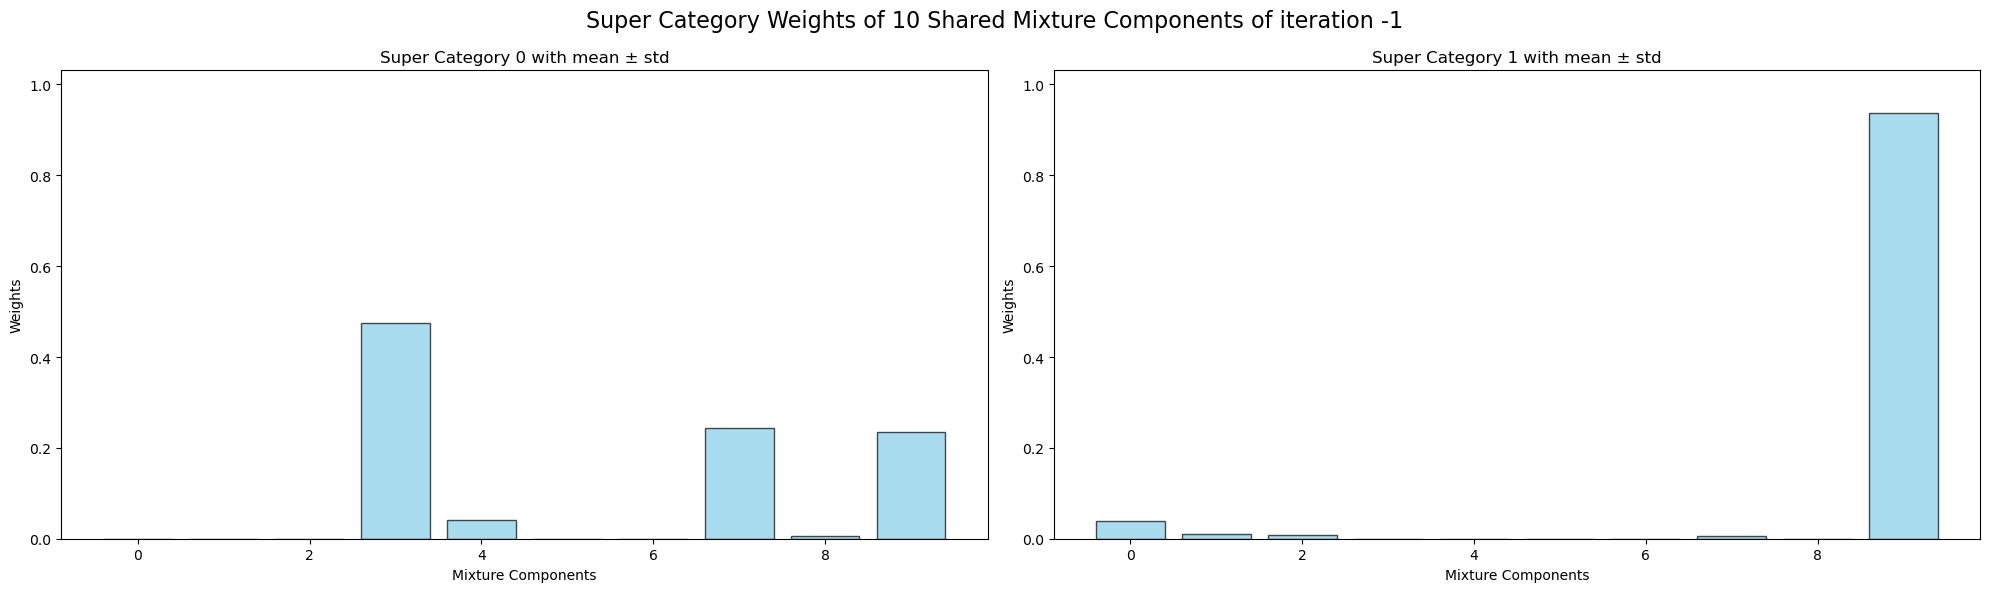

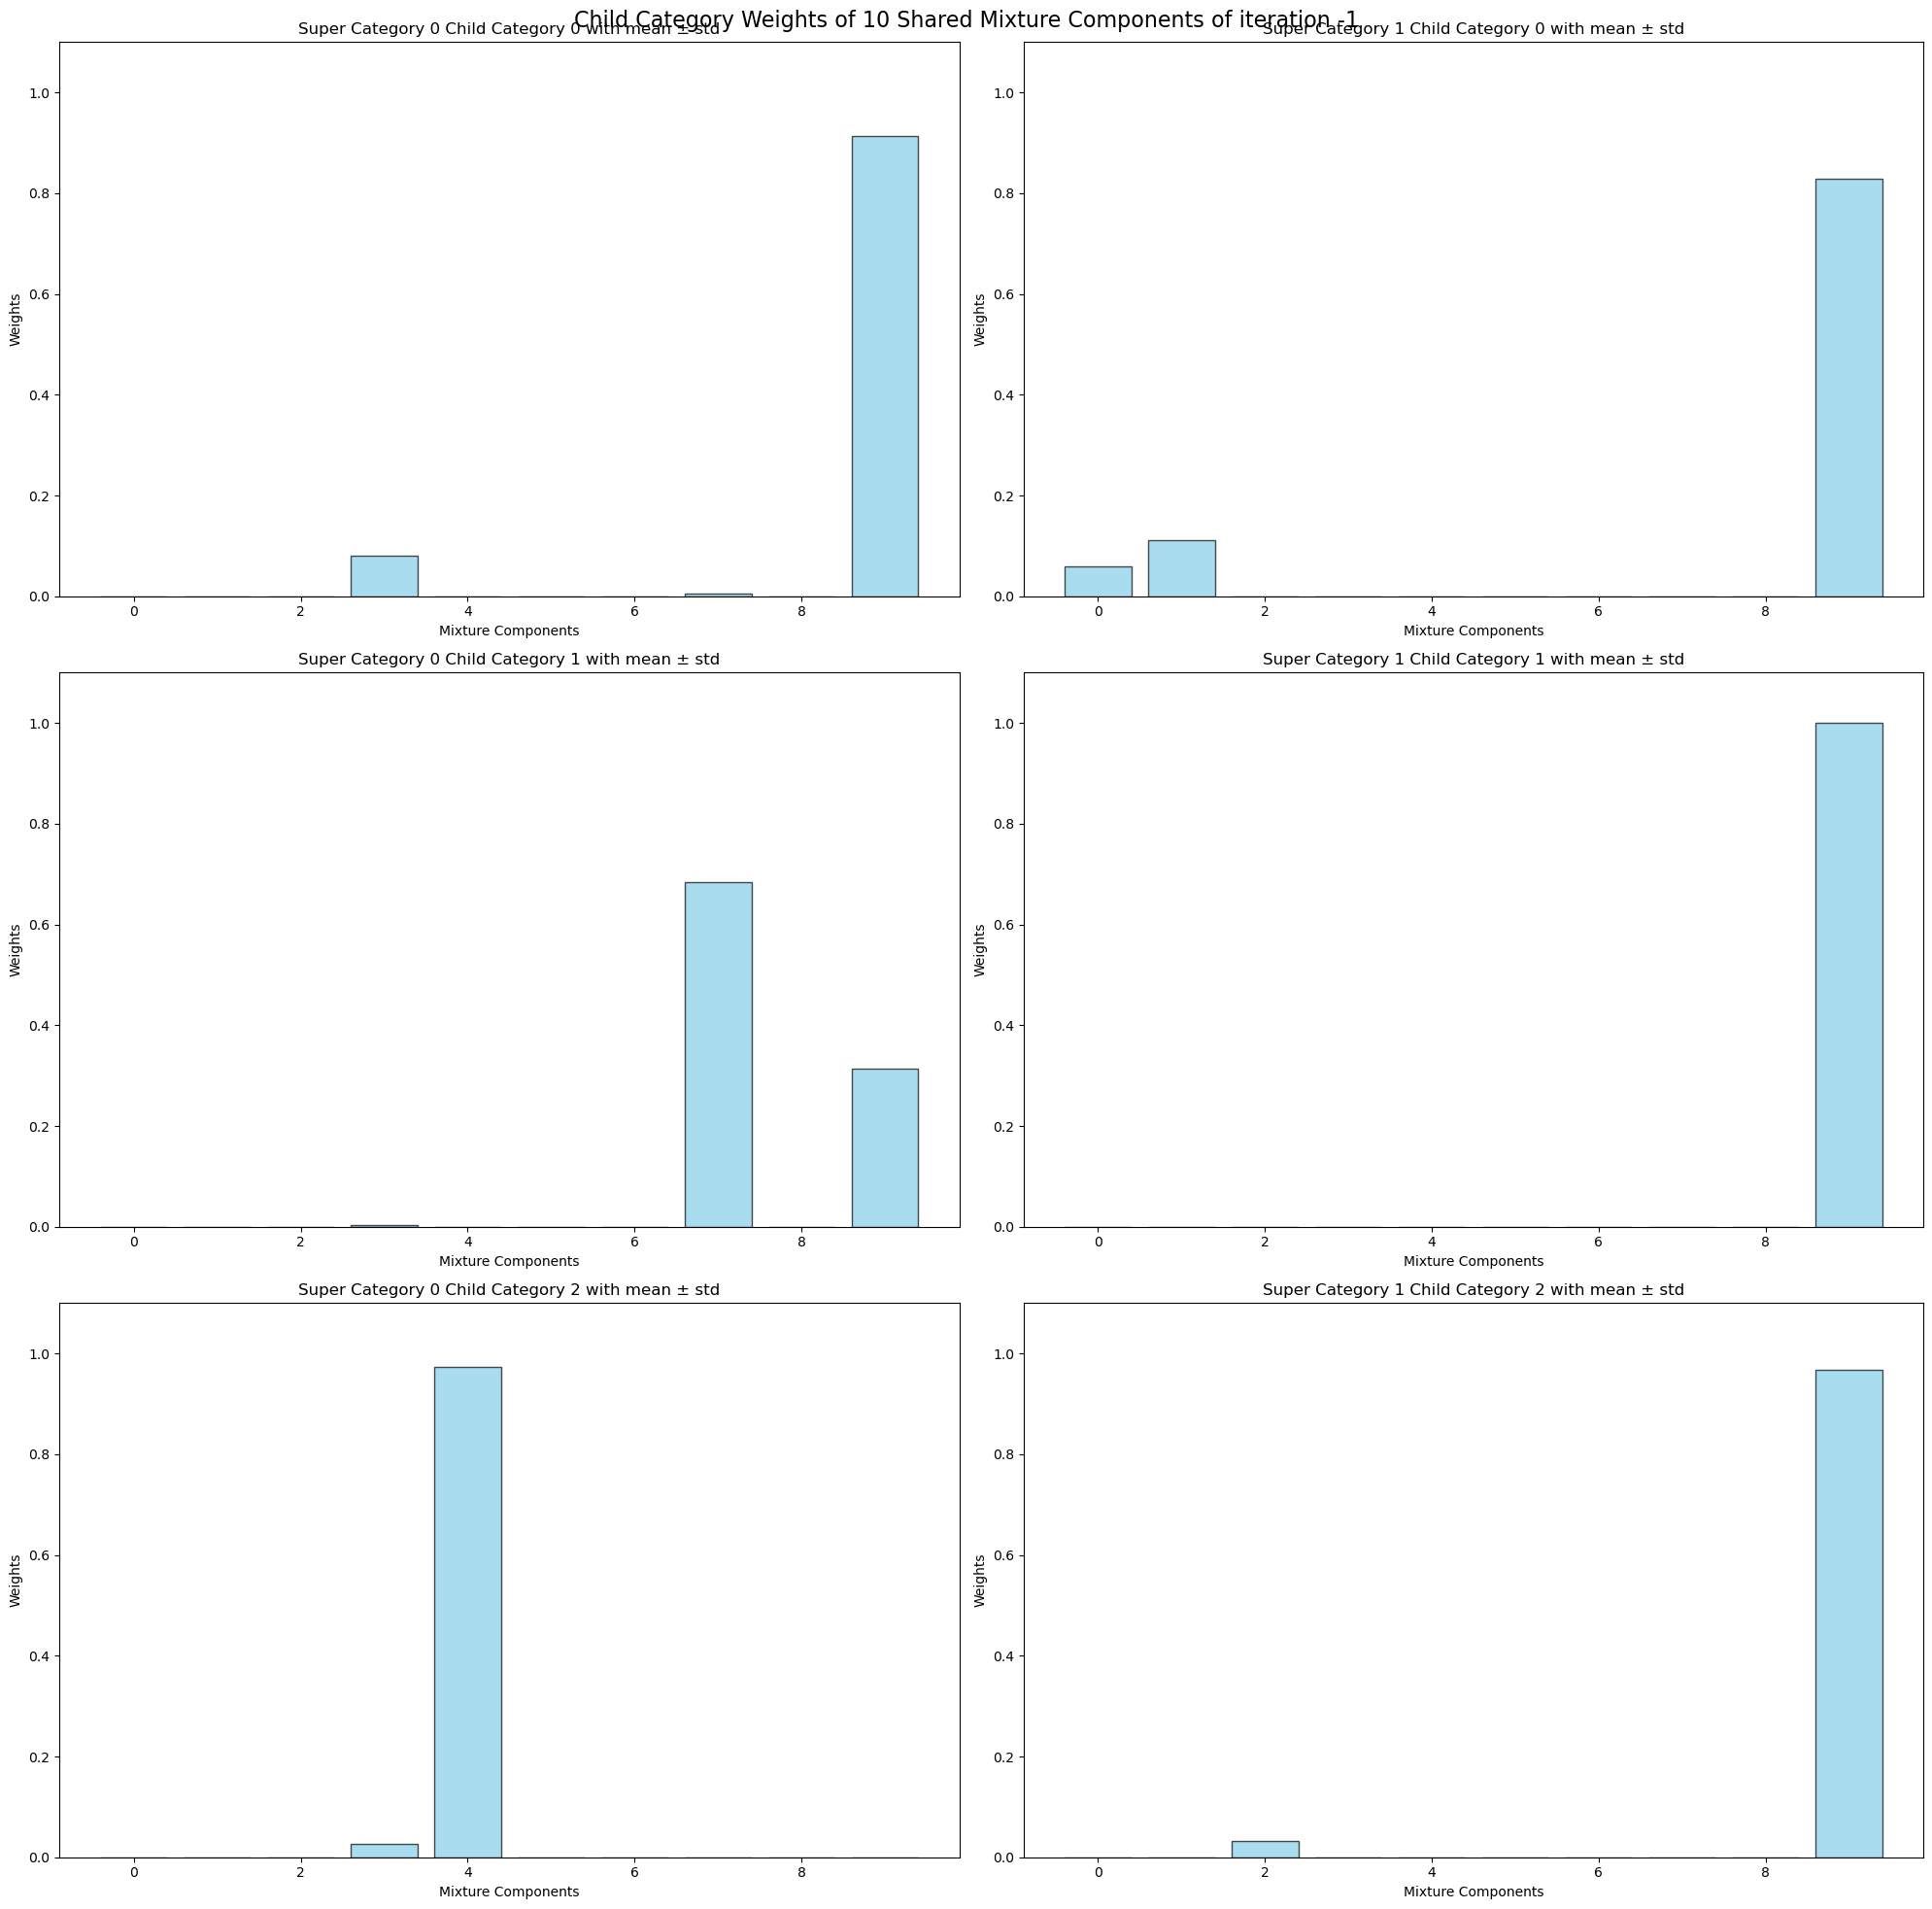

Gibbs Sampling (Iter 52) LogProb -47437.19: 100%|██████████| 53/53 [43:17<00:00, 49.01s/it]


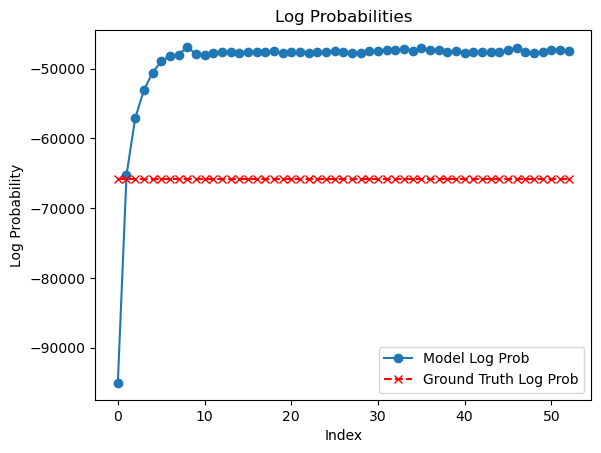

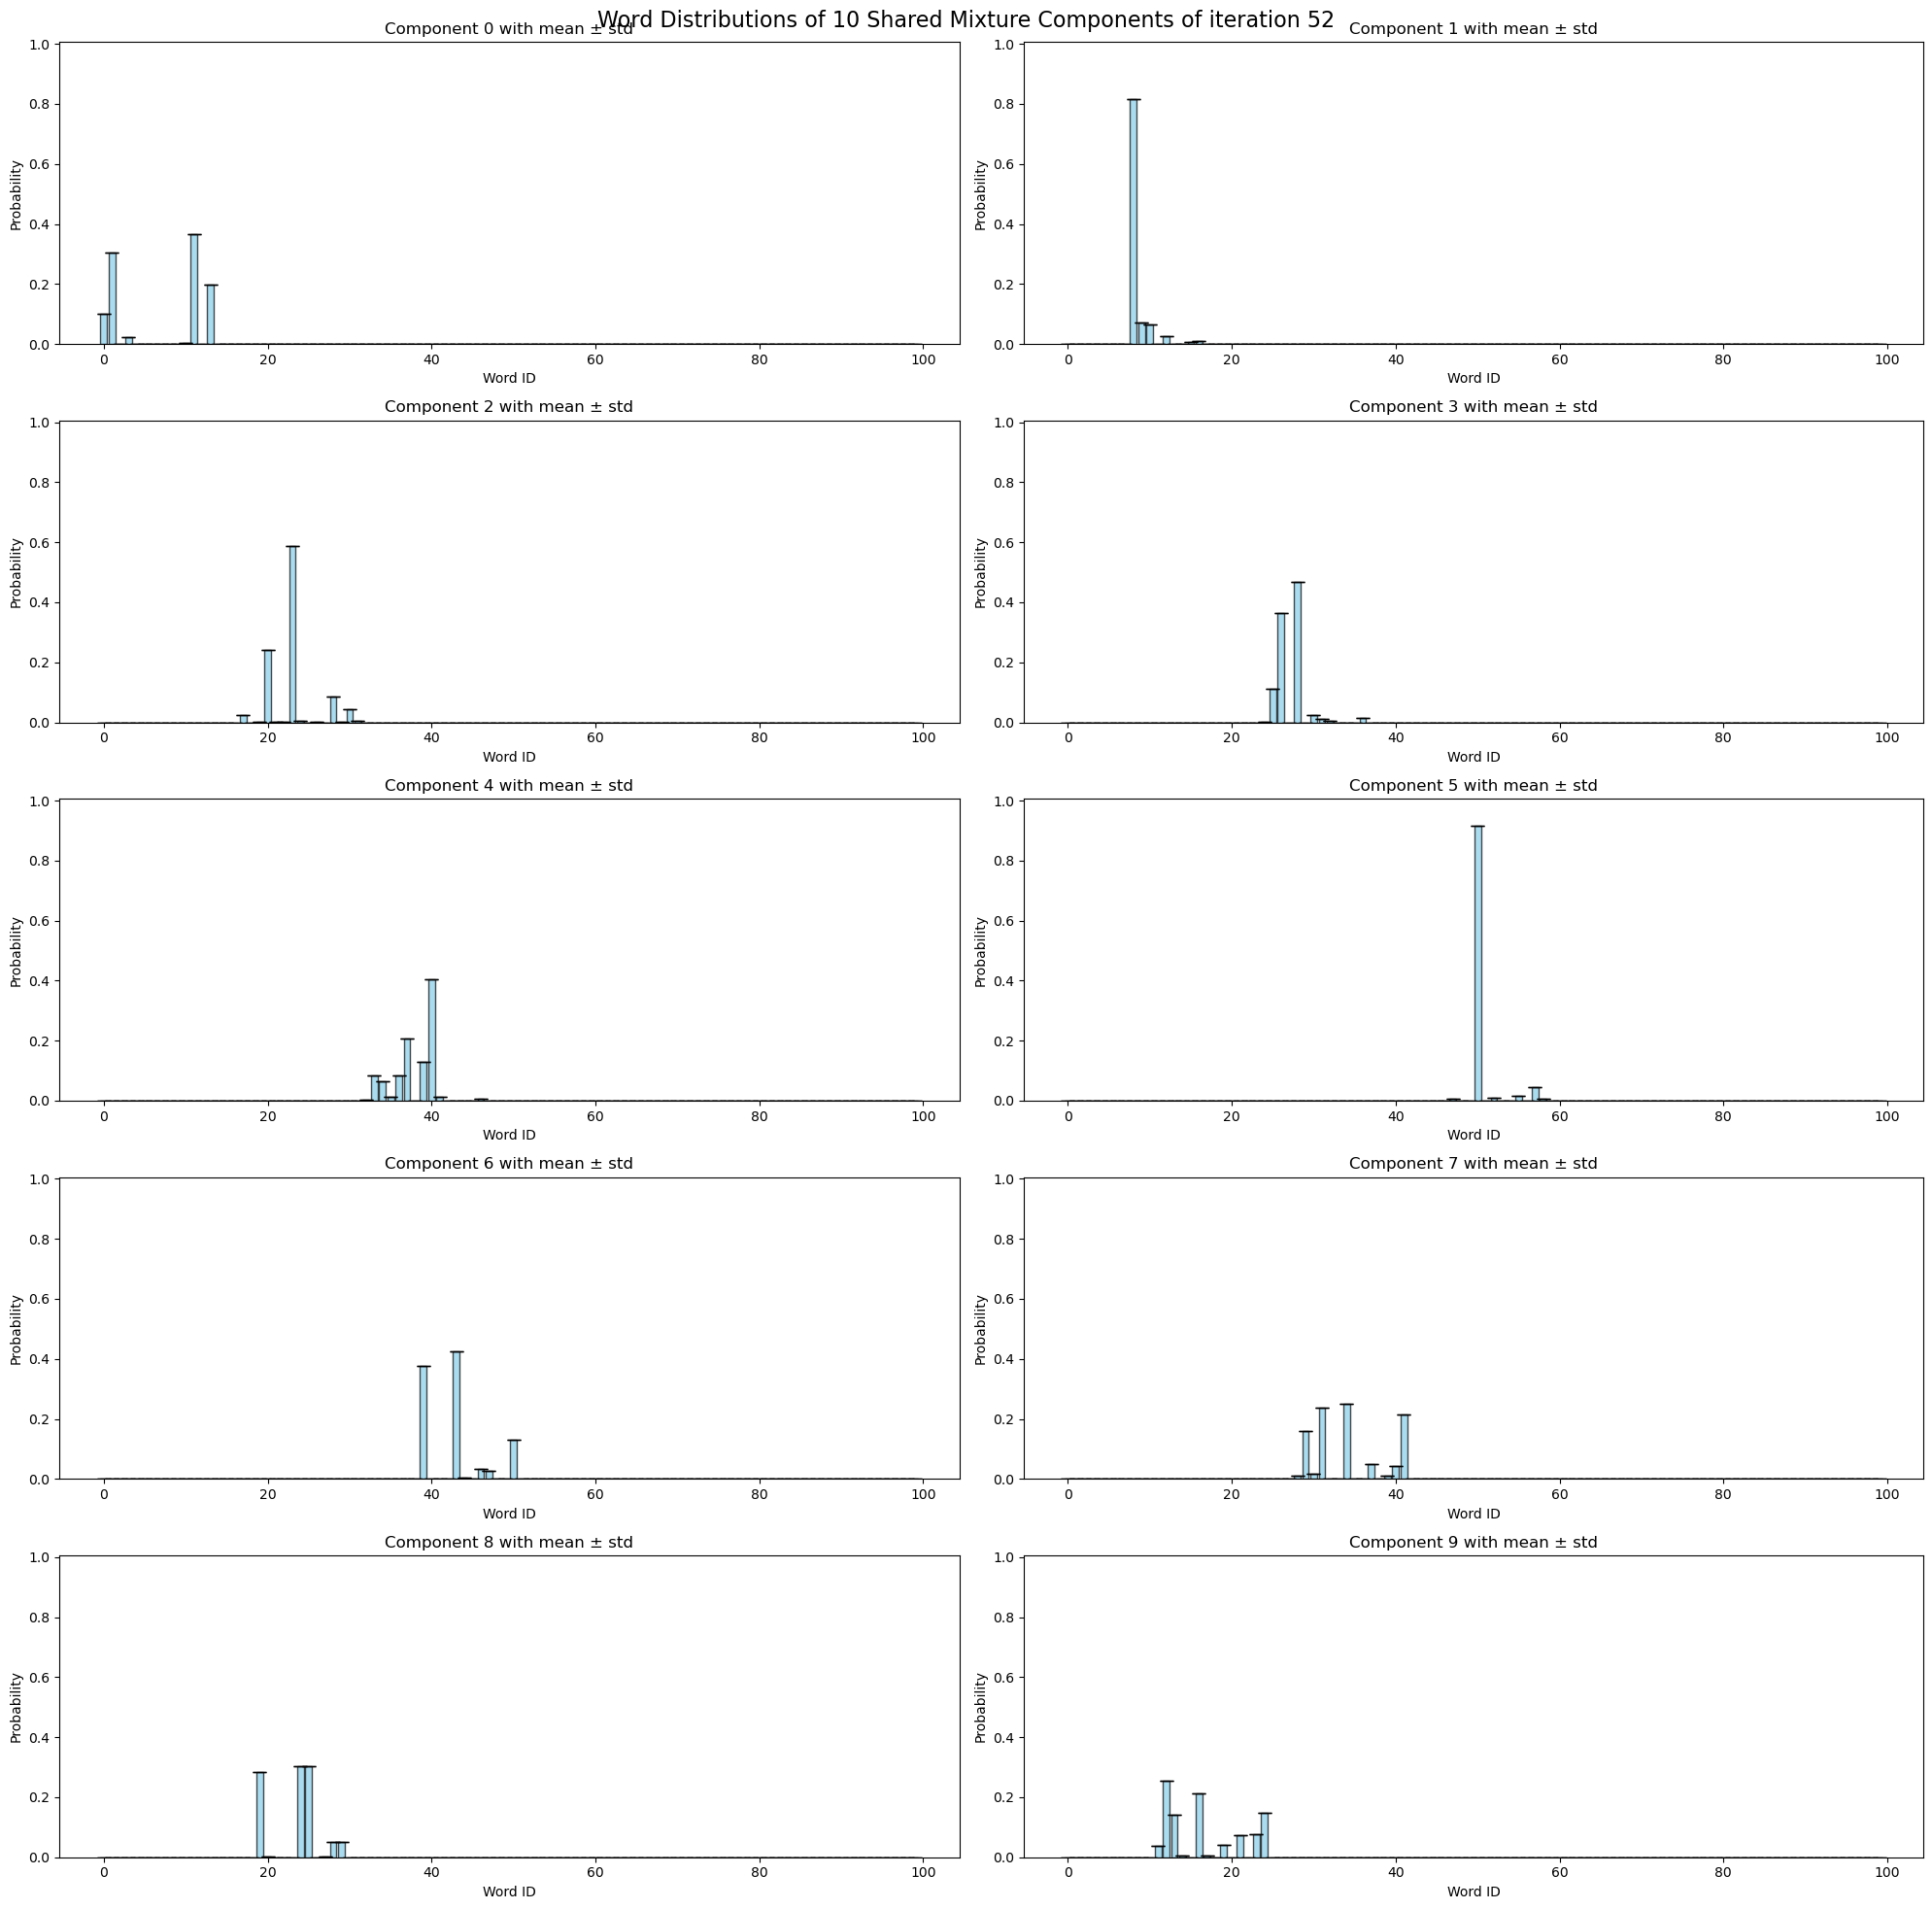

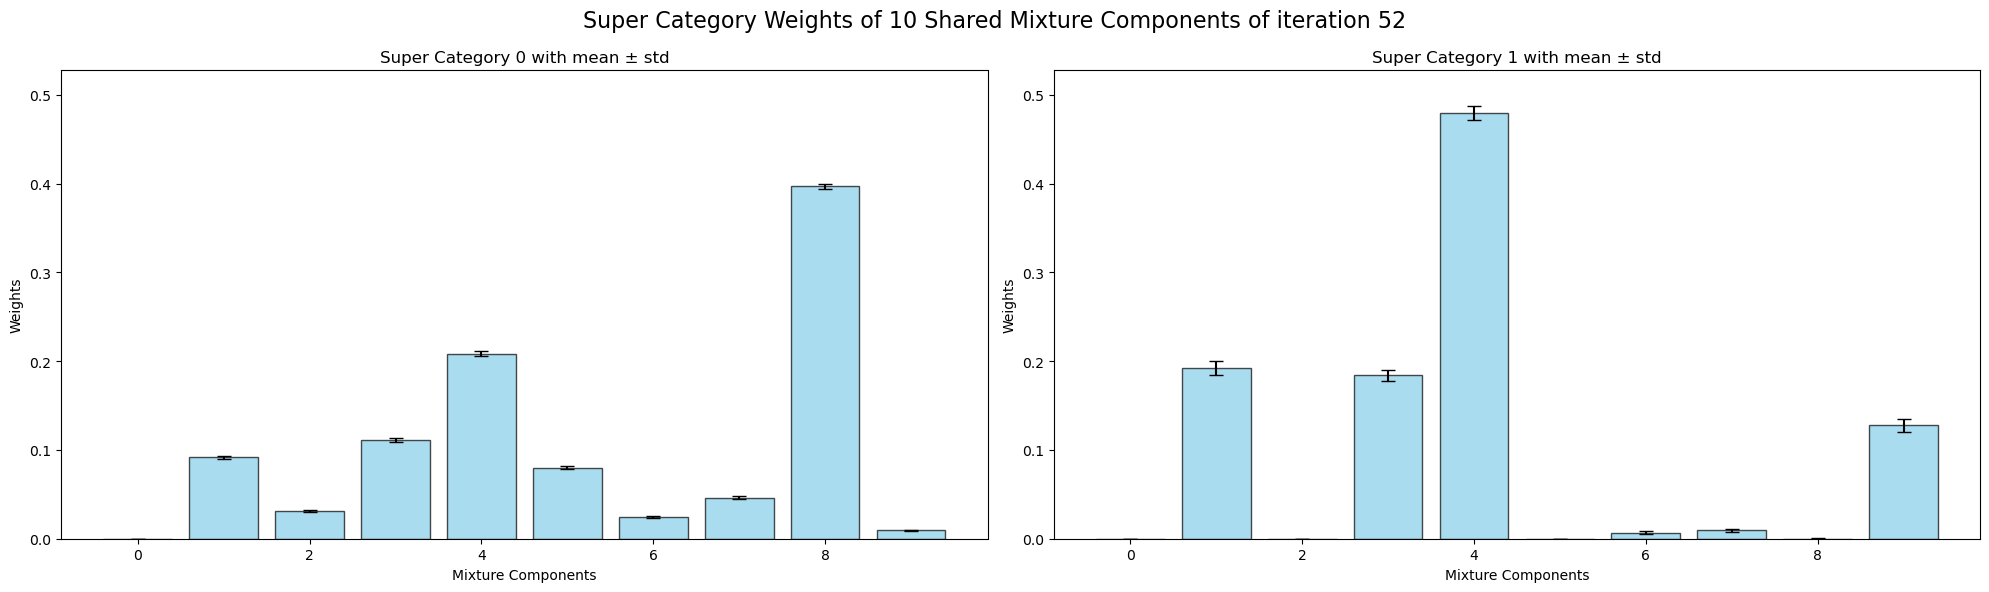

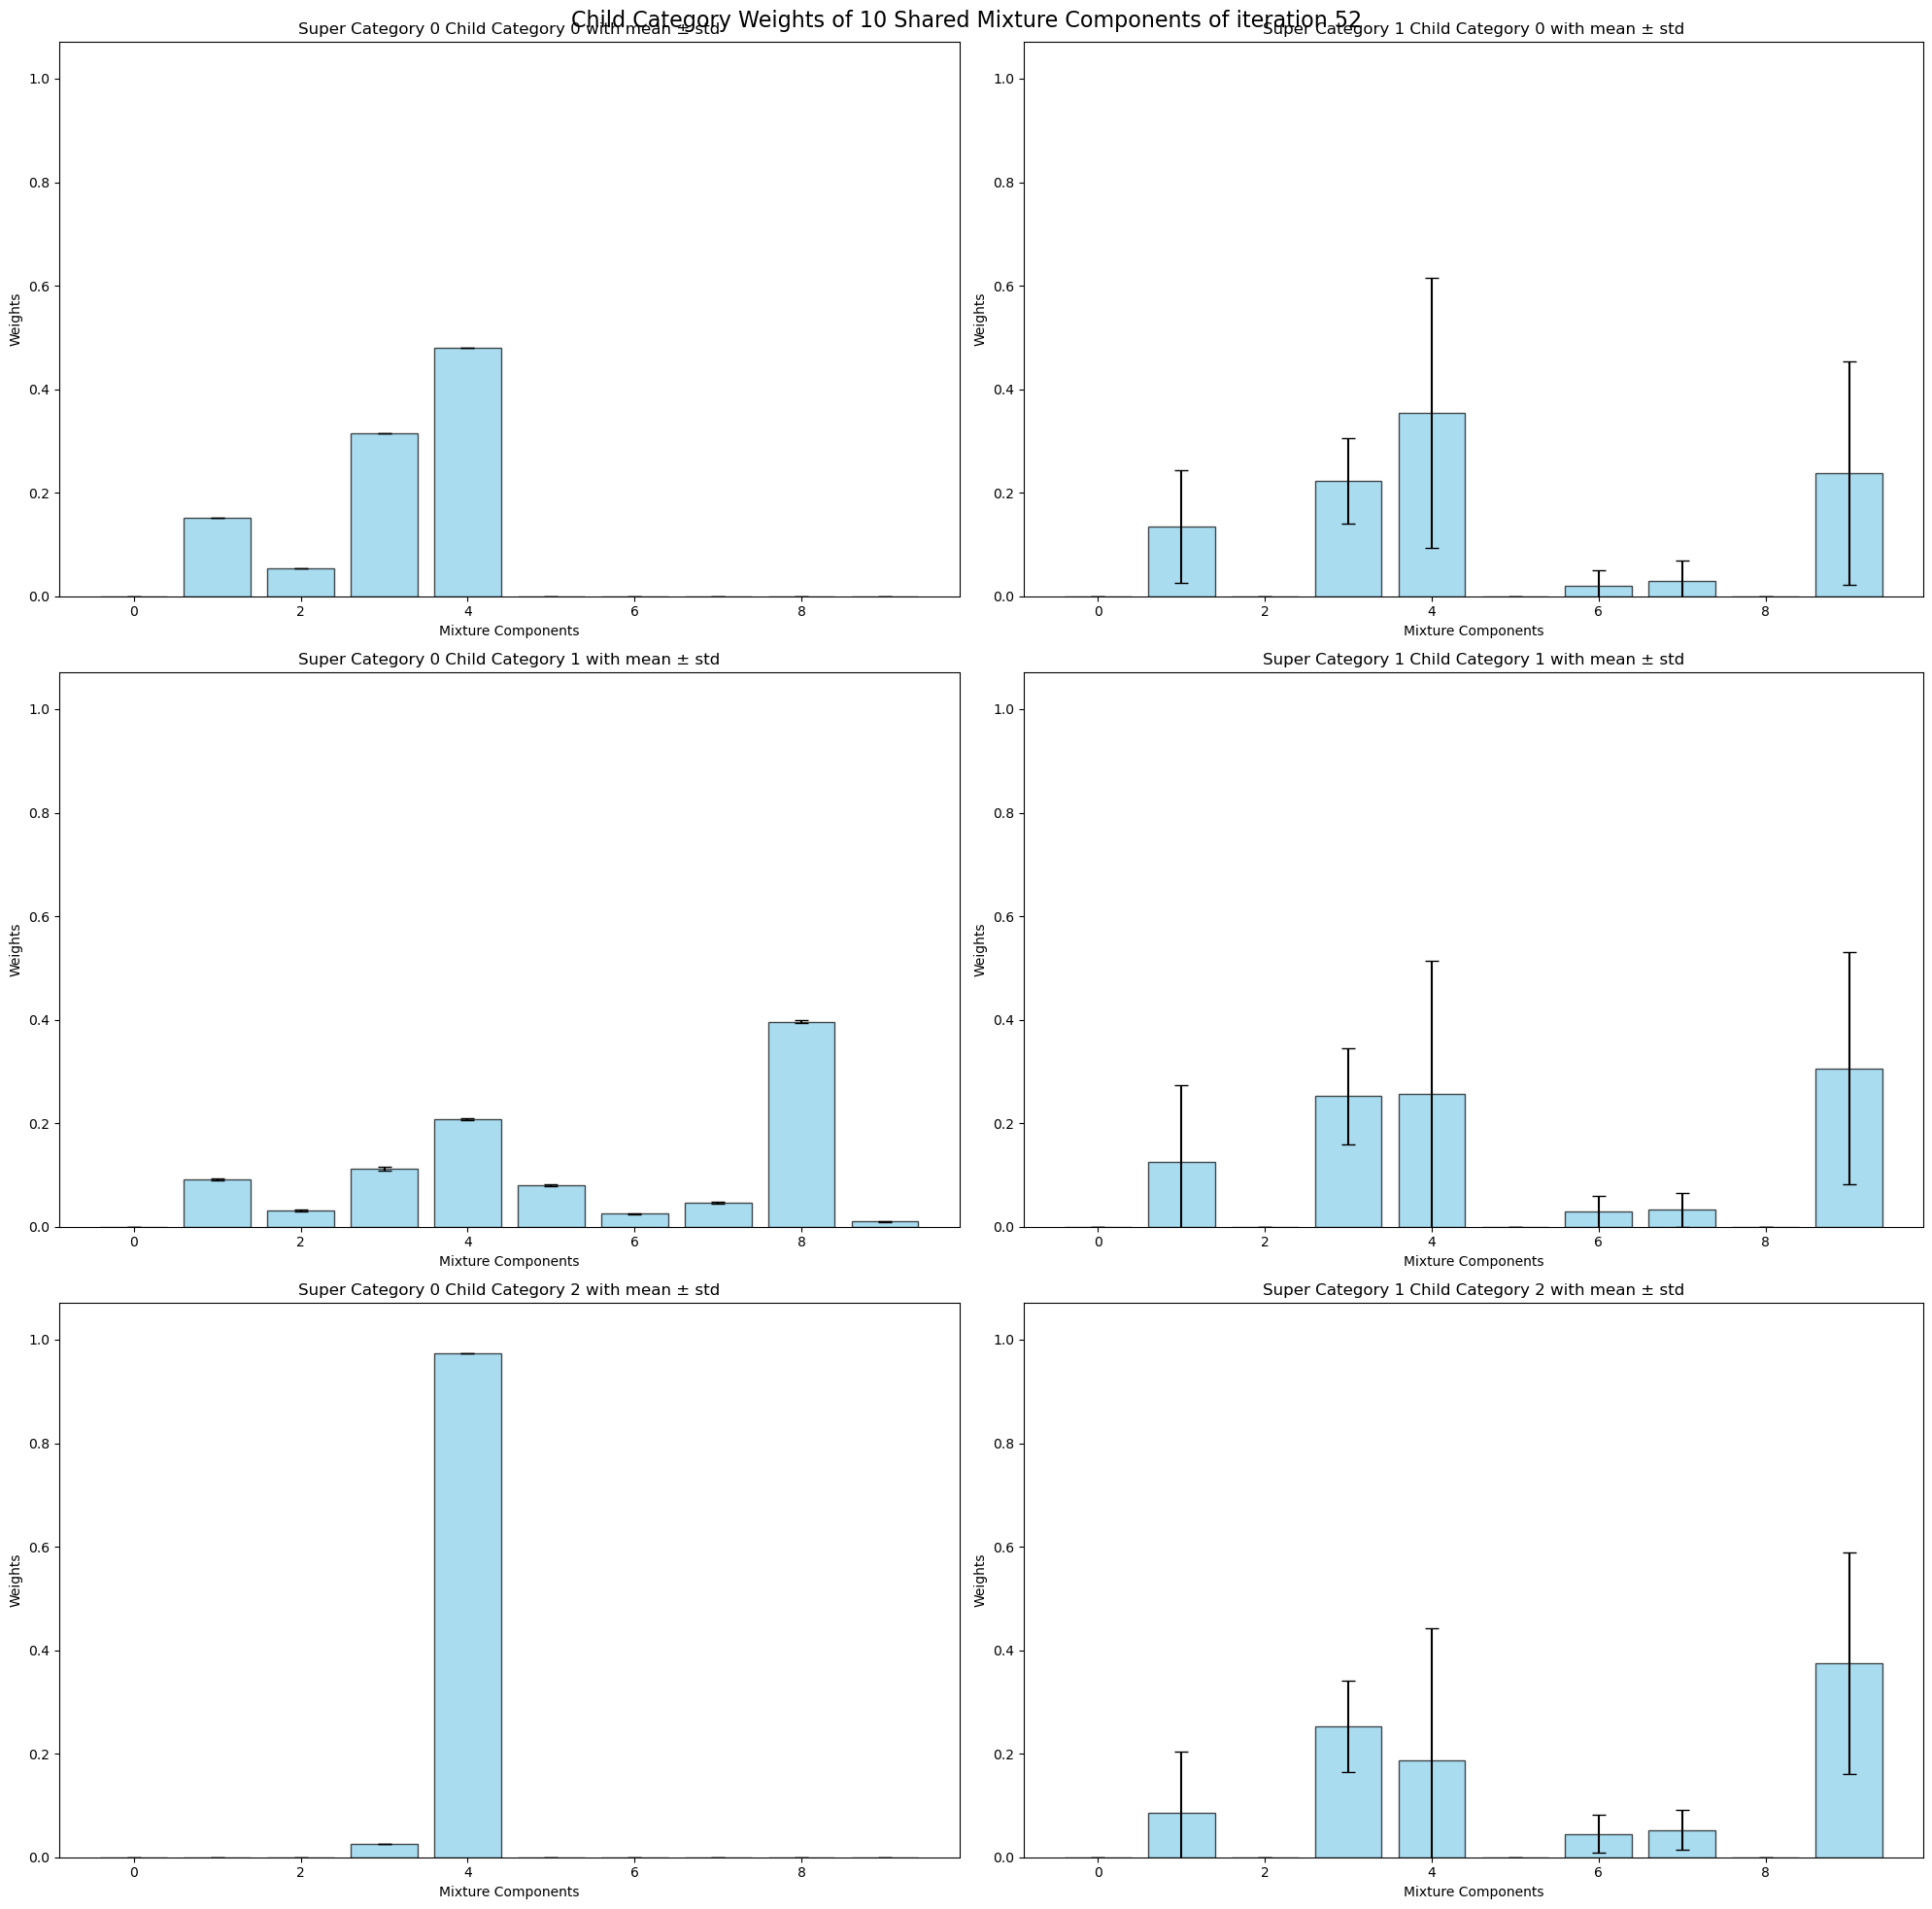

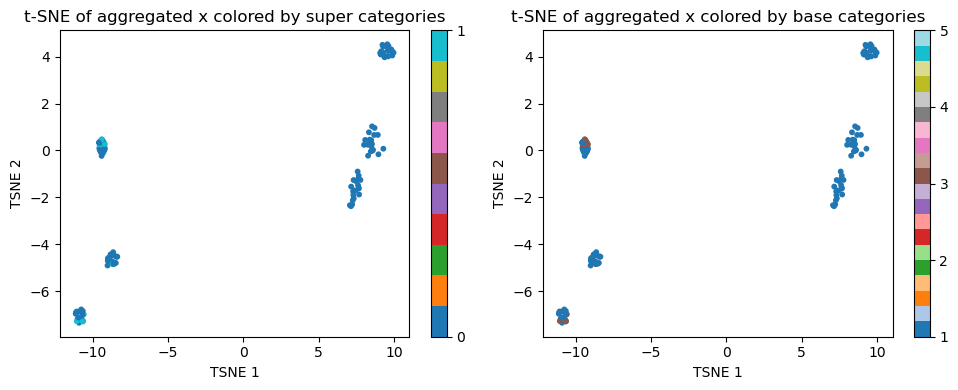

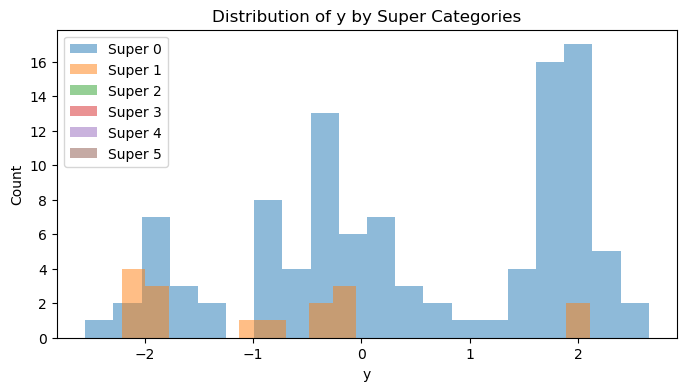

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


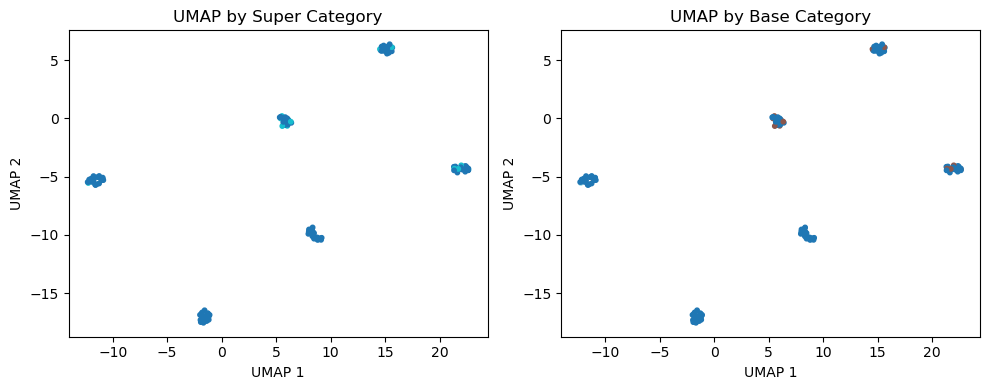

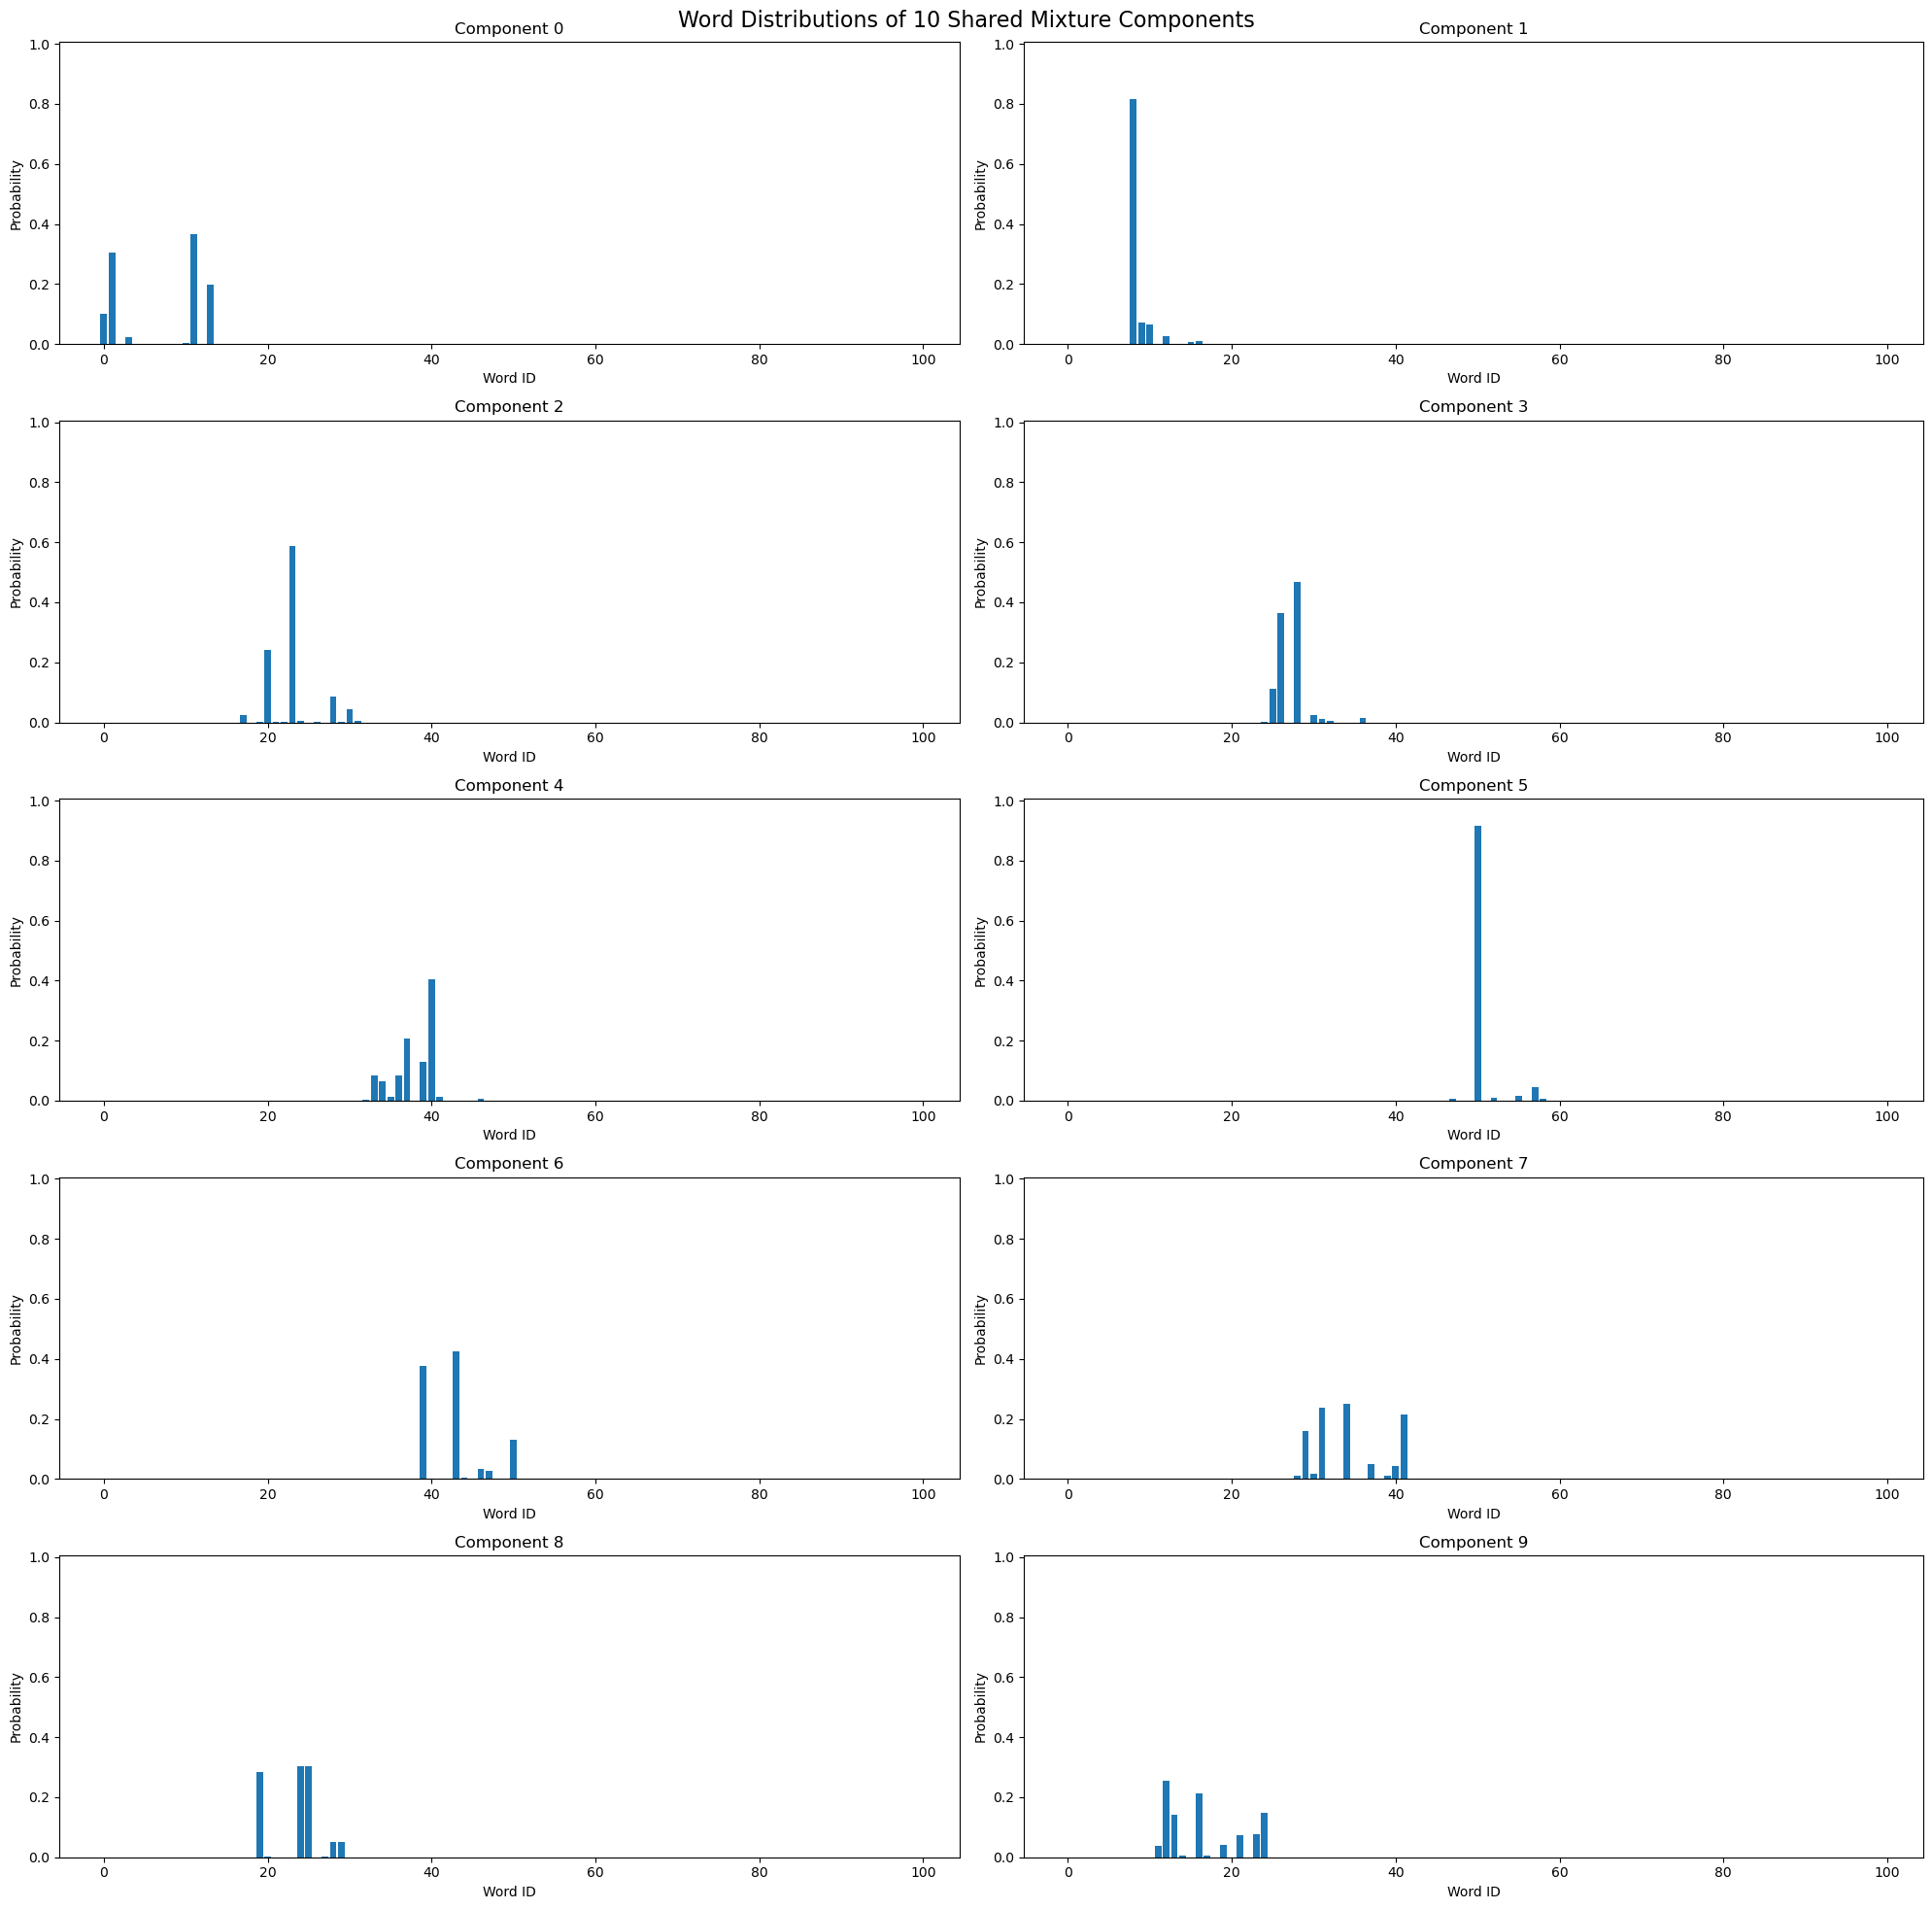

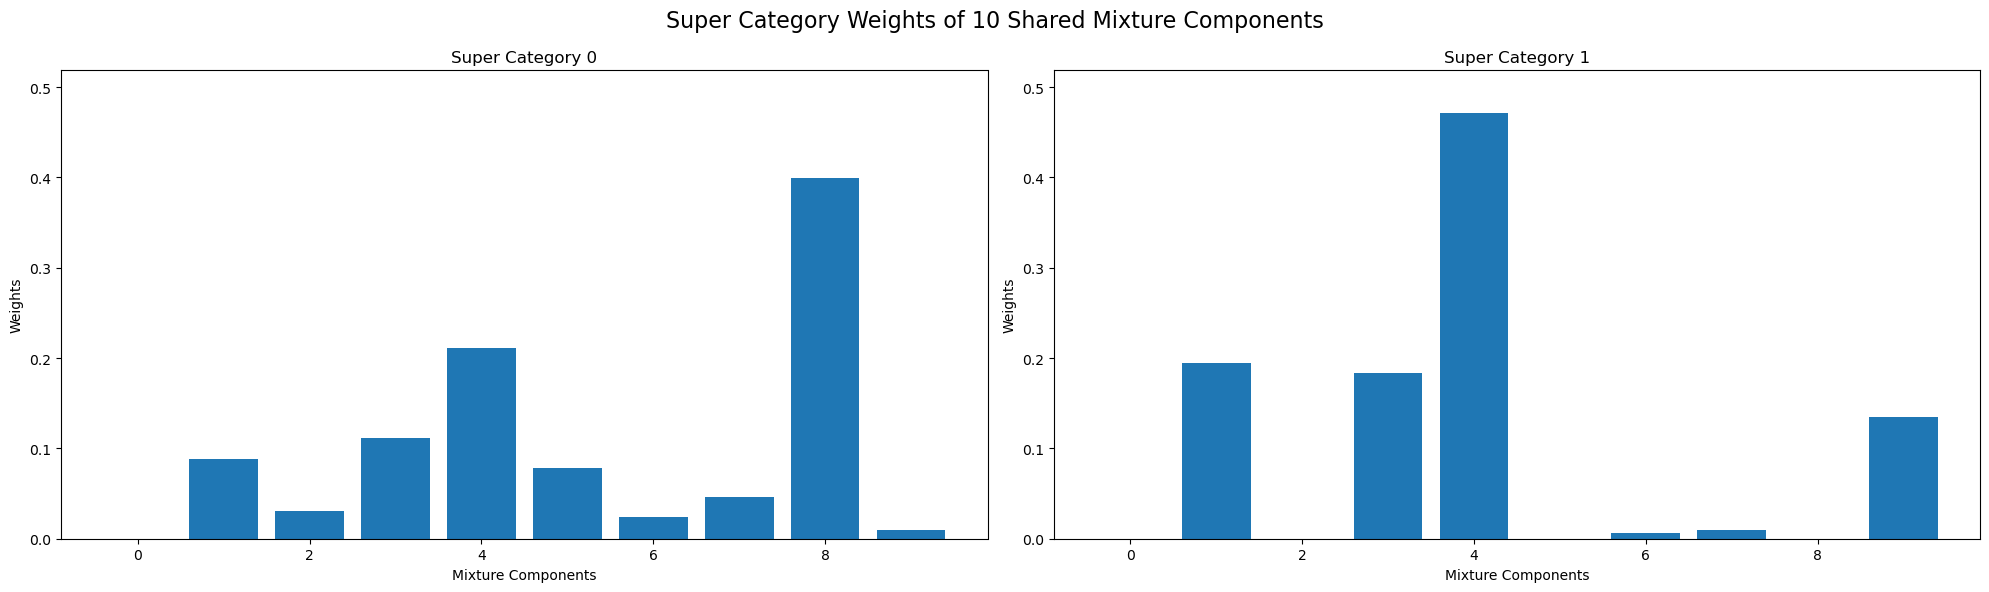

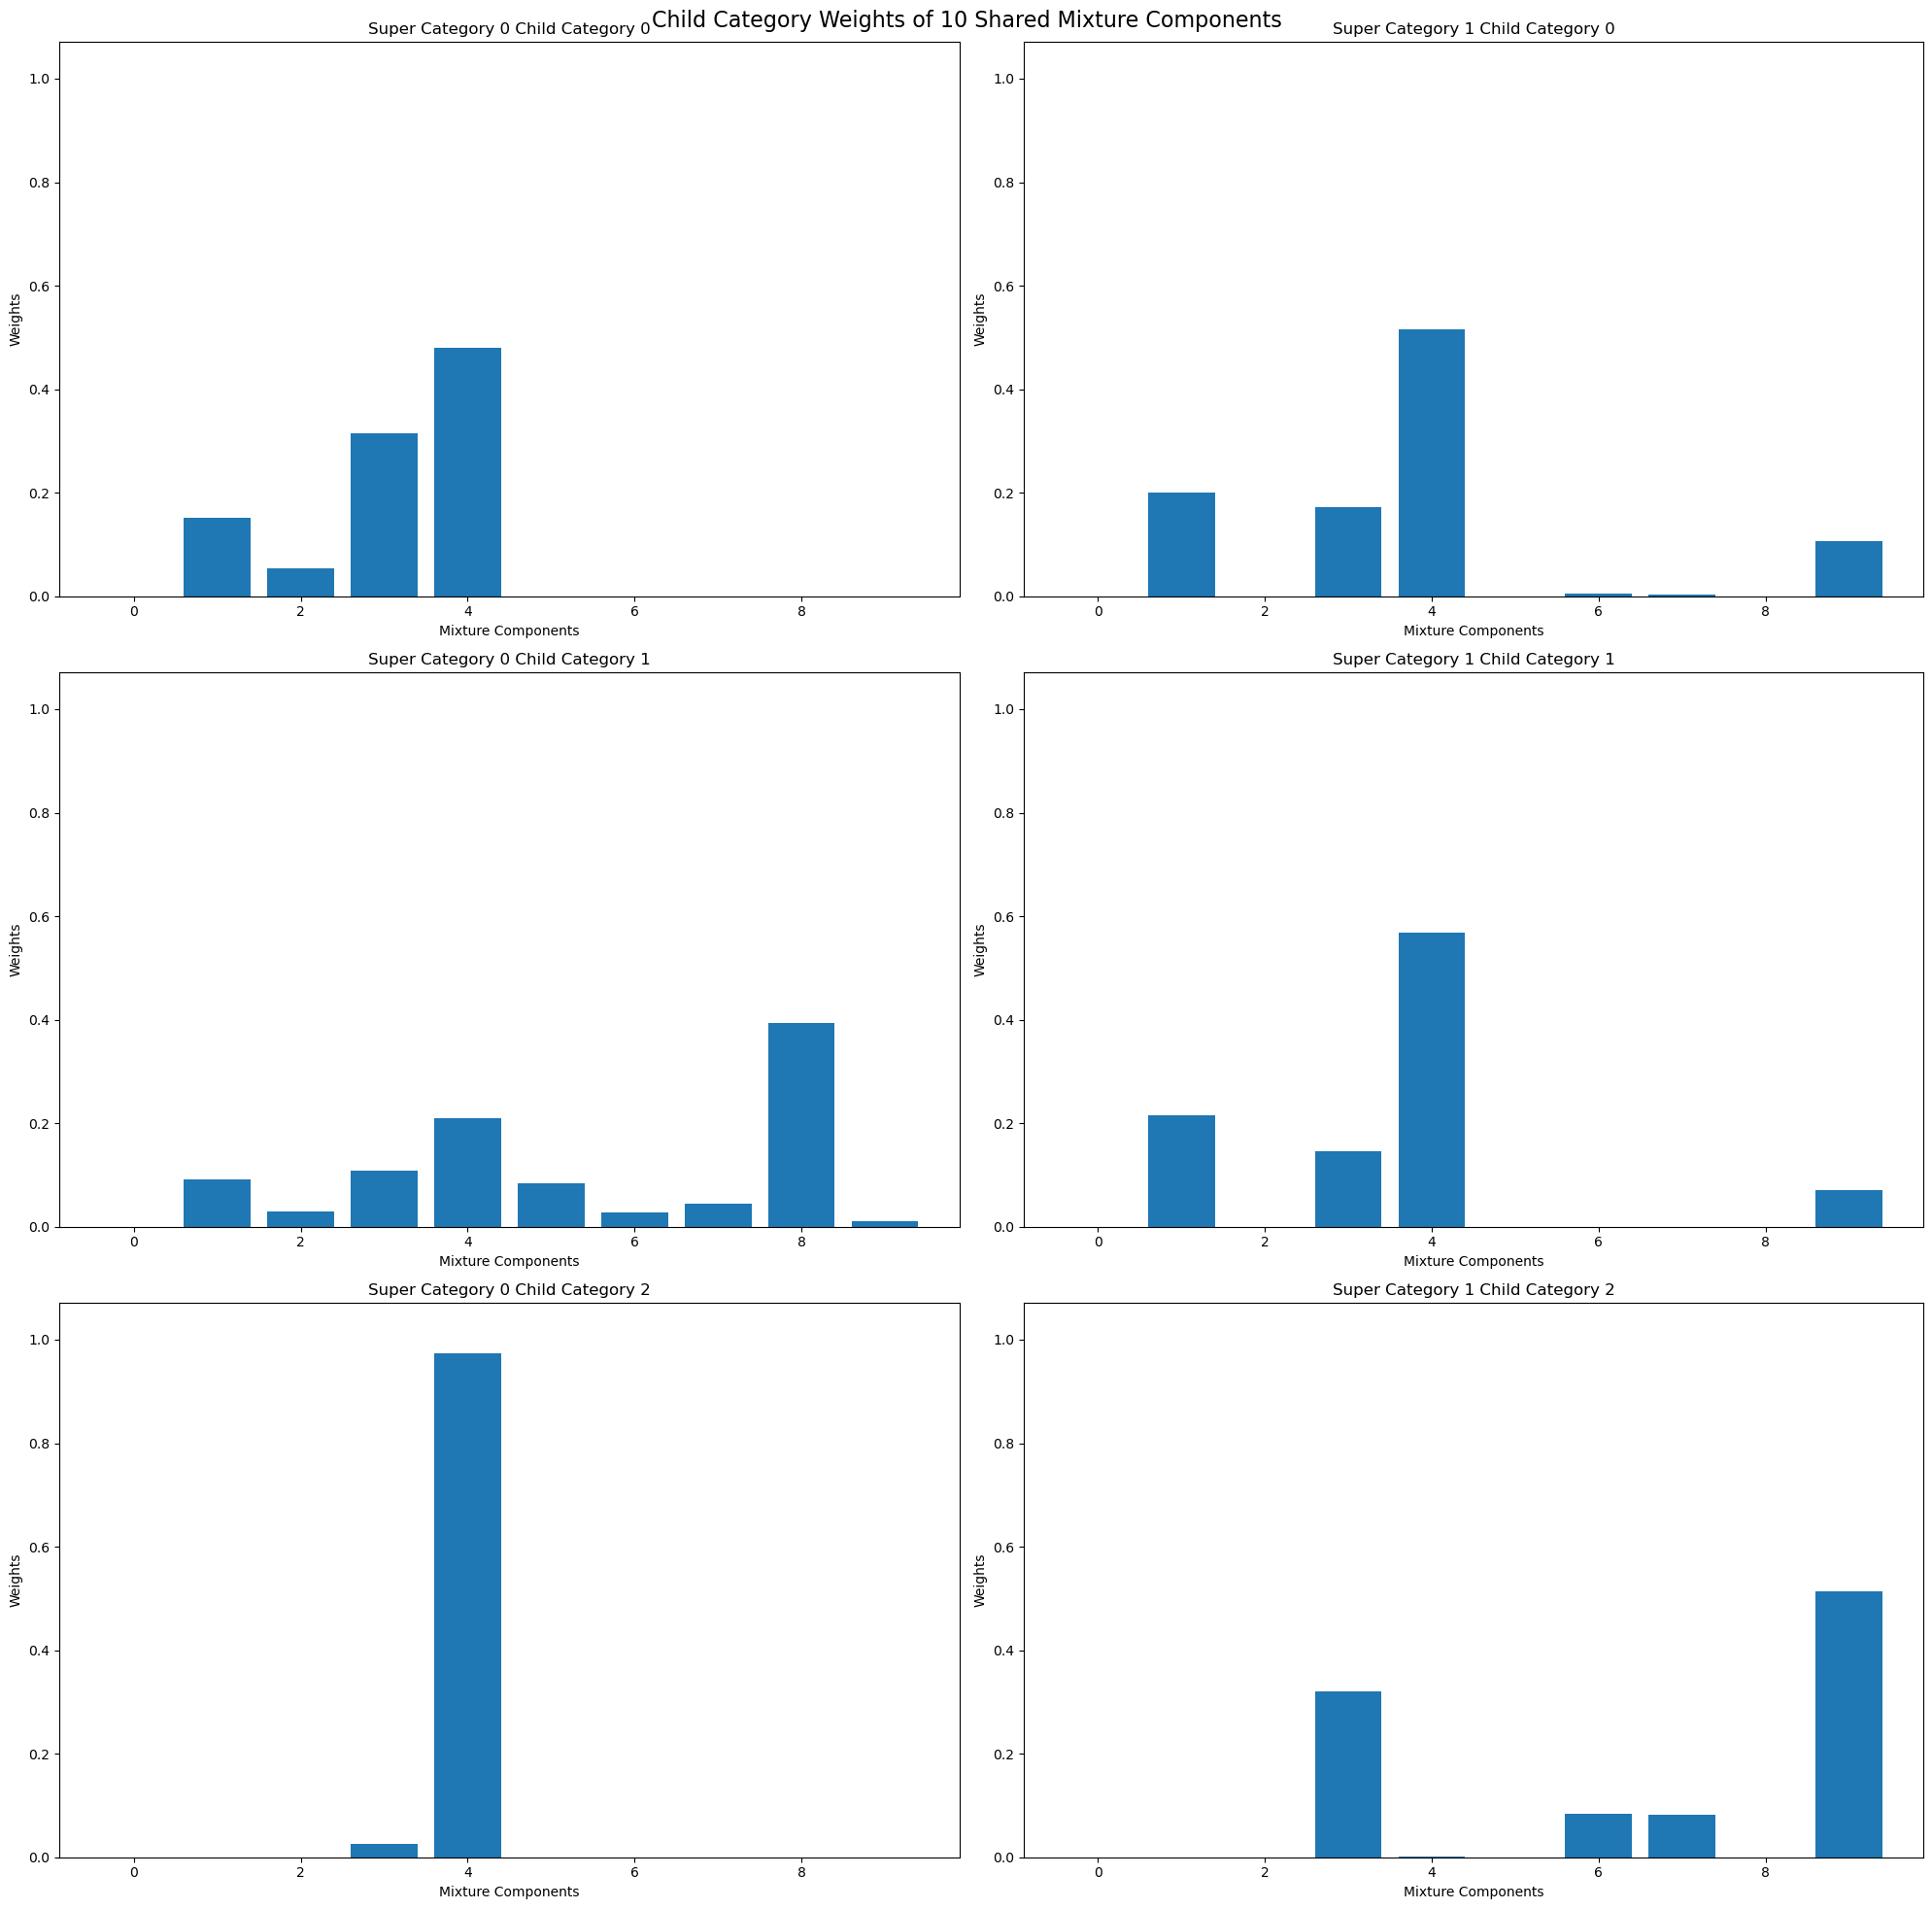

72 out of 120 super category labels are different from ground truth.
107 out of 120 base category labels are different from ground truth.


In [ ]:
dataset = (data["x"], data["y"])
vocab_size = data["x"].shape[-1]
hdmm2 = hdp_model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, gen_mixture=data["word_dists"], device="cpu")
model_return2 = gibbs_sampler(jax.random.PRNGKey(0), hdmm2, struct_upbd, vocab_size, num_iters=52, gt=data, gen_ground_truth=True)
data_summary(model_return2, data, struct_upbd)

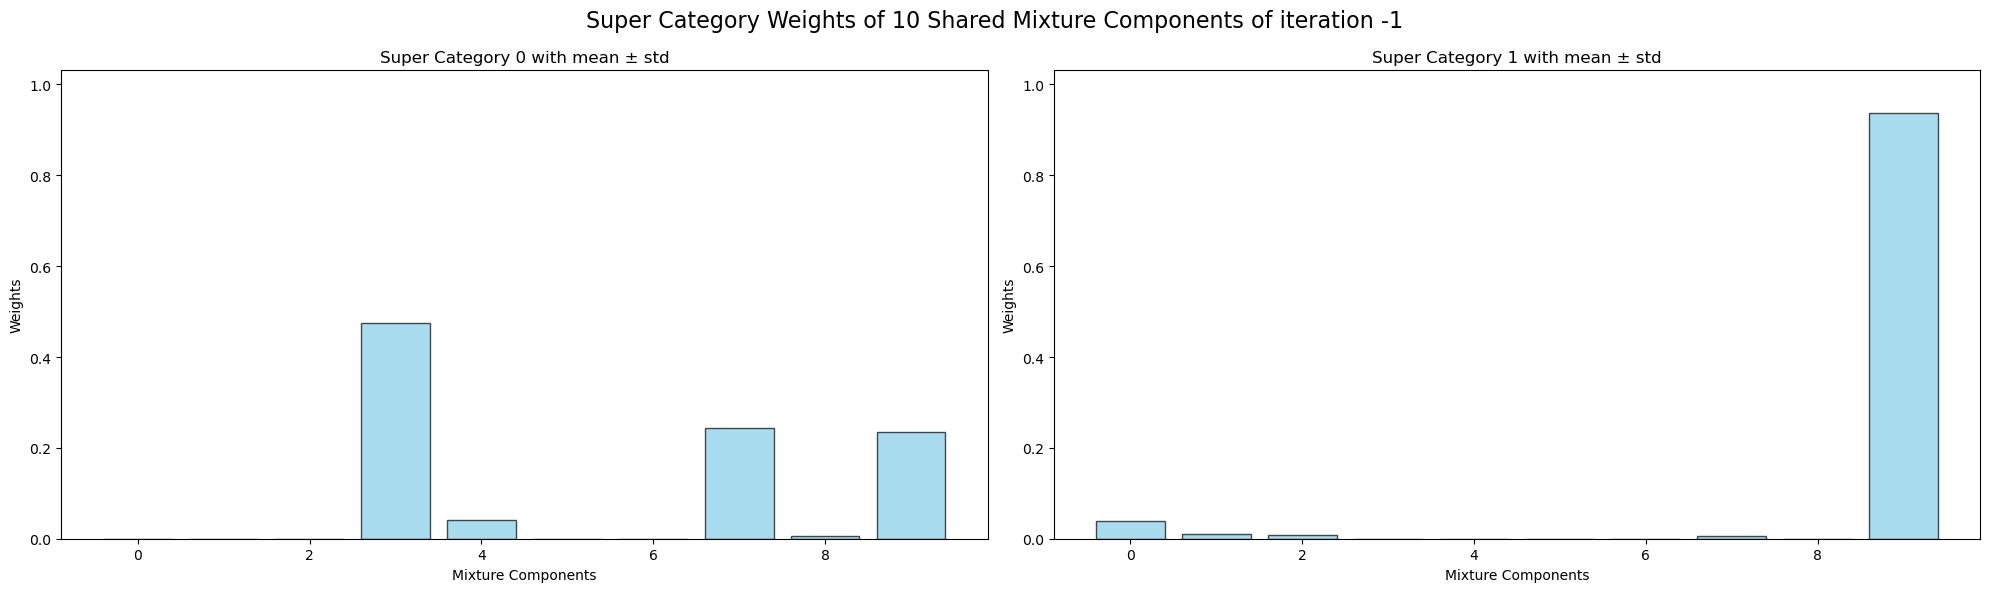

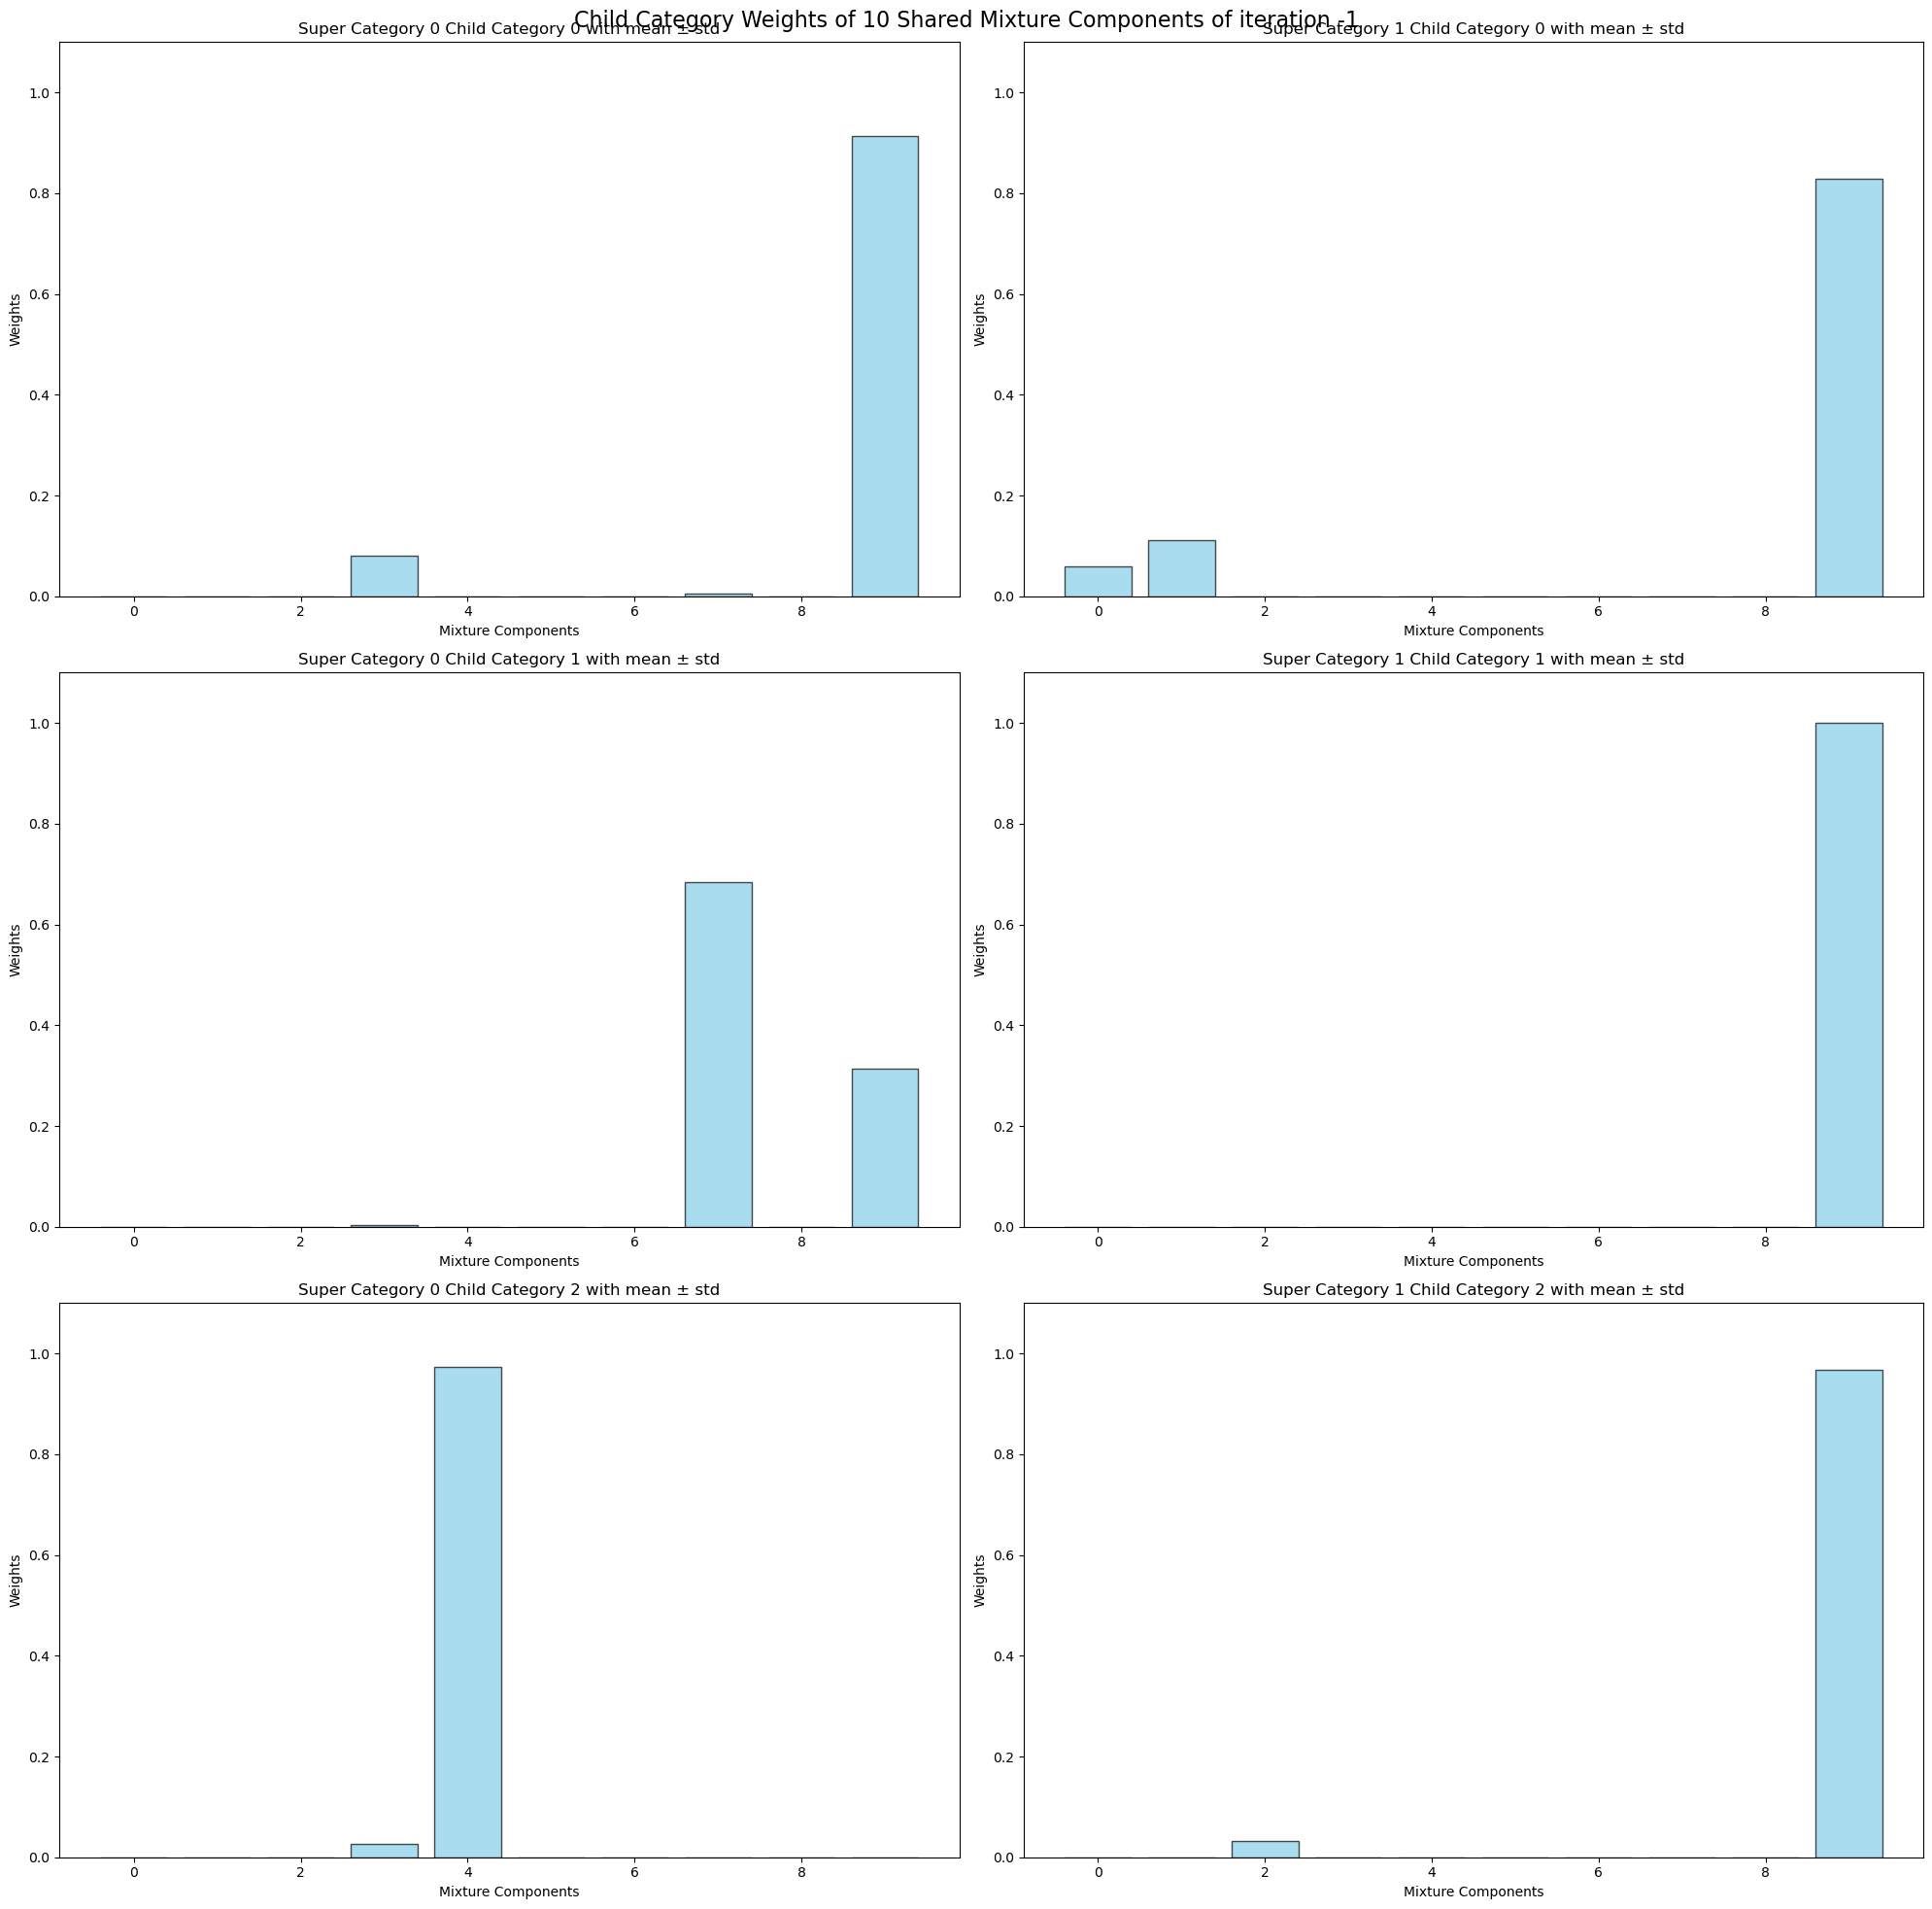

Gibbs Sampling (Iter 52) LogProb -50467.34: 100%|██████████| 53/53 [40:45<00:00, 46.14s/it]


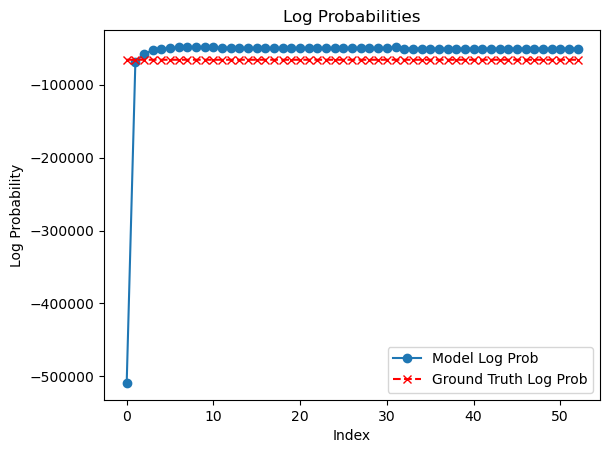

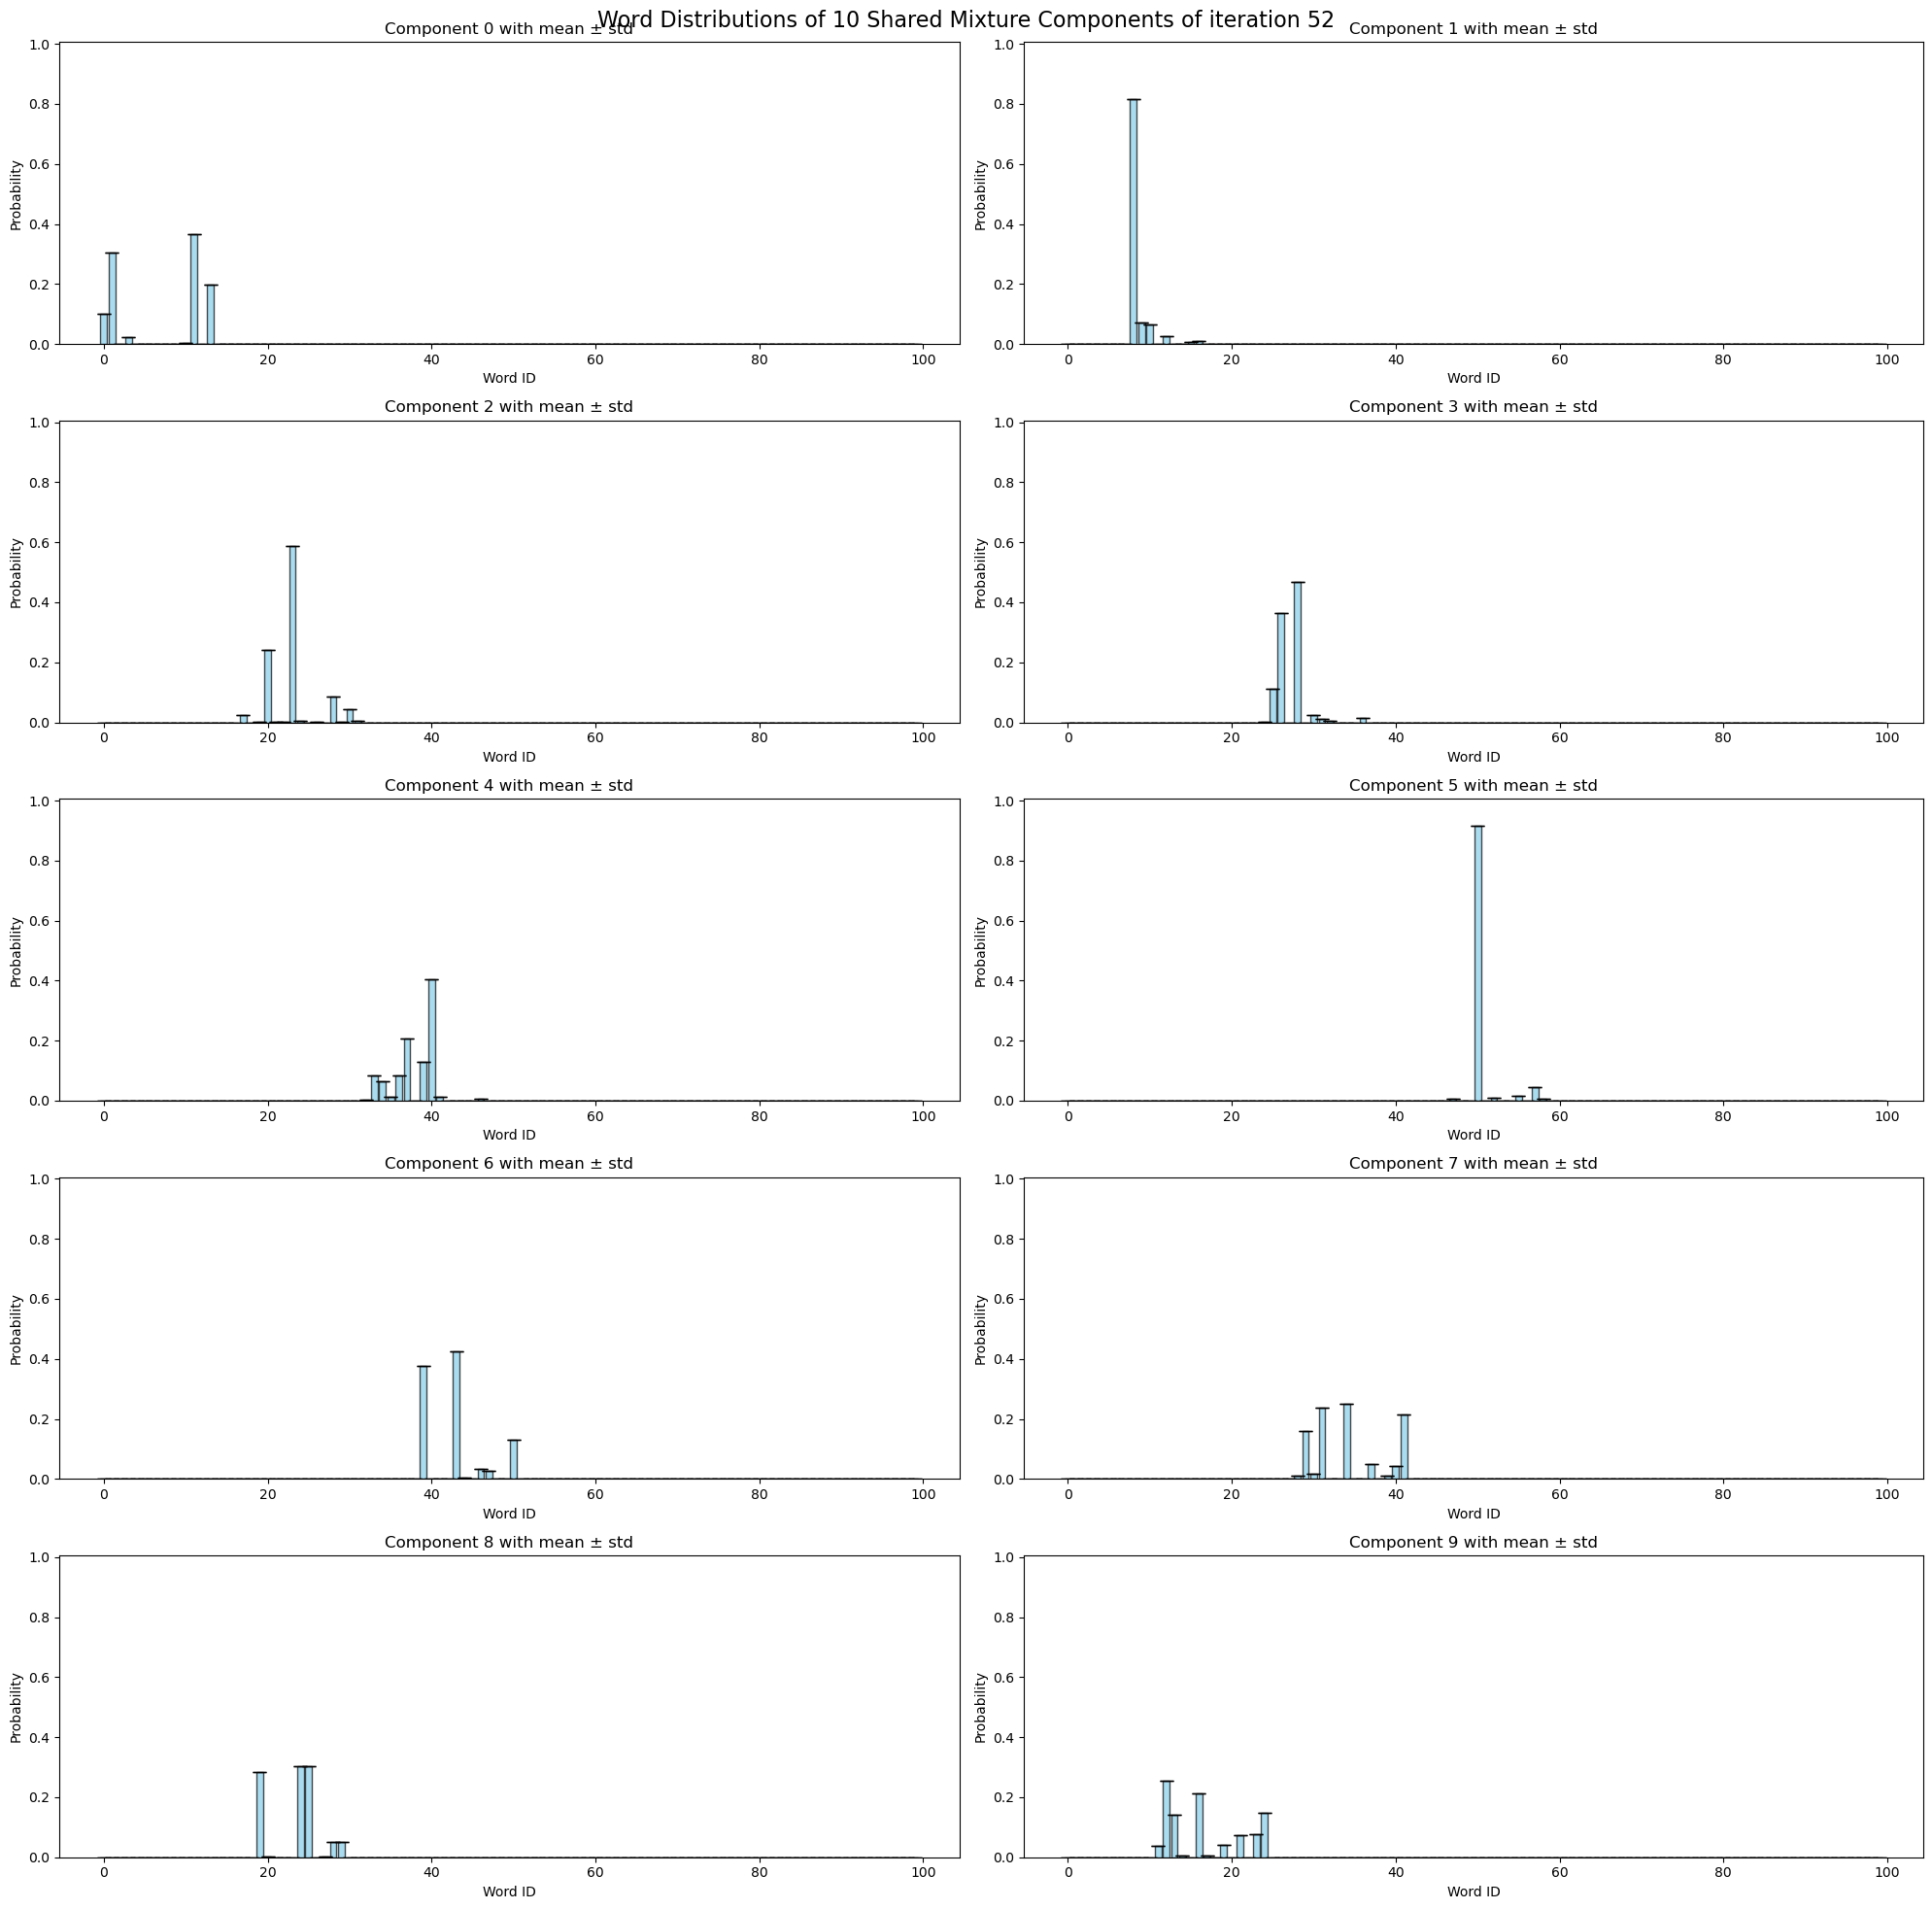

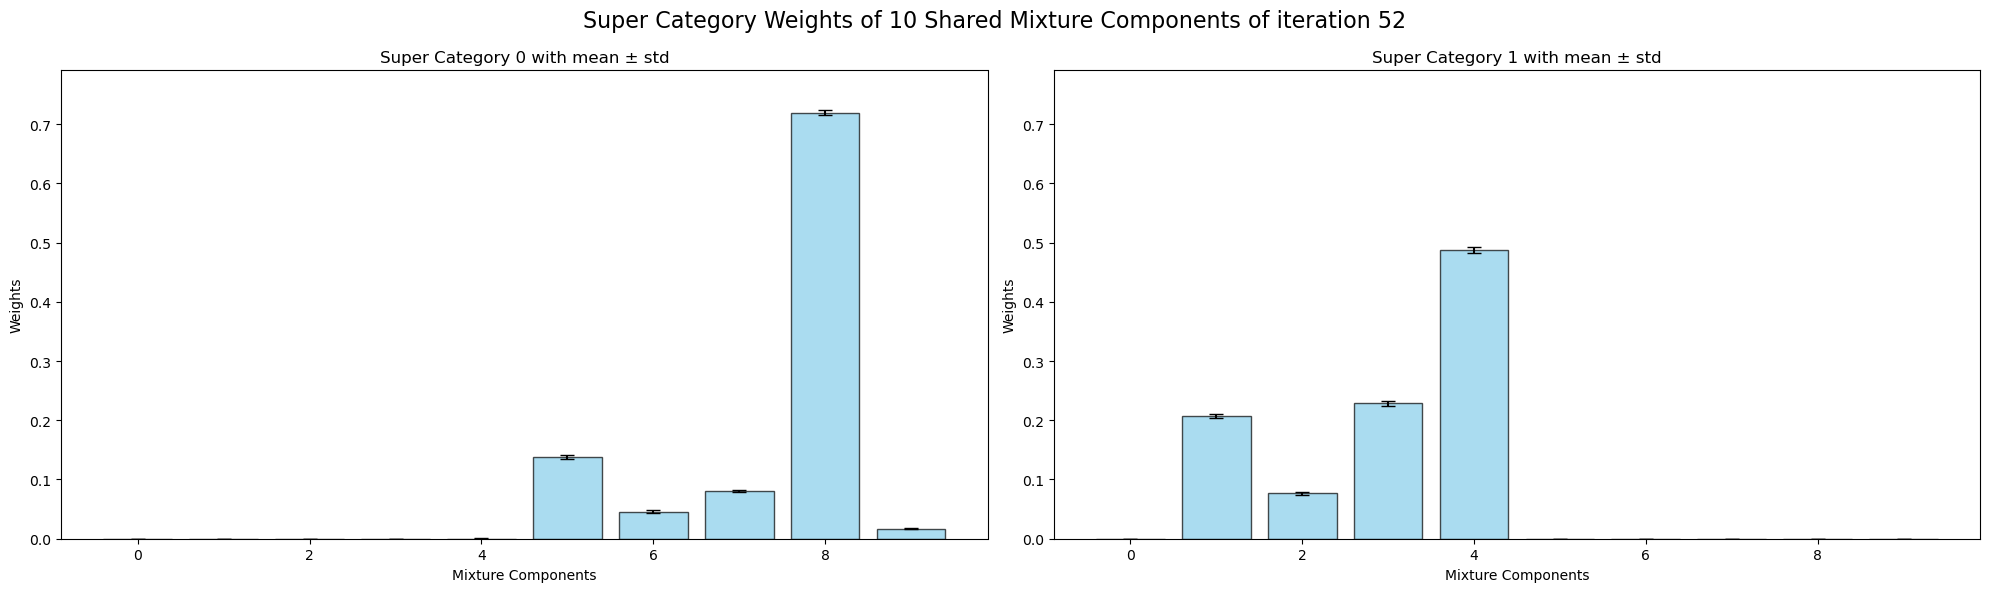

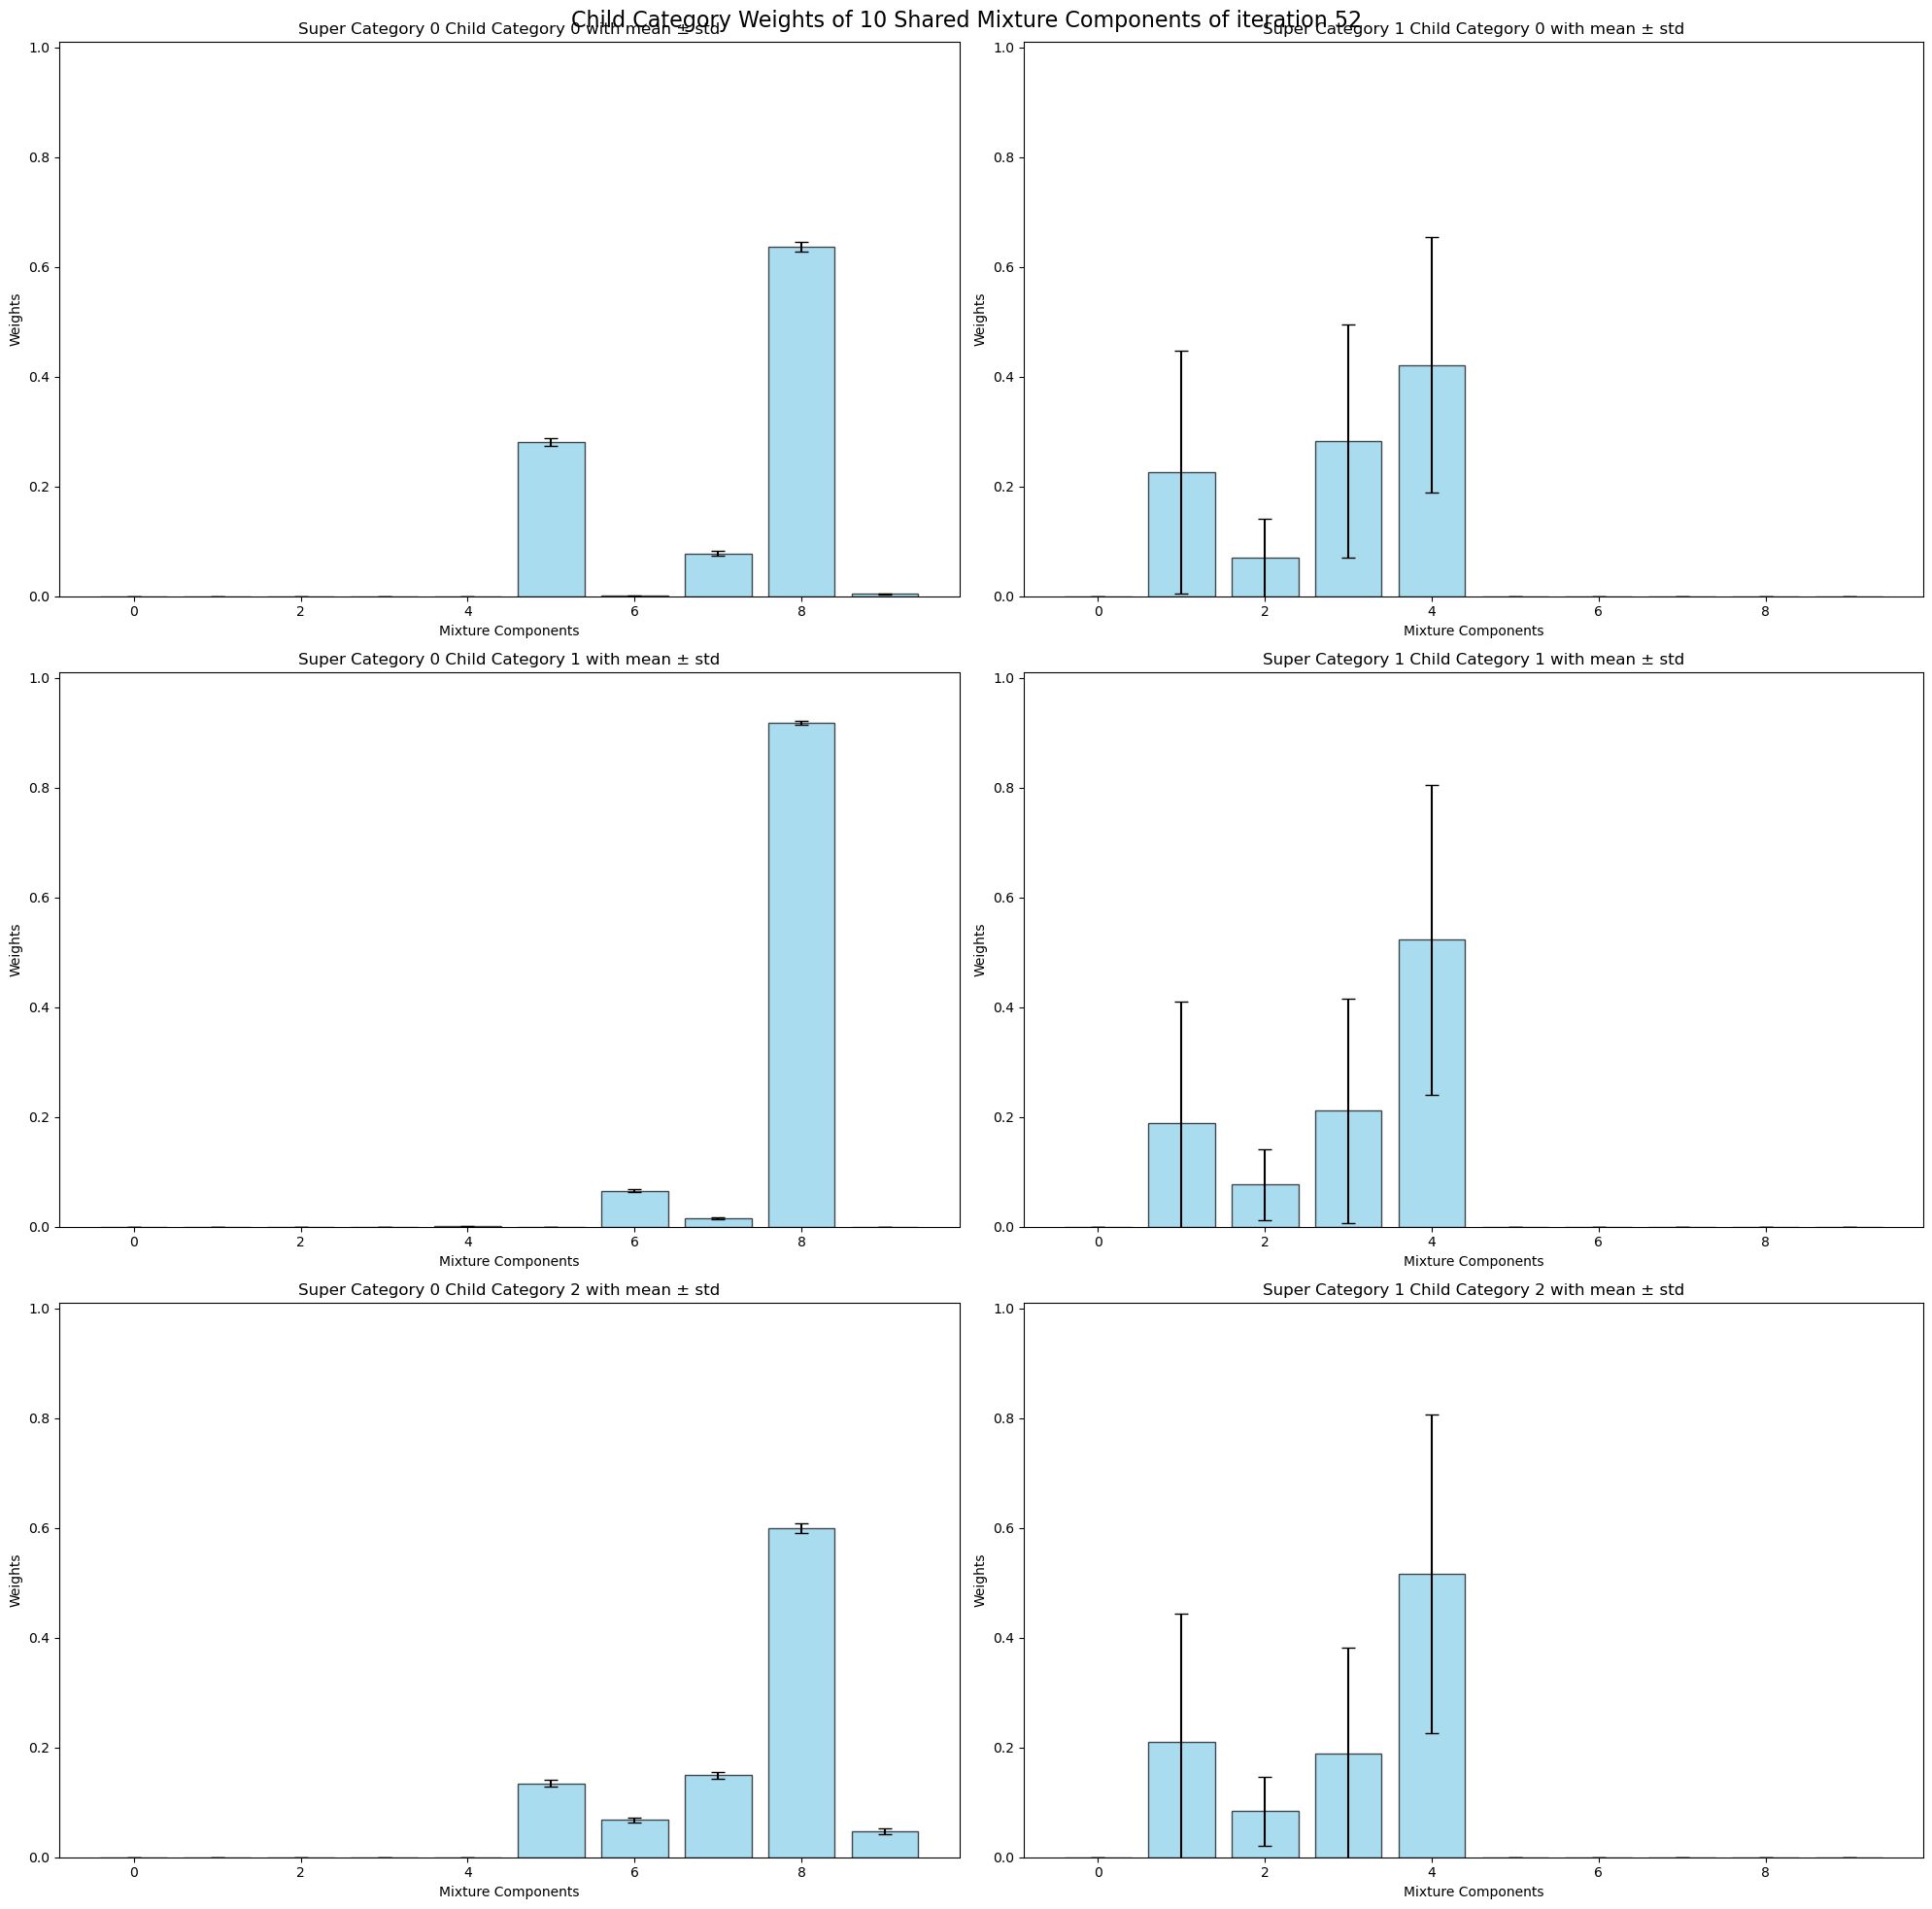

In [142]:
dataset = (data["x"], data["y"], data["base_labels"])
vocab_size = data["x"].shape[-1]
hdmm1 = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, gen_mixture=data["word_dists"], device="cpu")
model_return1 = gibbs_sampler(jax.random.PRNGKey(0), hdmm1, struct_upbd, vocab_size, num_iters=52, gt=data, gen_ground_truth=True)

In [143]:
# dataset_known = (data["x"], data["y"], data["base_labels"], data["super_labels"])
# vocab_size = data["x"].shape[-1]
# hdmm_known = model_known(dataset_known, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, gen_mixture=data["word_dists"], device="cpu")
# model_return_known = gibbs_sampler_known(jax.random.PRNGKey(0), hdmm_known, struct_upbd, vocab_size, num_iters=52, gt=data, gen_ground_truth=True)

In [144]:
# data_summary(model_return_known, data, struct_upbd)

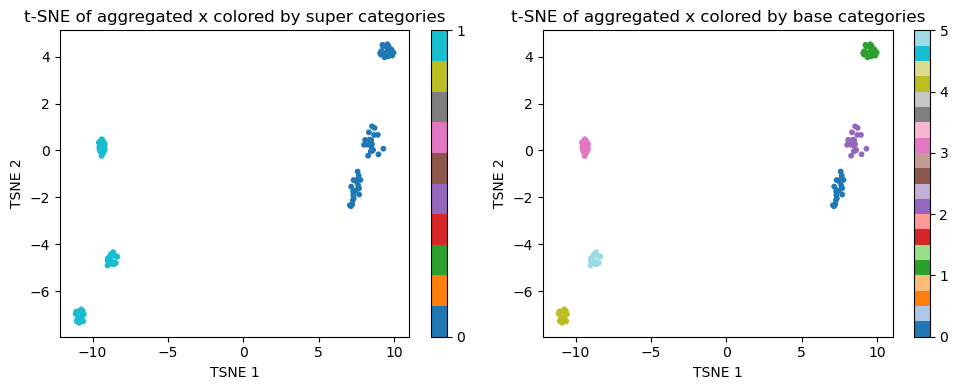

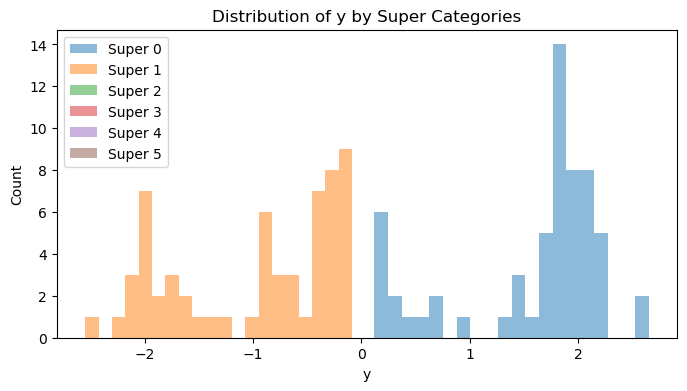

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


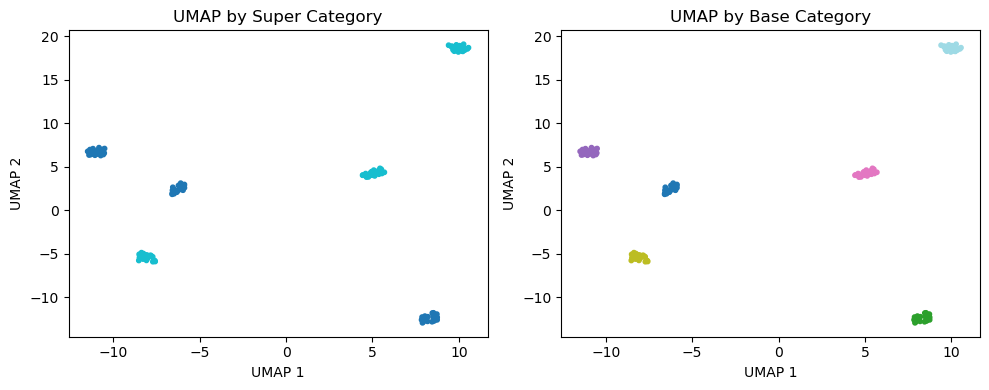

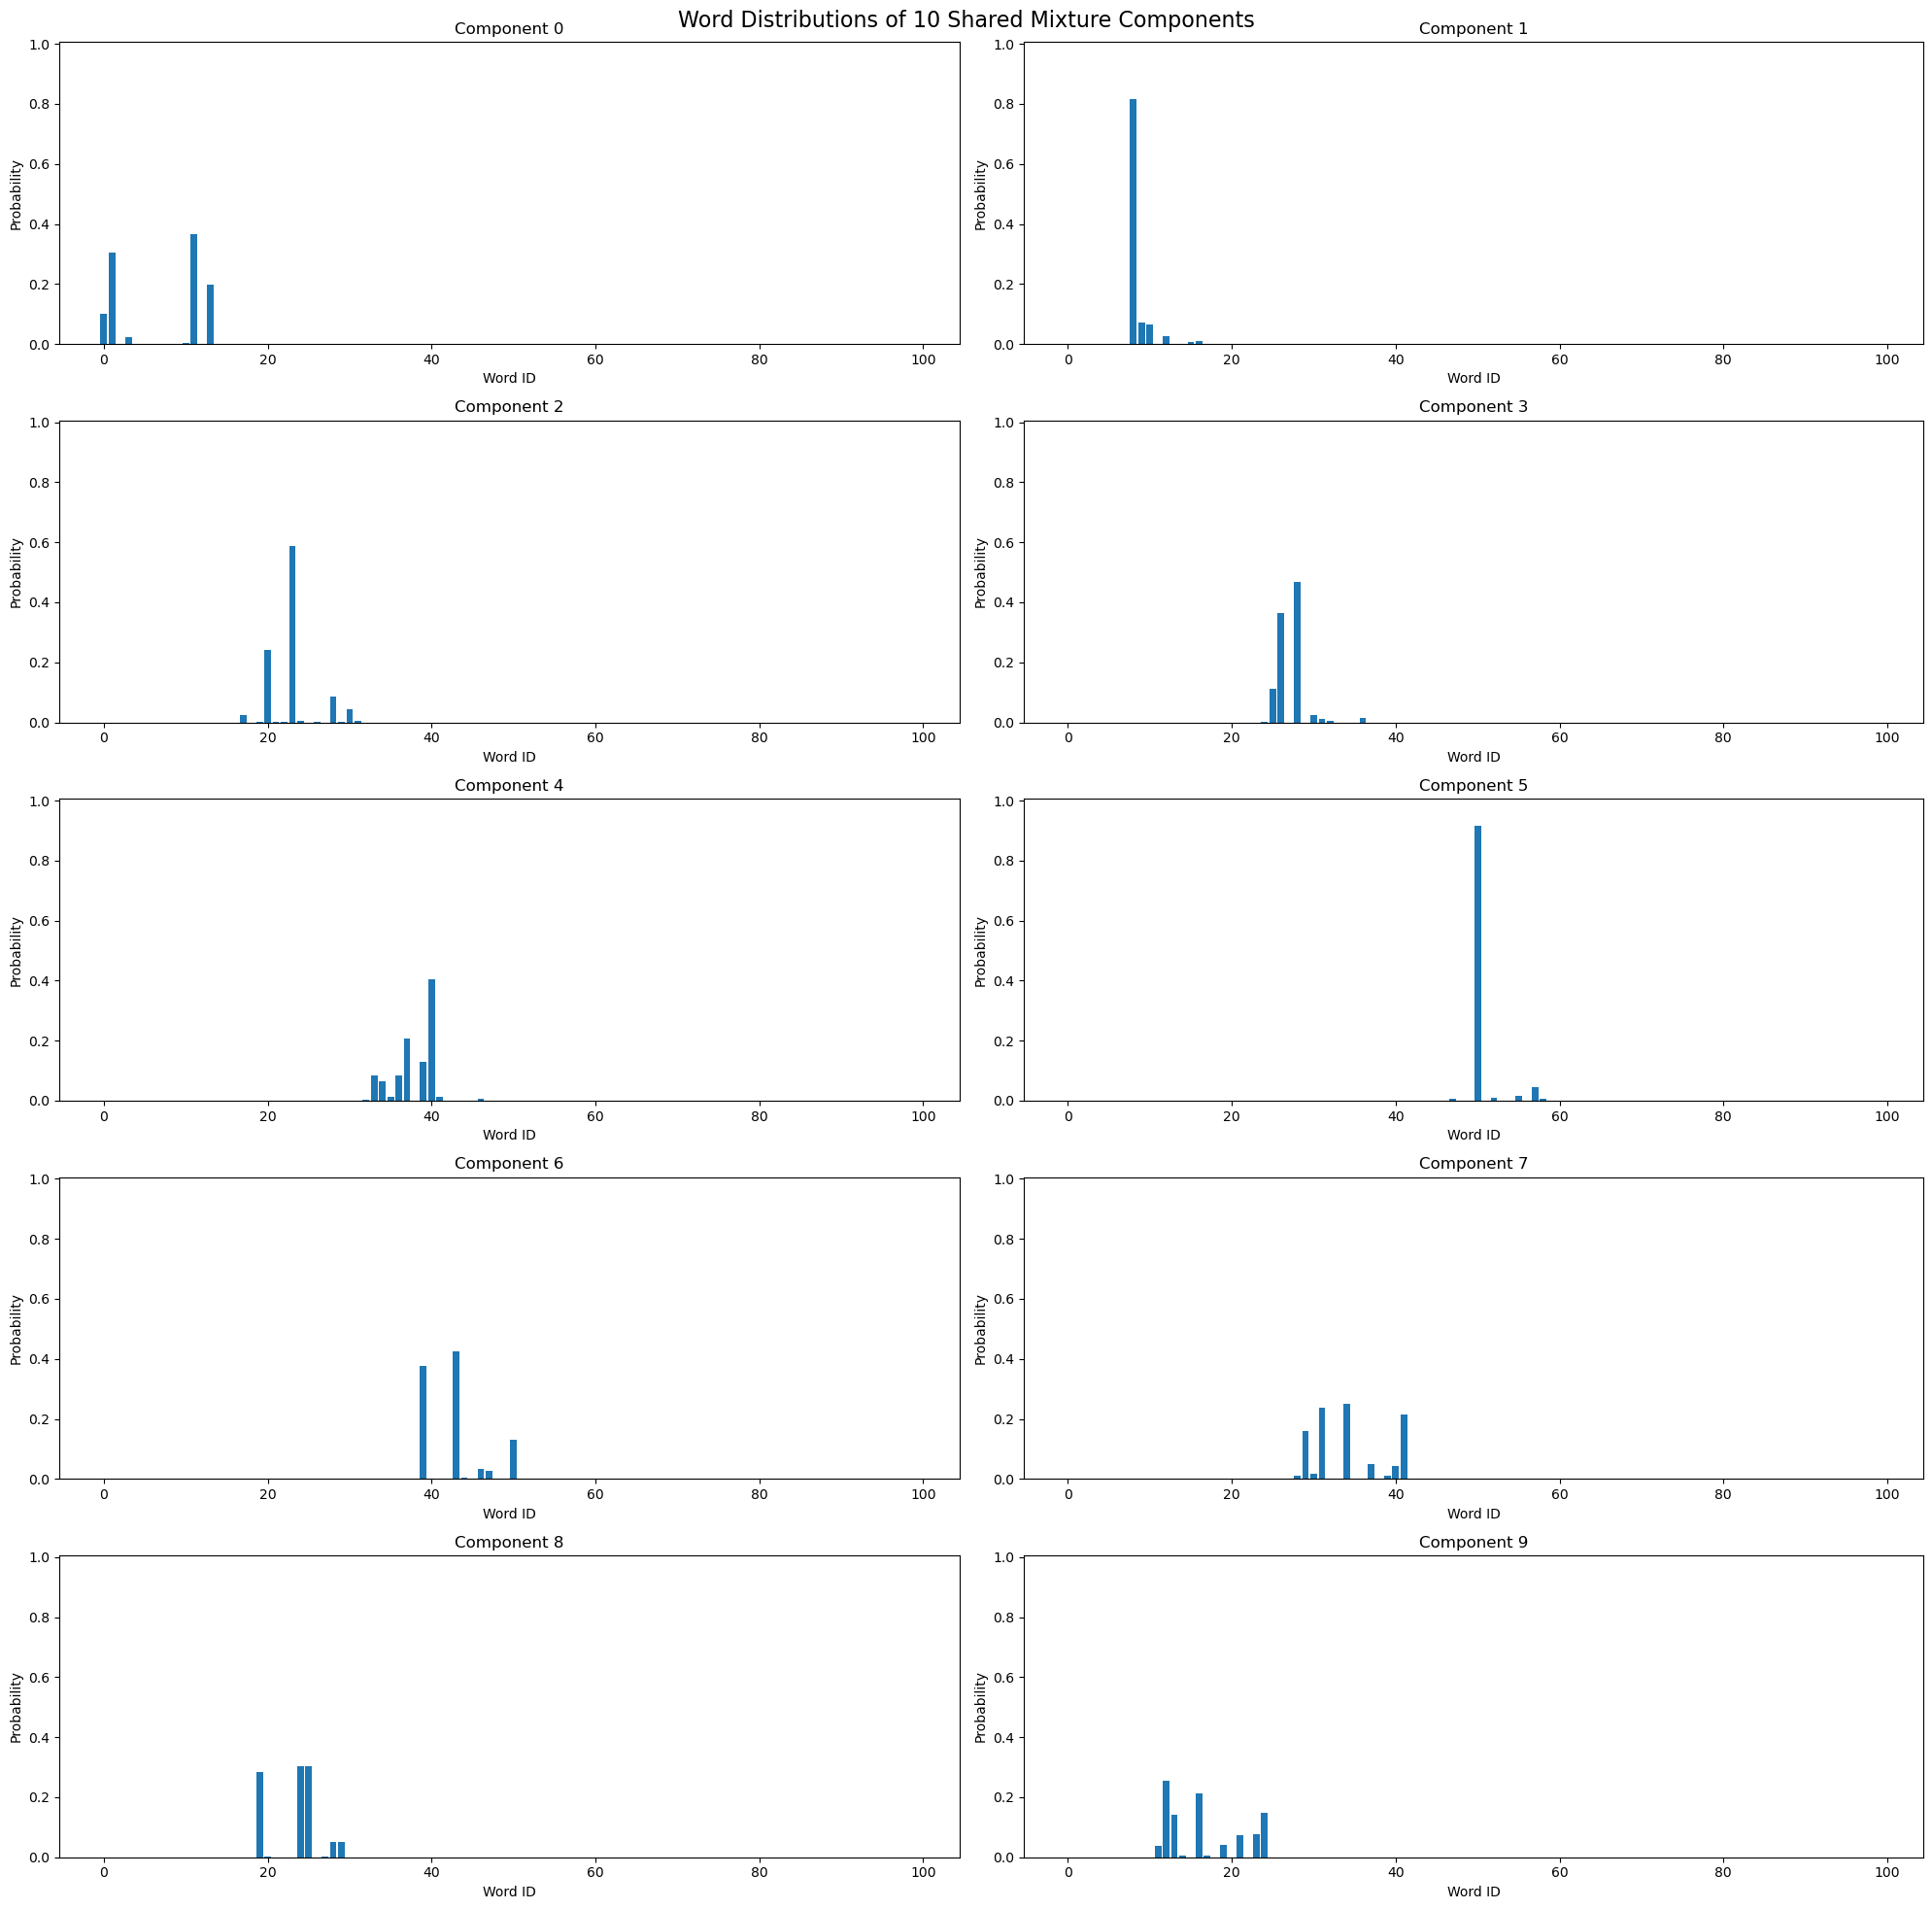

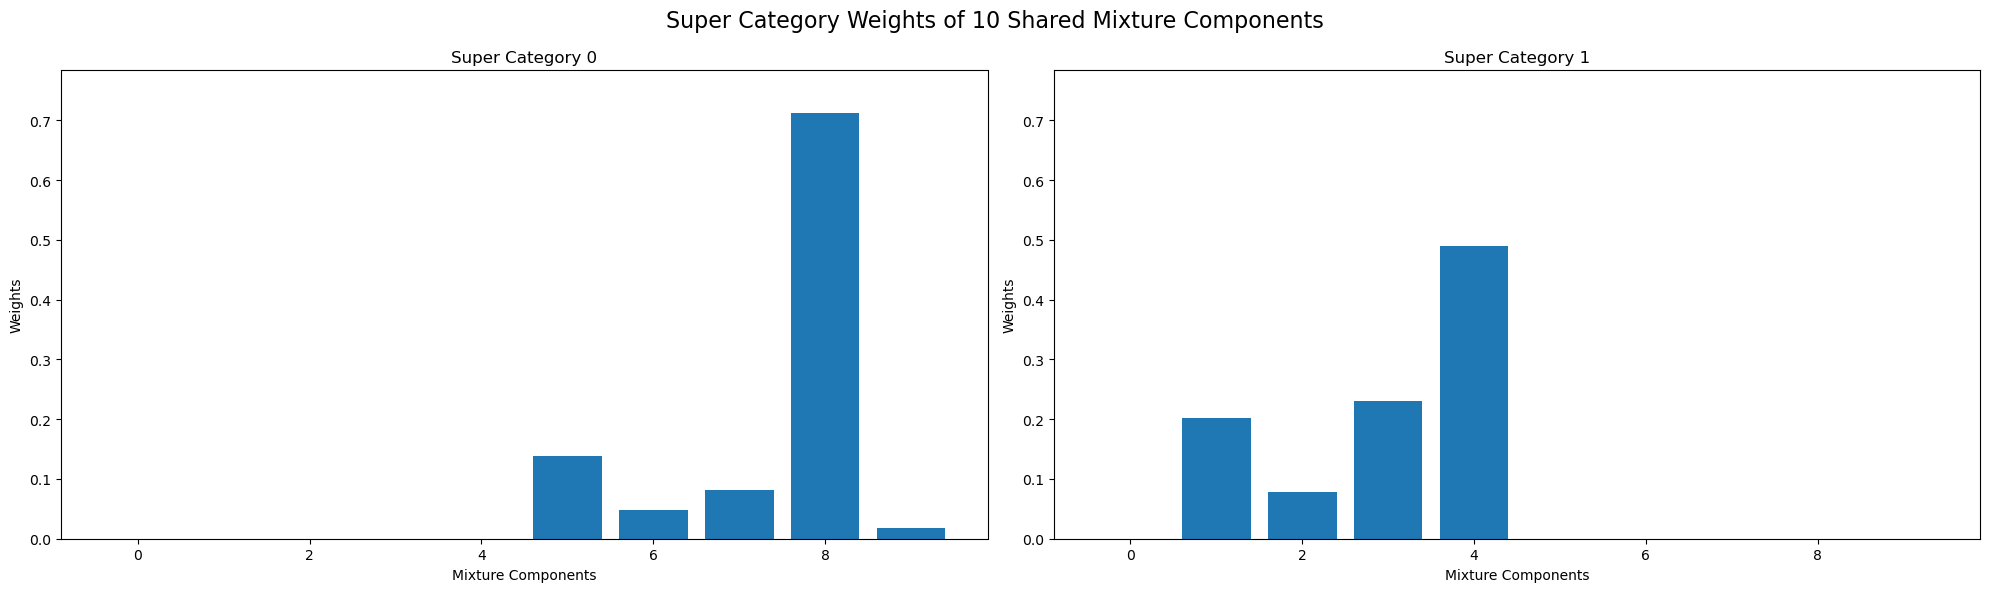

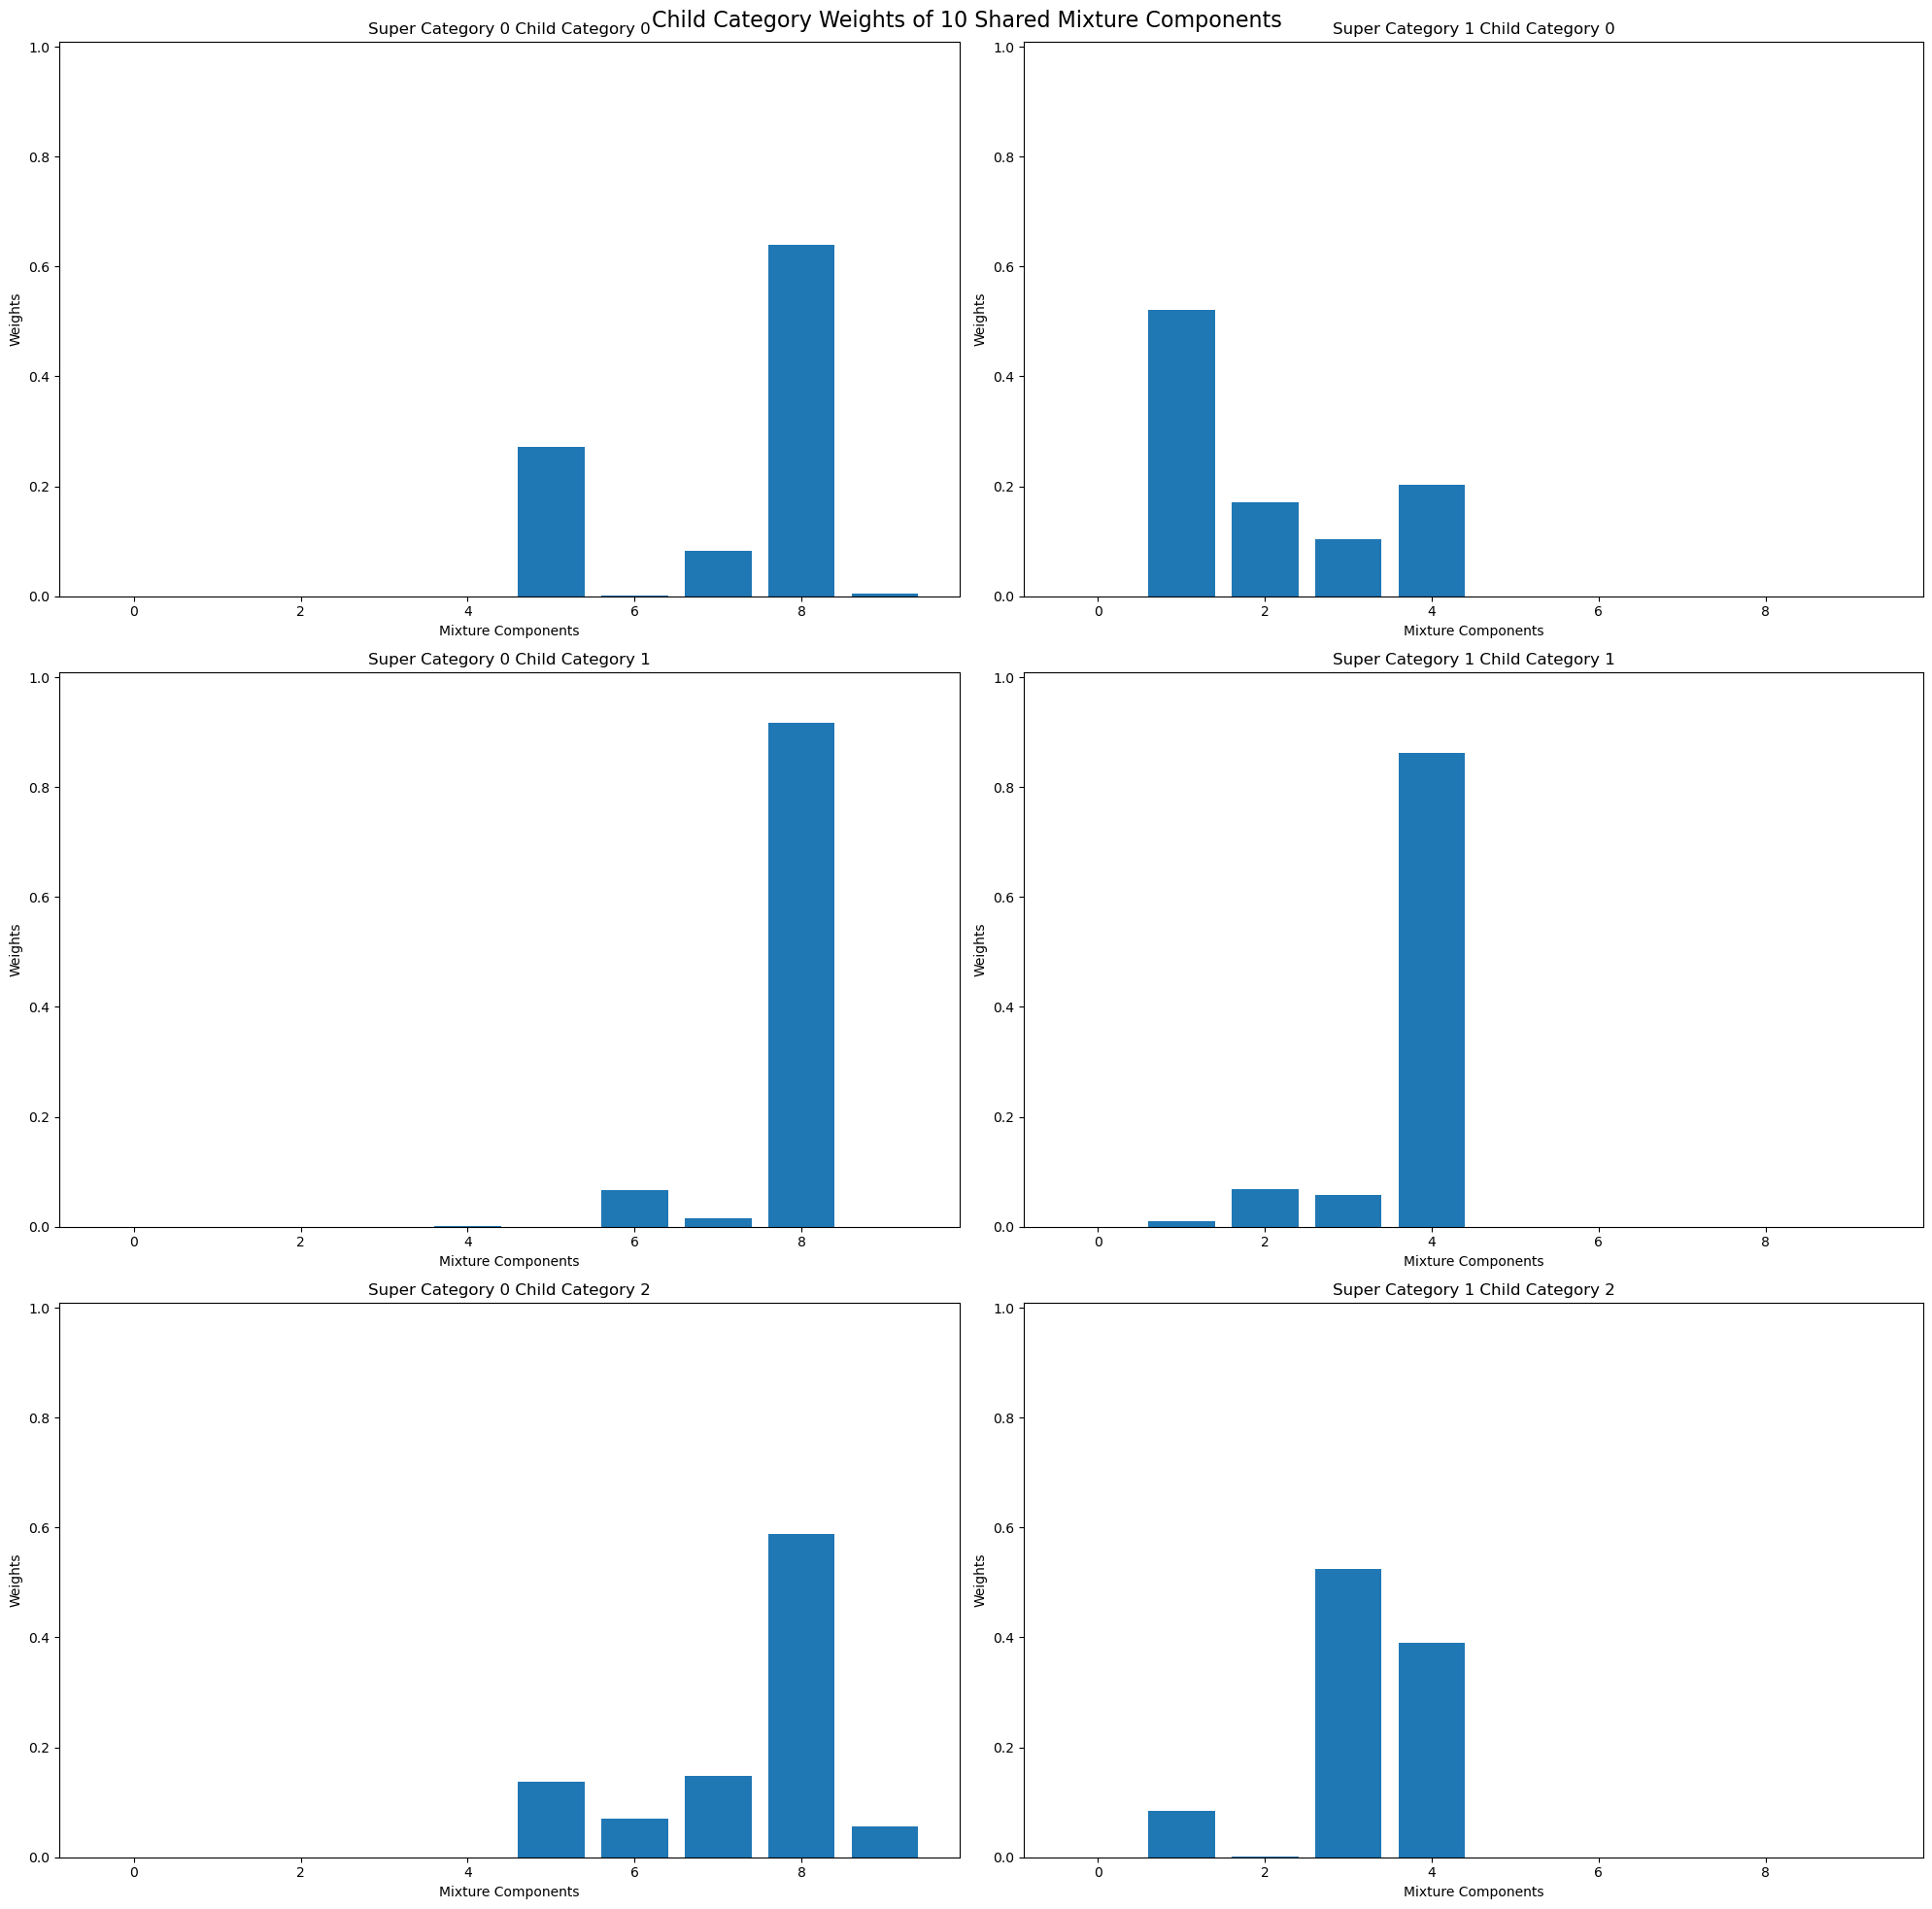

120 out of 120 super category labels are different from ground truth.
120 out of 120 base category labels are different from ground truth.


In [145]:
data_summary(model_return1, data, struct_upbd)